# Notebook 14 - calibration of the hydrological model

**Where this starts.** Notebook 13 ran the engine on the real 8,672-minibacia basin with a
parameter set fixed *before* any comparison with a gauge. It closes mass to
$2.1\times10^{-17}$ relative, forgets its initial state to within 0.17 % of mean flow, and is
**badly wrong**: runoff coefficient 0.724 against an observed 0.402, median KGE 0.227 over the 61
calibration-safe gauges, PBIAS +46 %. It also diagnosed *why*: $a_{dr}=0.06\,\mathrm{d^{-1}}$
(notebook 03 cell 7) drains the soil column so fast that $W$ settles near 49 % of $W_m$, and since
$ET = k_c\,PET\,W/W_m$ a soil kept dry cannot evaporate.

**What this notebook does.** It turns that diagnosis into a defensible calibration: a sensitivity
screening that *earns* the choice of which parameters to fit, a regionalisation with a stated
parameter budget, an objective with a stated reason, a period split designed so the ENSO years the
project exists to study are **never seen by the search**, a global search with a measured budget,
and a validation report that leads with the calibration-to-validation degradation rather than
burying it.

**The seven questions it has to answer, in order.**

1. **What can calibration possibly achieve?** Before fitting anything: is the observed water
   balance even *reachable* by this model on this forcing? (Section 1. The answer is partly no, and
   the size of the "no" is quantified.)
2. **Which parameters?** Ranked by measured sensitivity, not asserted. (Section 4.)
3. **How many free parameters may we afford?** Against the *effective* number of independent
   observations, not the raw gauge-day count. (Section 5.)
4. **What objective?** (Section 6.)
5. **What split?** (Section 2 - stated before the search, because a split chosen after seeing
   results is not a split.)
6. **What did the search find, and did it converge?** (Section 8.)
7. **Where does the model still fail, and whose fault is it** - forcing, gauge data, model
   structure, or calibration? (Sections 9-11.)

**Working rules applied throughout** (the user's, and load-bearing):

1. Every parameter, range, threshold and method states its reason **and** an alternative rejected.
2. Every headline number is recomputed a **second, independent way**; disagreements are reported.
3. New helper code passes a **synthetic test with an analytically known answer** before it touches
   basin data (sections 0.3, 6.5).
4. No number appears here that this notebook did not compute.
5. Where a result looks good it is attacked (section 10). The baseline already taught this lesson:
   one uncalibrated gauge scored KGE 0.77 and a plausibility band would have waved it through.

## 0.1 - Prerequisites

| Prerequisite | What it provides | Checked below |
|---|---|---|
| `src/mgb_hydrology.py` | the engine: `build_topology`, `MgbParams`, `MgbState`, `simulate` | sha256 recorded, import |
| `data/processed/model_inputs/*.npz` + `manifest.json` | topology, parameters, forcing, discharge | every array shape vs the manifest |
| `data/processed/sim_baseline/q_gauge.npz` | notebook 13's simulated + observed flows - the **before** in every before/after | shape + date axis identity |
| `data/processed/sim_baseline/balance.json` | notebook 13's fleet metrics, to reproduce and extend | fleet median KGE re-derived from `q_gauge.npz` |
| `data/processed/forcing_minibacia_precip.csv` | 2008 rainfall, deliberately absent from the bundle | needed for the warm-up of the full-period run |

Nothing is improvised if one is missing: the notebook stops.

In [1]:
import json, pathlib, sys, time, hashlib, warnings, itertools
import numpy as np, pandas as pd, rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': False, 'font.size': 9})

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b / 'src' / 'mgb_hydrology.py').exists() and (b / 'data' / 'processed').exists():
        REPO = b
        break
if REPO is None:
    raise SystemExit('cannot locate the repository root')
PROC = REPO / 'data' / 'processed'
MI = PROC / 'model_inputs'
SB = PROC / 'sim_baseline'
sys.path.insert(0, str(REPO / 'src'))

need = [MI / f for f in ('topology.npz', 'parameters.npz', 'forcing.npz', 'discharge.npz',
                         'manifest.json')]
need += [SB / 'q_gauge.npz', SB / 'balance.json', SB / 'parameters.json',
         PROC / 'forcing_minibacia_precip.csv', PROC / 'minibacias.tif',
         REPO / 'src' / 'mgb_hydrology.py']
missing = [str(p) for p in need if not p.exists()]
if missing:
    raise SystemExit(f'PREREQUISITES MISSING, stopping rather than improvising: {missing}')

import mgb_hydrology as mgb
ENG_SHA = hashlib.sha256((REPO / 'src' / 'mgb_hydrology.py').read_bytes()).hexdigest()
BASE_PJ = json.loads((SB / 'parameters.json').read_text())
print(f'repo             {REPO}')
print(f'engine           sha256 {ENG_SHA[:16]}   nb13 ran sha256 '
      f'{BASE_PJ["engine"]["sha256"][:16]}   identical: '
      f'{ENG_SHA == BASE_PJ["engine"]["sha256"]}')

TOP = dict(np.load(MI / 'topology.npz'))
PAR = dict(np.load(MI / 'parameters.npz', allow_pickle=True))
FRC = dict(np.load(MI / 'forcing.npz'))
DIS = dict(np.load(MI / 'discharge.npz', allow_pickle=True))
MAN = json.loads((MI / 'manifest.json').read_text())
BAL13 = json.loads((SB / 'balance.json').read_text())
QG13 = dict(np.load(SB / 'q_gauge.npz', allow_pickle=True))

bad = []
for fn, got in (('topology.npz', TOP), ('parameters.npz', PAR), ('forcing.npz', FRC),
                ('discharge.npz', DIS)):
    for k, spec in MAN['files'][fn]['arrays'].items():
        if k not in got:
            bad.append(f'{fn}:{k} absent')
        elif list(got[k].shape) != list(spec['shape']):
            bad.append(f'{fn}:{k} shape {got[k].shape} != manifest {spec["shape"]}')
if bad:
    raise SystemExit(f'bundle does not match its own manifest: {bad}')
print(f'manifest check   all {sum(len(MAN["files"][f]["arrays"]) for f in MAN["files"] if f.endswith("npz"))} '
      f'arrays match their declared shapes')

DATES = pd.DatetimeIndex(FRC['dates'])
NDAYS, NMB = FRC['precip_mm'].shape
assert np.array_equal(QG13['dates'], FRC['dates']), 'nb13 date axis differs from the bundle'
print(f'model period     {DATES[0].date()} .. {DATES[-1].date()}   {NDAYS} d, {NMB} minibacias')
print(f'nb13 baseline    q_gauge.npz {QG13["q_sim_m3s"].shape}, date axis identical to the bundle')

repo             C:\dev\magdalena-mgb-sed
engine           sha256 cdea026afe796f6d   nb13 ran sha256 cdea026afe796f6d   identical: True


manifest check   all 46 arrays match their declared shapes
model period     2009-01-01 .. 2017-12-31   3287 d, 8672 minibacias
nb13 baseline    q_gauge.npz (3287, 111), date axis identical to the bundle


## 0.2 - What notebook 13 established, and what is therefore *not* re-litigated here

| Established by nb13 | Consequence for this notebook |
|---|---|
| Mass closes to $2.1\times10^{-17}$ relative; the negative-$W$ guard never fired | The engine is not re-verified cell by cell. Section 9.2 re-checks mass **for the calibrated parameter set**, because a new parameter set is a new test of the guards, not of the algebra. |
| A 366-day warm-up plus a near-equilibrium start forgets three incompatible initial states to within 0.17 % of mean flow | Warm-up is not re-argued from scratch, but the *shorter* warm-up this notebook needs for speed **is** measured (section 7), and against parameter sets far more extreme than nb13's. |
| Uncalibrated fleet: median KGE 0.227, $\alpha$ 1.241, $\beta$ 1.461, PBIAS +46.1 %; $\beta>1$ at 53/61 gauges | Bias is one-signed, so the first thing calibration must move is the water partition. Section 4 tests that rather than assuming it. |
| A mean-normalised permutation null puts median $r$ at 0.380 against the matched 0.563 | **Do not expect calibration to move $r$ much**, and do not celebrate an $r$ that a mismatched pairing could produce. Section 10.4 re-runs that null on the calibrated flows. |
| The routing is Muskingum $X=0$; Mompos / La Mojana floodplain storage is not represented | Any parameter that ends up absorbing floodplain storage must be *named as such*. Section 4.3 finds exactly this happening to the channel celerity. |

The one number this notebook must reproduce before it is allowed to proceed: nb13's fleet median
KGE, recomputed here from `q_gauge.npz` with this notebook's own metric code. If the two disagree
the metric code is wrong, and everything after it would be wrong in the same way.

In [2]:
ids = TOP['minibacia_id'].astype(np.int64)
A_MB = TOP['own_area_km2'].astype(np.float64)
A_TOT = float(A_MB.sum())
UPAREA = TOP['upstream_area_km2'].astype(np.float64)
REACH_KM = TOP['reach_km'].astype(np.float64)
TOPO = mgb.build_topology(ids, A_MB, TOP['downstream_id'].astype(np.int64),
                          PAR['urh_fraction'].astype(np.float64),
                          urh_codes=PAR['urh_id'].astype(np.int64))
P_ALL = FRC['precip_mm'].astype(np.float64)
E_ALL = FRC['pet_mm'].astype(np.float64)
WM0 = PAR['Wm_mm'].astype(np.float64)
U24 = PAR['urh_id'].astype(int)

# nb13's PRIORS, reproduced from its own parameters.json so they cannot drift
KC_LAND = {int(k): v for k, v in zip(range(1, 9), [1.0, 0.9, 0.9, 1.0, 0.35, 0.25, 1.05, 1.05])}
LAI_LAND = {int(k): v for k, v in zip(range(1, 9), [5.0, 2.0, 1.5, 2.5, 0.5, 0.0, 0.0, 2.0])}
_pj = BASE_PJ['parameters']
LAND_NAME = {1: 'Forest', 2: 'Shrub', 3: 'Grassland', 4: 'Cropland', 5: 'Urban', 6: 'Bare',
             7: 'Water', 8: 'Wetland'}
for L, nm in LAND_NAME.items():
    assert abs(_pj['kc']['value'][nm] - KC_LAND[L]) < 1e-12, f'kc prior drifted at {nm}'
    assert abs(_pj['lai']['value'][nm] - LAI_LAND[L]) < 1e-12, f'LAI prior drifted at {nm}'
KC0 = np.array([KC_LAND[c % 10] for c in U24])
LAI0 = np.array([LAI_LAND[c % 10] for c in U24])
ALPHA_INT = float(_pj['lai']['alpha_int_mm'])
SOIL_OF_URH = np.array([c // 10 for c in U24])          # 1 coarse, 2 medium, 3 fine
print(f'priors reproduced from nb13 parameters.json: kc, LAI, alpha_int = {ALPHA_INT} mm')
print(f'nb13 priors: adr {_pj["percolation"]["adr_per_day"]}, fint {_pj["percolation"]["fint"]}, '
      f'b {_pj["b"]["value"]}, k_sup/int/bas {_pj["reservoir"]["k_sup_d"]}/'
      f'{_pj["reservoir"]["k_int_d"]}/{_pj["reservoir"]["k_bas_d"]} d, '
      f'celerity {_pj["tau_channel"]["celerity_m_s"]} m/s')

GCODE = DIS['gauge_code'].astype(str)
GMIDX = DIS['gauge_minibacia_idx'].astype(np.int64)
JP = np.flatnonzero(DIS['is_calibration_safe'])
NG = int(JP.size)
REC_IDS = ids[GMIDX[JP]].tolist()
GC = GCODE[JP]
GUP = UPAREA[GMIDX[JP]]
QOBS = np.where(DIS['q_valid'][:, JP], DIS['q_m3s'][:, JP].astype(np.float64), np.nan)
print(f'\ncalibration-safe gauges: {NG}  upstream area {GUP.min():,.0f} .. {GUP.max():,.0f} km2')
print(f'observed valid gauge-days over 2009-2017: {int(np.isfinite(QOBS).sum()):,}')

priors reproduced from nb13 parameters.json: kc, LAI, alpha_int = 0.2 mm
nb13 priors: adr 0.06, fint 0.6, b 0.6, k_sup/int/bas 1.5/8.0/60.0 d, celerity 1.0 m/s

calibration-safe gauges: 61  upstream area 68 .. 257,097 km2
observed valid gauge-days over 2009-2017: 163,892


## 0.3 - The new code, and its synthetic tests

Four helpers are new in this notebook. Each is tested on a case whose answer is known in closed
form *before* it is allowed near basin data.

| Helper | What it does | Test with a known answer |
|---|---|---|
| `kge_terms` | KGE and its $(r,\alpha,\beta)$ decomposition, NSE, PBIAS | perfect / shifted / scaled / anti-correlated series, all analytic |
| `c2m` | the bounded transform $\mathcal{B}(k)=k/(2-k)$ used to aggregate KGE over gauges | fixed points, monotonicity, and the limit $\mathcal{B}(-\infty)=-1$ |
| `dds` | Dynamically Dimensioned Search (Tolson & Shoemaker 2007) | recovers the optimum of a sphere and of Rosenbrock in 10-D |
| `eq_state` | the parameter-dependent mean-field equilibrium initial state | reproduces nb13's registered runoff-coefficient prediction (0.7301) at nb13's parameters; residual of the fixed point |

**Why `c2m` and not a plain mean of KGE.** KGE is bounded above by 1 but unbounded below, so the
arithmetic mean over 61 gauges can be dominated by one catastrophic gauge - and this fleet *has*
such gauges (section 1 shows 21 of 61 have a water balance the model cannot reach). Two escapes were
considered and rejected: **(a) the median**, which is robust but hands the whole gradient to
whichever single gauge happens to be in the middle, so a search would optimise one gauge at a time;
**(b) clipping KGE at some floor**, which throws away all information below the floor and creates a
flat region the search cannot climb. The bounded transform
$\mathcal{B}(k)=k/(2-k)$ (Mathevet et al. 2006's $C_{2}M$) is strictly increasing on
$(-\infty,1]$, maps $0\mapsto0$, $1\mapsto1$ and $-\infty\mapsto-1$, so a hopeless gauge
contributes a bounded penalty while still contributing a *gradient*. Nothing is discarded.

In [3]:
def kge_terms(sim, obs):
    '''KGE = 1 - sqrt((r-1)^2 + (alpha-1)^2 + (beta-1)^2)  (Gupta et al. 2009), + NSE, PBIAS.

    r     = Pearson correlation        -> timing / shape
    alpha = sd(sim)/sd(obs)            -> variability
    beta  = mean(sim)/mean(obs)        -> bias
    NaN pairs are dropped; nothing is filled, because an interpolated observation is a
    fabricated observation. Undefined terms return NaN, never a silent 0.
    '''
    sim = np.asarray(sim, dtype=float)
    obs = np.asarray(obs, dtype=float)
    m = np.isfinite(sim) & np.isfinite(obs)
    s, o = sim[m], obs[m]
    out = dict(n=int(s.size), r=np.nan, alpha=np.nan, beta=np.nan, kge=np.nan,
               nse=np.nan, pbias=np.nan)
    if s.size < 30:
        return out
    ss, so, mo = s.std(ddof=1), o.std(ddof=1), o.mean()
    if so > 0:
        # alpha is well defined even for a constant simulation (it is then 0);
        # r is NOT, so the two conditions are deliberately different.  The r guard is
        # RELATIVE (ss > 1e-12 so) rather than ss > 0: a simulated series that is flat
        # to round-off still has ss ~ 1e-15 > 0, and np.corrcoef would then return a
        # meaningless correlation of pure floating-point noise instead of NaN.  A
        # calibration candidate CAN produce such a series (e.g. adr -> 0 with a huge Wm),
        # so this is a real guard, not a cosmetic one.
        out['alpha'] = float(ss / so)
        if ss > 1e-12 * so:
            out['r'] = float(np.corrcoef(s, o)[0, 1])
    if mo > 0:
        out['beta'] = float(s.mean() / mo)
        out['pbias'] = float(100.0 * (s.sum() - o.sum()) / o.sum())
    if np.all(np.isfinite([out['r'], out['alpha'], out['beta']])):
        out['kge'] = float(1 - np.sqrt((out['r'] - 1) ** 2 + (out['alpha'] - 1) ** 2
                                       + (out['beta'] - 1) ** 2))
    den = float(((o - mo) ** 2).sum())
    if den > 0:
        out['nse'] = float(1 - ((s - o) ** 2).sum() / den)
    return out


def c2m(k):
    '''Bounded (Mathevet 2006 C2M) transform of an efficiency: strictly increasing,
    B(1)=1, B(0)=0, B(-inf)=-1.  Applied to KGE so one hopeless gauge cannot dominate
    a fleet mean while still contributing a usable gradient.'''
    k = np.asarray(k, dtype=float)
    return k / (2.0 - k)


T = []
rng0 = np.random.default_rng(20260802)
o = rng0.gamma(2.0, 30.0, 4000) + 0.5
T.append(('T1 perfect sim -> r=alpha=beta=KGE=NSE=1, PBIAS=0',
          all(abs(kge_terms(o, o)[k] - v) < 1e-12
              for k, v in (('r', 1), ('alpha', 1), ('beta', 1), ('kge', 1), ('nse', 1),
                           ('pbias', 0)))))
k2 = kge_terms(1.25 * o, o)
T.append(('T2 sim = 1.25*obs -> r=1, alpha=beta=1.25, KGE=1-sqrt(2)*0.25',
          abs(k2['r'] - 1) < 1e-12 and abs(k2['alpha'] - 1.25) < 1e-12
          and abs(k2['beta'] - 1.25) < 1e-12
          and abs(k2['kge'] - (1 - np.sqrt(2) * 0.25)) < 1e-12
          and abs(k2['pbias'] - 25.0) < 1e-9))
k3 = kge_terms(o + 10.0, o)
T.append(('T3 sim = obs+10 -> r=alpha=1, beta=1+10/mean(obs), KGE=1-10/mean(obs)',
          abs(k3['r'] - 1) < 1e-12 and abs(k3['alpha'] - 1) < 1e-12
          and abs(k3['beta'] - (1 + 10 / o.mean())) < 1e-12
          and abs(k3['kge'] - (1 - 10 / o.mean())) < 1e-12))
k4 = kge_terms(o.mean() * np.ones_like(o), o)
T.append(('T4 sim = constant mean(obs) -> alpha=0, NSE=0, r undefined -> KGE NaN',
          abs(k4['alpha']) < 1e-12 and abs(k4['nse']) < 1e-12 and np.isnan(k4['kge'])))
k5 = kge_terms(-o + 2 * o.mean(), o)
T.append(('T5 mirrored sim -> r=-1 exactly', abs(k5['r'] + 1) < 1e-12))
T.append(('T6 fewer than 30 valid pairs -> all NaN, n reported',
          kge_terms(o[:10], o[:10])['n'] == 10 and np.isnan(kge_terms(o[:10], o[:10])['kge'])))
T.append(('T7 c2m fixed points and limit: B(1)=1, B(0)=0, B(-1)=-1/3, B(-1e12)->-1',
          abs(c2m(1.0) - 1) < 1e-15 and abs(c2m(0.0)) < 1e-15
          and abs(c2m(-1.0) + 1 / 3) < 1e-15 and abs(c2m(-1e12) + 1) < 1e-11))
xs = np.linspace(-50, 1.0, 20001)
T.append(('T8 c2m strictly increasing on (-inf, 1]', bool(np.all(np.diff(c2m(xs)) > 0))))
for nm, ok in T:
    print(f'  {"PASS" if ok else "FAIL"}  {nm}')
assert all(ok for _, ok in T), 'metric smoke tests failed'
N_SMOKE = len(T)

  PASS  T1 perfect sim -> r=alpha=beta=KGE=NSE=1, PBIAS=0
  PASS  T2 sim = 1.25*obs -> r=1, alpha=beta=1.25, KGE=1-sqrt(2)*0.25
  PASS  T3 sim = obs+10 -> r=alpha=1, beta=1+10/mean(obs), KGE=1-10/mean(obs)
  PASS  T4 sim = constant mean(obs) -> alpha=0, NSE=0, r undefined -> KGE NaN
  PASS  T5 mirrored sim -> r=-1 exactly
  PASS  T6 fewer than 30 valid pairs -> all NaN, n reported
  PASS  T7 c2m fixed points and limit: B(1)=1, B(0)=0, B(-1)=-1/3, B(-1e12)->-1
  PASS  T8 c2m strictly increasing on (-inf, 1]


In [4]:
def dds(fun, x0, lo, hi, budget, seed, r_pert=0.2, log=None):
    '''Dynamically Dimensioned Search (Tolson & Shoemaker 2007, WRR 43, W01413), MAXIMISING.

    One algorithm parameter (r_pert = 0.2, the paper's recommended value and the one it shows
    to be insensitive over 0.1-0.3). The perturbation probability
        p(i) = 1 - ln(i)/ln(budget)
    decays from ~1 to 0, so the search starts global (most dimensions perturbed at once) and
    ends local (one dimension at a time) WITHOUT a schedule the user has to tune - which is
    exactly why it suits a budget fixed by wall time rather than by convergence.
    Out-of-range proposals are REFLECTED at the bound (not clipped): clipping piles probability
    mass on the bound itself and would make a boundary optimum look like a real one.
    Greedy: a proposal is accepted only if it improves.  Returns the archive of EVERY
    evaluation, which sections 10.2-10.3 mine for free.
    '''
    rng = np.random.default_rng(seed)
    x0 = np.asarray(x0, float).copy()
    lo = np.asarray(lo, float)
    hi = np.asarray(hi, float)
    d = x0.size
    xb = x0.copy()
    fb, extra = fun(xb)
    arch = [(xb.copy(), fb, extra)]
    hist = [fb]
    for i in range(1, budget):
        p = 1.0 - np.log(i) / np.log(budget)
        J = np.flatnonzero(rng.random(d) < p)
        if J.size == 0:
            J = np.array([rng.integers(d)])
        xn = xb.copy()
        for j in J:
            xn[j] = xb[j] + r_pert * (hi[j] - lo[j]) * rng.standard_normal()
            if xn[j] < lo[j]:
                xn[j] = lo[j] + (lo[j] - xn[j])
                if xn[j] > hi[j]:
                    xn[j] = lo[j]
            elif xn[j] > hi[j]:
                xn[j] = hi[j] - (xn[j] - hi[j])
                if xn[j] < lo[j]:
                    xn[j] = hi[j]
        fn, extra = fun(xn)
        arch.append((xn.copy(), fn, extra))
        if fn > fb:
            xb, fb = xn, fn
        hist.append(fb)
        if log and (i % log == 0 or i == budget - 1):
            print(f'    eval {i+1:4d}/{budget}  best {fb:.5f}  p_pert {p:.3f}  '
                  f'|J| {J.size}', flush=True)
    return dict(x=xb, f=fb, hist=np.array(hist), archive=arch)


# --- synthetic tests: analytic optima, no hydrology involved ------------------
S = []
sph = lambda x: (-float(np.sum((x - 0.3) ** 2)), None)          # noqa: E731
r1 = dds(sph, np.zeros(10), -np.ones(10), np.ones(10), 600, 11)
S.append((f'S1 10-D sphere, optimum x=0.3, f=0: got f={r1["f"]:.2e}, '
          f'max|x-0.3|={np.abs(r1["x"]-0.3).max():.4f}', r1['f'] > -1e-2))


def rosen(x):
    return (-float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1 - x[:-1]) ** 2)), None)


r2 = dds(rosen, np.full(10, -1.0), np.full(10, -2.0), np.full(10, 2.0), 3000, 12)
S.append((f'S2 10-D Rosenbrock, optimum x=1, f=0: got f={r2["f"]:.3f}, '
          f'mean x={r2["x"].mean():.3f}', r2['f'] > -5.0))
r3 = dds(sph, np.zeros(10), -np.ones(10), np.ones(10), 600, 11)
S.append(('S3 same seed reproduces bit-for-bit', bool(np.array_equal(r1['x'], r3['x']))))
r4 = dds(sph, np.zeros(10), -np.ones(10), np.ones(10), 600, 99)
S.append((f'S4 a different seed finds a different path but a comparable optimum '
          f'(f={r4["f"]:.2e})', r4['f'] > -1e-2 and not np.array_equal(r1['x'], r4['x'])))
edge = lambda x: (-float(np.sum((x - 1.0) ** 2)), None)         # noqa: E731
r5 = dds(edge, np.zeros(4), -np.ones(4), np.ones(4), 800, 13)
S.append((f'S5 optimum ON the upper bound is approached despite reflection '
          f'(min over dims x={r5["x"].min():.4f})', r5['x'].min() > 0.90))
r6 = dds(sph, np.zeros(10), -np.ones(10), np.ones(10), 600, 11)
S.append((f'S6 archive holds every evaluation ({len(r6["archive"])} for budget 600)',
          len(r6['archive']) == 600))
S.append((f'S7 best-so-far is monotone non-decreasing',
          bool(np.all(np.diff(r1['hist']) >= 0))))
for nm, ok in S:
    print(f'  {"PASS" if ok else "FAIL"}  {nm}')
assert all(ok for _, ok in S), 'DDS smoke tests failed'
N_SMOKE += len(S)
print(f'\n{N_SMOKE} synthetic assertions passed before any basin data was touched')

  PASS  S1 10-D sphere, optimum x=0.3, f=0: got f=-3.11e-03, max|x-0.3|=0.0425
  PASS  S2 10-D Rosenbrock, optimum x=1, f=0: got f=-0.632, mean x=1.031
  PASS  S3 same seed reproduces bit-for-bit
  PASS  S4 a different seed finds a different path but a comparable optimum (f=-2.22e-03)
  PASS  S5 optimum ON the upper bound is approached despite reflection (min over dims x=0.9912)
  PASS  S6 archive holds every evaluation (600 for budget 600)
  PASS  S7 best-so-far is monotone non-decreasing

15 synthetic assertions passed before any basin data was touched


## 1 - Before fitting anything: what can calibration possibly achieve?

A calibration that is asked for something impossible will deliver a compensating parameter set and
call it success. So the first question is a physics question, and it is answered from **observations
and forcing only** - no model run, no parameter.

The engine's evaporation is
$$ET_{total} = \underbrace{E_{can}}_{\le PET} + \underbrace{k_c\,PET_{soil}\,\frac{W}{W_m}}_{\le k_c\,PET_{soil}},
\qquad PET_{soil}=PET-E_{can}$$
so, whatever the parameters,
$$ET_{total} \;\le\; \max(1,\,k_c)\cdot PET .$$
Long-term storage change is negligible over nine years, so the observed balance
$Q_{obs} = P - ET$ demands $ET_{req} = P - Q_{obs}$. Therefore a gauge is **reachable** only if

$$\underbrace{RC_{obs}=\frac{Q_{obs}}{P}}_{\text{observed}} \;\ge\; \underbrace{1-\frac{\max(1,k_c)\,PET}{P}}_{\text{energy floor}}
\qquad\text{and}\qquad RC_{obs}\le 1 \;\;(\text{mass}).$$

Both bounds are physics, not thresholds - there is no tunable number in them. $P$ and $PET$ are
averaged over the gauge's own upstream area and **over the same days the gauge reported**, because a
gauge that only recorded dry years would otherwise be handed a wet-year rainfall.

In [5]:
down = TOPO.down
CHILD = [[] for _ in range(TOPO.n_mini)]
for _i, _j in enumerate(down):
    if _j >= 0:
        CHILD[_j].append(_i)


def upstream_of(root):
    stack, seen = [int(root)], set()
    while stack:
        i = stack.pop()
        if i in seen:
            continue
        seen.add(i)
        stack.extend(CHILD[i])
    return np.fromiter(seen, dtype=np.int64)


UPSET = {int(j): upstream_of(GMIDX[j]) for j in JP}
KC_MINI = PAR['urh_fraction'].astype(np.float64) @ KC0        # area-weighted kc per minibacia

rows = []
for jj, j in enumerate(JP):
    up = UPSET[int(j)]
    w = A_MB[up]
    ar = float(w.sum())
    m = np.isfinite(QOBS[:, jj])
    nd = int(m.sum())
    q_mm = QOBS[m, jj].mean() * 86400.0 / (ar * 1e6) * 1000.0
    p_mm = float((P_ALL[m][:, up] * w).sum() / (nd * ar))
    e_mm = float((E_ALL[m][:, up] * w).sum() / (nd * ar))
    kc = float(np.average(KC_MINI[up], weights=w))
    cap = max(1.0, kc)
    rows.append(dict(code=GCODE[j], area_km2=ar, n_valid=nd, P=p_mm, PET=e_mm, Q=q_mm, kc=kc,
                     rc=q_mm / p_mm, rc_floor=1.0 - cap * e_mm / p_mm,
                     et_req=p_mm - q_mm, et_req_over_cap_pet=(p_mm - q_mm) / (cap * e_mm)))
FEAS = pd.DataFrame(rows)
FEAS['energy_ok'] = FEAS.rc >= FEAS.rc_floor
FEAS['mass_ok'] = FEAS.rc <= 1.0
FEAS['feasible'] = FEAS.energy_ok & FEAS.mass_ok
FEAS['q_floor'] = FEAS.P - np.maximum(1.0, FEAS.kc) * FEAS.PET
FEAS['pbias_floor_pct'] = 100.0 * (np.maximum(FEAS.q_floor, 0.0) / FEAS.Q - 1.0)

n_e = int((~FEAS.energy_ok).sum()); n_m = int((~FEAS.mass_ok).sum())
print(f'{NG} calibration-safe gauges')
print(f'  observed RC (matched days):  min {FEAS.rc.min():.3f}  median {FEAS.rc.median():.3f}'
      f'  max {FEAS.rc.max():.3f}')
print(f'  energy floor 1 - max(1,kc)*PET/P: min {FEAS.rc_floor.min():.3f}  '
      f'median {FEAS.rc_floor.median():.3f}  max {FEAS.rc_floor.max():.3f}')
print(f'  VIOLATE the energy bound (need ET > max(1,kc)*PET): {n_e} / {NG} '
      f'({100*n_e/NG:.0f} %)')
print(f'  VIOLATE mass (Q > P):                               {n_m} / {NG}')
print(f'  reachable on BOTH bounds:                           {int(FEAS.feasible.sum())} / {NG}')
print(f'  required ET / (max(1,kc) PET): min {FEAS.et_req_over_cap_pet.min():.2f}  '
      f'median {FEAS.et_req_over_cap_pet.median():.2f}  max {FEAS.et_req_over_cap_pet.max():.2f}')
print(f'\nworst 8 energy violations (no parameter set can reproduce these):')
print(FEAS.sort_values('et_req_over_cap_pet', ascending=False).head(8)
      [['code', 'area_km2', 'n_valid', 'P', 'PET', 'Q', 'rc', 'rc_floor',
        'et_req_over_cap_pet']].to_string(index=False, float_format=lambda v: f'{v:9.3f}'))
print(f'\n8 gauges that need almost no ET at all (RC near or above 1):')
print(FEAS.sort_values('rc', ascending=False).head(8)
      [['code', 'area_km2', 'P', 'PET', 'Q', 'rc', 'et_req_over_cap_pet']]
      .to_string(index=False, float_format=lambda v: f'{v:9.3f}'))

61 calibration-safe gauges
  observed RC (matched days):  min 0.161  median 0.497  max 1.027
  energy floor 1 - max(1,kc)*PET/P: min -0.271  median 0.422  max 0.705
  VIOLATE the energy bound (need ET > max(1,kc)*PET): 18 / 61 (30 %)
  VIOLATE mass (Q > P):                               1 / 61
  reachable on BOTH bounds:                           42 / 61
  required ET / (max(1,kc) PET): min -0.03  median 0.85  max 1.93

worst 8 energy violations (no parameter set can reproduce these):
    code  area_km2  n_valid         P       PET         Q        rc  rc_floor  et_req_over_cap_pet
23087200   524.050     2579    11.464     3.385     4.930     0.430     0.705                1.930
22017010  2411.300     3284     5.876     2.938     0.947     0.161     0.500                1.678
26107130   748.300     1544     5.913     2.737     1.869     0.316     0.537                1.477
22077060   731.390     2143     5.104     3.058     1.040     0.204     0.401                1.329
26197020   254.

### 1.2 - The bound at the basin outlet, and the floor it puts under PBIAS

The per-cell bound $ET\le\max(1,k_c)PET$ integrates over area, so it also holds for the whole basin.
At CALAMAR (`29037020`, the single outlet, 257,097 km²) that turns into a hard floor on how small
the simulated flow can be - and therefore on how small the bias can be. This is the single most
important number in the notebook, because it is the part of the baseline's +46 % bias that
**no calibration of this model on this forcing can remove**.

Recomputed two independent ways: (a) from the per-gauge table above, and (b) from the basin-integrated
forcing volumes and notebook 12's independently derived `calamar_runoff_depth_mm_yr`.

In [6]:
cal = FEAS[FEAS.code == '29037020'].iloc[0]
q_floor_mm_d = cal.P - max(1.0, cal.kc) * cal.PET
pb_floor_a = 100.0 * (q_floor_mm_d / cal.Q - 1.0)
print('(a) from the per-gauge table (matched days, upstream-area weighted):')
print(f'    P {cal.P:.4f}  PET {cal.PET:.4f}  kc {cal.kc:.4f}  Q_obs {cal.Q:.4f} mm/day')
print(f'    minimum achievable Q = P - max(1,kc)*PET = {q_floor_mm_d:.4f} mm/day '
      f'= {q_floor_mm_d*365.25:,.1f} mm/yr')
print(f'    => PBIAS can never fall below {pb_floor_a:+.2f} %')

# (b) independent: basin volumes over ALL days + nb12's manifest value
p_b = float((P_ALL * A_MB).sum() / (NDAYS * A_TOT))
e_b = float((E_ALL * A_MB).sum() / (NDAYS * A_TOT))
kc_b = float(np.average(KC_MINI, weights=A_MB))
q_b = MAN['validation']['calamar_runoff_depth_mm_yr'] / 365.25
pb_floor_b = 100.0 * ((p_b - max(1.0, kc_b) * e_b) / q_b - 1.0)
print('\n(b) basin-integrated forcing over all 3287 days + nb12 manifest runoff depth:')
print(f'    P {p_b*365.25:,.1f}  PET {e_b*365.25:,.1f}  kc {kc_b:.4f}  '
      f'Q_obs {q_b*365.25:,.1f} mm/yr')
print(f'    => PBIAS floor {pb_floor_b:+.2f} %')
print(f'\nRECHECK 1a  the two routes agree to {abs(pb_floor_a-pb_floor_b):.3f} percentage points '
      f'({pb_floor_a:+.2f} vs {pb_floor_b:+.2f}).')
print('            They are not expected to be identical: (a) averages over the 3,275 days the')
print('            outlet gauge reported, (b) over all 3,287, and (b) takes Q from nb12 rather')
print('            than from this notebook. A gap of a few tenths of a point is the size of that')
print('            difference; a gap of several points would mean one route is wrong.')
print(f'\nSo of the baseline PBIAS of '
      f'+{BAL13["fleet_metrics"]["primary"]["pbias"]["median"]:.1f} % at the '
      f'fleet median, the outlet keeps an irreducible +{pb_floor_b:.1f} % under this forcing.')
print(f'Equivalently: the forcing says the basin evaporates AT MOST {max(1,kc_b)*e_b*365.25:,.0f} '
      f'mm/yr, while closing the observed balance needs '
      f'{(p_b-q_b)*365.25:,.0f} mm/yr - a deficit of '
      f'{((p_b-q_b)-max(1,kc_b)*e_b)*365.25:,.0f} mm/yr '
      f'({100*((p_b-q_b)-max(1,kc_b)*e_b)/p_b:.1f} % of P).')
PBIAS_FLOOR = pb_floor_b

(a) from the per-gauge table (matched days, upstream-area weighted):
    P 5.9565  PET 3.4249  kc 0.9577  Q_obs 2.3910 mm/day
    minimum achievable Q = P - max(1,kc)*PET = 2.5316 mm/day = 924.7 mm/yr
    => PBIAS can never fall below +5.88 %



(b) basin-integrated forcing over all 3287 days + nb12 manifest runoff depth:
    P 2,174.3  PET 1,250.9  kc 0.9577  Q_obs 874.4 mm/yr
    => PBIAS floor +5.60 %

RECHECK 1a  the two routes agree to 0.284 percentage points (+5.88 vs +5.60).
            They are not expected to be identical: (a) averages over the 3,275 days the
            outlet gauge reported, (b) over all 3,287, and (b) takes Q from nb12 rather
            than from this notebook. A gap of a few tenths of a point is the size of that
            difference; a gap of several points would mean one route is wrong.

So of the baseline PBIAS of +46.1 % at the fleet median, the outlet keeps an irreducible +5.6 % under this forcing.
Equivalently: the forcing says the basin evaporates AT MOST 1,251 mm/yr, while closing the observed balance needs 1,300 mm/yr - a deficit of 49 mm/yr (2.3 % of P).


### 1.3 - What this forces the calibration design to do, and what it forbids it to claim

**Consequence 1 - $k_c$ must be allowed above 1, and the reason must be written down.** The FAO-56
reference surface is 0.12 m clipped grass. A closed tropical forest canopy, wet for much of the year,
evaporates *more* than that reference, so $k_c>1$ is physically ordinary for this land cover - and it
is also the only handle the engine has on the deficit above. The range used in section 3 therefore
extends to 2.0. **The honest reading of any calibrated $k_c>1.3$ is not "the forest transpires hard";
it is "the forcing pair (IDW rainfall, ERA5-Land PET) is internally inconsistent by that much, and
$k_c$ is absorbing it."** Section 11 attributes it.

*Alternative rejected*: correcting the rainfall downward by the deficit. It would work numerically -
`docs/16` §11 measures an MNAR wet bias and an IDW wet-day inflation of +18.3 points, so a downward
correction is defensible in principle - but it means re-running notebook 11's IDW and re-exporting
the forcing, and it would tune the *input* to make the *output* fit, which is the least falsifiable
move available. Absorbing it in a named parameter leaves the inconsistency visible.

**Consequence 2 - the infeasible gauges stay in the objective.** They are not dropped. Dropping 1/3
of the fleet on a criterion that correlates with rainfall over-estimation would quietly restrict the
calibration to the areas where the rainfall happens to be good, and the resulting parameters would
then be reported as basin-wide. *Alternative rejected*: calibrating on the feasible subset only.
Rejected because the exclusion is not independent of the answer. What is done instead: every result
table splits by feasibility, so the reader can see which residual bias was reachable and which was
not.

**Consequence 3 - a per-gauge PBIAS floor becomes part of the results.** Section 9.5 reports, per
gauge, both the achieved bias and the floor, so "still +30 % biased" can be read against "could not
have been better than +25 %".

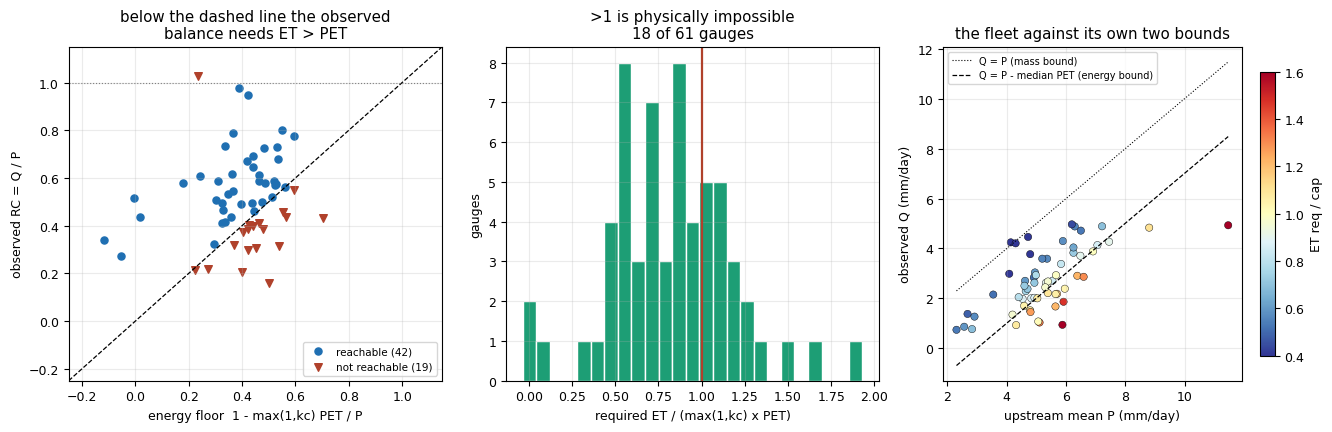

In [7]:
fig = plt.figure(figsize=(13.5, 4.4))
a = fig.add_subplot(1, 3, 1)
ok = FEAS.feasible.to_numpy()
a.scatter(FEAS.rc_floor[ok], FEAS.rc[ok], s=26, c='#1F6FB2', label=f'reachable ({ok.sum()})')
a.scatter(FEAS.rc_floor[~ok], FEAS.rc[~ok], s=30, c='#B0412B', marker='v',
          label=f'not reachable ({(~ok).sum()})')
lim = [-0.25, 1.15]
a.plot(lim, lim, 'k--', lw=.9)
a.axhline(1.0, color='grey', lw=.8, ls=':')
a.set_xlim(lim); a.set_ylim(lim)
a.set_xlabel('energy floor  1 - max(1,kc) PET / P')
a.set_ylabel('observed RC = Q / P')
a.set_title('below the dashed line the observed\nbalance needs ET > PET')
a.legend(fontsize=7.5); a.grid(alpha=.25)

a = fig.add_subplot(1, 3, 2)
a.hist(FEAS.et_req_over_cap_pet, bins=25, color='#1D9E75', edgecolor='w')
a.axvline(1.0, color='#B0412B', lw=1.6)
a.set_xlabel('required ET / (max(1,kc) x PET)')
a.set_ylabel('gauges')
a.set_title(f'>1 is physically impossible\n{(FEAS.et_req_over_cap_pet>1).sum()} of {NG} gauges')
a.grid(alpha=.25)

a = fig.add_subplot(1, 3, 3)
sc = a.scatter(FEAS.P, FEAS.Q, s=28, c=FEAS.et_req_over_cap_pet, cmap='RdYlBu_r',
               vmin=0.4, vmax=1.6, edgecolor='k', linewidth=.3)
xx = np.linspace(FEAS.P.min(), FEAS.P.max(), 50)
a.plot(xx, xx, 'k:', lw=.8, label='Q = P (mass bound)')
a.plot(xx, xx - FEAS.PET.median(), 'k--', lw=.9, label='Q = P - median PET (energy bound)')
a.set_xlabel('upstream mean P (mm/day)'); a.set_ylabel('observed Q (mm/day)')
a.set_title('the fleet against its own two bounds')
plt.colorbar(sc, ax=a, shrink=.85, label='ET req / cap')
a.legend(fontsize=7); a.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 2 - The split, decided and written down *before* the search

### 2.1 - The regimes, measured from this project's own forcing

`docs/07_enso_years.md` fixes the study's target on ONI grounds: **La Niña 2011** (from the strong
2010-11 event) against the **very strong El Niño of 2015-16**, with 2017 explicitly rejected as an
El Niño candidate because it was weak La Niña. The cell below does not take that on trust; it ranks
the nine model years by basin-mean rainfall computed here, so the regime labels are checked against
the forcing that the model will actually see.

In [8]:
yr = DATES.year.to_numpy()
P_BAS_D = (P_ALL * A_MB).sum(1) / A_TOT           # mm/day, area-weighted
E_BAS_D = (E_ALL * A_MB).sum(1) / A_TOT
ann = []
for y in range(2009, 2018):
    m = yr == y
    ann.append(dict(year=y, days=int(m.sum()), P=P_BAS_D[m].sum(), PET=E_BAS_D[m].sum()))
ANN = pd.DataFrame(ann)
ANN['P_anom_pct'] = 100 * (ANN.P / ANN.P.mean() - 1)
ANN['ENSO'] = ['El Nino 09-10', 'La Nina 10-11', 'LA NINA (target)', 'neutral', 'neutral',
               'neutral', 'EL NINO (target)', 'EL NINO (target)', 'weak La Nina']
print(ANN.to_string(index=False, float_format=lambda v: f'{v:8.1f}'))
print(f'\n9-year mean P {ANN.P.mean():,.1f} mm/yr (manifest: '
      f'{MAN["validation"]["basin_mean_P_mm_yr"]:,.1f} -> agree to '
      f'{abs(ANN.P.mean()-MAN["validation"]["basin_mean_P_mm_yr"]):.2f} mm/yr)')
print(f'wettest {ANN.loc[ANN.P.idxmax(),"year"]} ({ANN.P.max():,.0f} mm), '
      f'driest {ANN.loc[ANN.P.idxmin(),"year"]} ({ANN.P.min():,.0f} mm), '
      f'range {ANN.P.max()/ANN.P.min():.2f}x')
print('\nThe forcing agrees with the ONI labelling: the two wettest years of the record are '
      '2011 and 2010\n(the strong La Nina), and the driest is 2015 (the onset of the very strong '
      'El Nino).')

CAL_YEARS = [2012, 2013, 2014]
WU_YEAR = 2011
M_CAL = np.isin(yr, CAL_YEARS)
M_VAL = ~M_CAL
M_LANINA = yr == 2011
M_ELNINO = np.isin(yr, [2015, 2016])
M_VOTHER = np.isin(yr, [2009, 2010, 2017])
print(f'\nCAL  {CAL_YEARS}                 {M_CAL.sum():5d} days')
print(f'VAL  everything else            {M_VAL.sum():5d} days, of which')
print(f'      La Nina 2011              {M_LANINA.sum():5d}')
print(f'      El Nino 2015-16           {M_ELNINO.sum():5d}')
print(f'      other (2009, 2010, 2017)  {M_VOTHER.sum():5d}')

 year  days        P      PET  P_anom_pct             ENSO
 2009   365   1956.2   1240.3       -10.0    El Nino 09-10
 2010   365   2707.1   1185.9        24.5    La Nina 10-11
 2011   365   2735.2   1163.3        25.8 LA NINA (target)
 2012   366   2046.0   1247.8        -5.9          neutral
 2013   365   2093.3   1239.4        -3.7          neutral
 2014   365   1984.6   1271.6        -8.7          neutral
 2015   365   1649.7   1310.6       -24.1 EL NINO (target)
 2016   366   2042.5   1288.5        -6.1 EL NINO (target)
 2017   365   2352.4   1310.0         8.2     weak La Nina

9-year mean P 2,174.1 mm/yr (manifest: 2,174.3 -> agree to 0.17 mm/yr)
wettest 2011 (2,735 mm), driest 2015 (1,650 mm), range 1.66x

The forcing agrees with the ONI labelling: the two wettest years of the record are 2011 and 2010
(the strong La Nina), and the driest is 2015 (the onset of the very strong El Nino).

CAL  [2012, 2013, 2014]                  1096 days
VAL  everything else             2191 days

### 2.2 - Why the ENSO years are in **validation**, not calibration

This is a deliberate **differential split-sample test** in the sense of Klemeš (1986): when a model
will be used to simulate conditions *different* from those it was calibrated on, it must be
validated on the contrasting regime. The project's whole purpose is a La Niña / El Niño contrast, so:

* **If 2011 and 2015-16 were in calibration**, then "the model reproduces the ENSO contrast" would
  be circular - the parameters would have been chosen to make it so, and the statement would carry
  no information. Holding them out makes the contrast a **prediction**.
* **Calibration therefore uses 2012-2014**, the three consecutive ENSO-neutral years (measured
  anomalies of $-6\%$, $-4\%$, $-9\%$ - the three closest to the mean of any consecutive triple),
  with **2011 as warm-up only**: warm-up consumes forcing, never observations, so no discharge from
  a validation year enters the fit. Section 7 measures that one warm-up year is enough here.
* **Validation is the other six years**, reported in three blocks: La Niña 2011, El Niño 2015-16,
  and the remaining three (2009, 2010, 2017). The third block matters: it separates *temporal*
  transfer (does the fit survive other years at all?) from *climatic* transfer (does it survive a
  different regime?). Without it, a validation collapse could not be attributed.

**Alternatives rejected.**

| Rejected | Why |
|---|---|
| The conventional 2/3-calibration, 1/3-validation chronological split (2009-2014 / 2015-2017) | It puts La Niña 2011 **and** the 2010 flood year in calibration, i.e. the wet extreme is fitted and only the dry one is tested. The asymmetry would make the ENSO comparison uninterpretable. |
| Calibrate on the extremes, validate on the neutral years | Maximises calibration information but tests nothing the study cares about, and is the classic way to manufacture an impressive-looking hydrograph over the years in the report's headline figure. |
| Odd/even years, or random days | Random-day splitting is not a split at all for a model with 60-day groundwater memory: neighbouring days share state, so "validation" days are informed by their calibrated neighbours. Odd/even years leaks the regime: 2011 odd, 2015 odd, so the wet and dry extremes would sit on the same side. |
| Calibrate on 2009-2017 entirely, report no validation | Then nothing distinguishes calibration from curve-fitting. |
| Spatial split (calibrate on half the gauges, validate on the others) | Complementary, not alternative - and it answers a different question (spatial transfer). It is **also** done, as a secondary test, in section 10.5, because the parameter set is regionalised and spatial transferability is what regionalisation claims. |

The cost of this choice is stated rather than hidden: 1,096 calibration days instead of 3,287, i.e.
one third of the available record is used to fit and two thirds to test. Section 2.3 checks that
what remains is still enough.

In [9]:
def gauge_days(mask):
    return int(np.isfinite(QOBS[mask]).sum())


rows = []
for nm, m in (('CAL 2012-2014', M_CAL), ('VAL all', M_VAL), ('VAL La Nina 2011', M_LANINA),
              ('VAL El Nino 2015-16', M_ELNINO), ('VAL other 09/10/17', M_VOTHER)):
    ng = int((np.isfinite(QOBS[m]).sum(0) >= 30).sum())
    rows.append(dict(period=nm, days=int(m.sum()), gauge_days=gauge_days(m),
                     gauges_with_30d=ng, mean_days_per_gauge=gauge_days(m) / max(ng, 1)))
SPLIT = pd.DataFrame(rows)
print(SPLIT.to_string(index=False, float_format=lambda v: f'{v:9.1f}'))

# effective sample size: daily flows are strongly autocorrelated, so gauge-days
# massively overstate the information available to constrain parameters.
r1 = []
for j in range(NG):
    s = QOBS[:, j]
    a, b = s[:-1], s[1:]
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() > 500:
        r1.append(float(np.corrcoef(a[m], b[m])[0, 1]))
r1 = np.array(r1)
rho = float(np.median(r1))
n_eff_factor = (1 - rho) / (1 + rho)
print(f'\nlag-1 autocorrelation of observed daily Q: median {rho:.4f} '
      f'(p10 {np.percentile(r1,10):.3f}, p90 {np.percentile(r1,90):.3f}, n={len(r1)} gauges)')
print(f'AR(1) effective-sample factor (1-rho)/(1+rho) = {n_eff_factor:.4f}')
N_EFF_CAL = gauge_days(M_CAL) * n_eff_factor
print(f'=> CAL gauge-days {gauge_days(M_CAL):,} -> EFFECTIVE independent observations '
      f'~{N_EFF_CAL:,.0f}')
print(f'   (i.e. about {N_EFF_CAL/SPLIT.iloc[0].gauges_with_30d:,.0f} per gauge over three years,'
      f' ~{N_EFF_CAL/SPLIT.iloc[0].gauges_with_30d/3:,.0f} per gauge-year)')
print('\nThis is the number that sets the parameter budget in section 5.1 - NOT the '
      f'{gauge_days(M_CAL):,} raw gauge-days,\nwhich would flatter any parameter count.')
print('RECHECK 2a  a second, independent route. The AR(1) factor is equivalent to one')
print(f'            independent value every {1/n_eff_factor:.1f} days. A cruder count that assumes'
      f' one independent\n            hydrological event per 30-day recession time-scale gives '
      f'{SPLIT.iloc[0].gauges_with_30d} gauges x 3 yr x 365/30 = '
      f'{SPLIT.iloc[0].gauges_with_30d*3*365/30:,.0f}.')
print(f'            The two BRACKET the answer: {SPLIT.iloc[0].gauges_with_30d*3*365/30:,.0f} '
      f'(conservative, 30-day events) to {N_EFF_CAL:,.0f} (AR(1), '
      f'{1/n_eff_factor:.1f}-day decorrelation).')
print('            Both are thousands, not the 53 thousand of the raw count, and both are used')
print('            in section 5.1 - the parameter budget is checked against the CONSERVATIVE end.')
N_EFF_CONS = float(SPLIT.iloc[0].gauges_with_30d * 3 * 365 / 30)

             period  days  gauge_days  gauges_with_30d  mean_days_per_gauge
      CAL 2012-2014  1096       53499               59                906.8
            VAL all  2191      110393               61               1809.7
   VAL La Nina 2011   365       19777               58                341.0
VAL El Nino 2015-16   731       32543               56                581.1
 VAL other 09/10/17  1095       58073               61                952.0

lag-1 autocorrelation of observed daily Q: median 0.8008 (p10 0.581, p90 0.946, n=61 gauges)
AR(1) effective-sample factor (1-rho)/(1+rho) = 0.1106
=> CAL gauge-days 53,499 -> EFFECTIVE independent observations ~5,916
   (i.e. about 100 per gauge over three years, ~33 per gauge-year)

This is the number that sets the parameter budget in section 5.1 - NOT the 53,499 raw gauge-days,
which would flatter any parameter count.
RECHECK 2a  a second, independent route. The AR(1) factor is equivalent to one
            independent value every 9.0

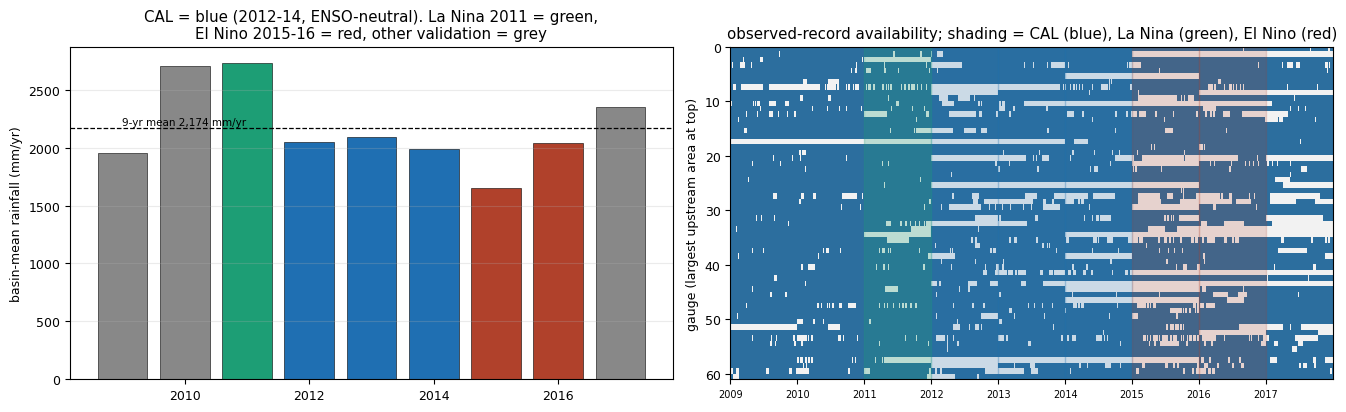

In [10]:
fig = plt.figure(figsize=(13.5, 4.2))
a = fig.add_subplot(1, 2, 1)
cols = {'CAL': '#1F6FB2', 'LN': '#1D9E75', 'EN': '#B0412B', 'OT': '#888888'}
for _, r in ANN.iterrows():
    y = int(r.year)
    c = cols['CAL'] if y in CAL_YEARS else (cols['LN'] if y == 2011 else
                                            (cols['EN'] if y in (2015, 2016) else cols['OT']))
    a.bar(y, r.P, color=c, edgecolor='k', linewidth=.4)
a.axhline(ANN.P.mean(), color='k', ls='--', lw=.9)
a.text(2009, ANN.P.mean() * 1.01, f'9-yr mean {ANN.P.mean():,.0f} mm/yr', fontsize=7.5)
a.set_ylabel('basin-mean rainfall (mm/yr)')
a.set_title('CAL = blue (2012-14, ENSO-neutral). La Nina 2011 = green,\n'
            'El Nino 2015-16 = red, other validation = grey')
a.grid(alpha=.25, axis='y')

a = fig.add_subplot(1, 2, 2)
val = np.isfinite(QOBS).astype(float)
srt = np.argsort(-GUP)
im = a.imshow(val[:, srt].T, aspect='auto', cmap=ListedColormap(['#F2F2F2', '#2C6E9E']),
              extent=[0, NDAYS, NG, 0], interpolation='nearest')
for y in CAL_YEARS:
    i0 = int(np.flatnonzero(yr == y)[0]); i1 = int(np.flatnonzero(yr == y)[-1])
    a.axvspan(i0, i1, color='#1F6FB2', alpha=.18)
for y in (2011,):
    i0 = int(np.flatnonzero(yr == y)[0]); i1 = int(np.flatnonzero(yr == y)[-1])
    a.axvspan(i0, i1, color='#1D9E75', alpha=.25)
for y in (2015, 2016):
    i0 = int(np.flatnonzero(yr == y)[0]); i1 = int(np.flatnonzero(yr == y)[-1])
    a.axvspan(i0, i1, color='#B0412B', alpha=.18)
tk = [int(np.flatnonzero(yr == y)[0]) for y in range(2009, 2018)]
a.set_xticks(tk); a.set_xticklabels(range(2009, 2018), fontsize=7)
a.set_ylabel('gauge (largest upstream area at top)')
a.set_title('observed-record availability; shading = CAL (blue), La Nina (green), '
            'El Nino (red)')
plt.tight_layout(); plt.show()

## 3 - The parameter space: what is free, over what range, and why

**Which fields the engine allows to vary where** is not a free choice - it is a property of
`MgbParams`, and getting it wrong is the kind of mistake that runs silently:

* **per-URH (length 24)**: `wm_scale`, `b`, `kc`, `lai`, `alpha_int`, `adr`, `fint`. Since the URH id
  is `soil_family*10 + land_class`, a per-URH field can be differentiated **by soil family** or **by
  land class** - which is exactly where a drainage parameter and a crop coefficient belong.
* **per-minibacia (length 8,672)**: `wm_mini`, `k_sup`, `k_int`, `k_bas`, `tau_channel`. These are
  the only fields that can carry a **spatial region**.

So the two regionalisation axes available are physically the right ones for their parameters, and
section 5 uses both. Nothing in the engine is modified: `src/mgb_hydrology.py` and its 59-assertion
test suite are untouched (its sha256 is recorded in 0.1).

| # | parameter | prior (nb13) | range searched | why this range | rejected |
|---|---|---|---|---|---|
| 1 | $a_{dr}$ (d⁻¹), log | 0.06 | 0.0005 - 0.30 | the diagnosed error. The lower end is "the soil barely drains" (baseflow ~0.03 mm/d), the upper "the column empties in three days". Log scale because the parameter acts multiplicatively on $W$ and its plausible span is three decades. | A narrow bracket around 0.06. Rejected: nb13's mean-field algebra says the answer is roughly an order of magnitude below 0.06, so a narrow bracket would have excluded the answer. |
| 2 | $f_{int}$ | 0.60 | 0.05 - 0.95 | the interflow/groundwater split; the full open interval, since nothing measured constrains it. | Fixing it at 0.6. Rejected: it controls the recession *shape*, which is one of the few things daily discharge genuinely sees. |
| 3 | $b$, log | 0.60 | 0.05 - 4.0 | shape of the variable contributing area. $b\to0$: saturation excess switched off; $b=4$: 94 % of a half-full cell contributes. | $b\in[0.3,1]$ from MGB-IPH applications. Rejected: those are *other basins'* calibrated answers, and importing them would smuggle in a fit. |
| 4 | $W_m$ multiplier, log | 1.0 | 0.25 - 6.0 | multiplies the **IGAC** $W_m$ field, so the measured 19x spatial pattern is kept and only its level is fitted. Wide because nb09 derives $W_m$ = AWC x depth, and rooting depth (not soil depth) is what the model needs - a factor of a few is entirely possible. | Fitting per-minibacia $W_m$ (8,672 free numbers). Rejected: hopeless overfitting, and it would discard the IGAC survey. |
| 5 | $k_c$ multiplier | 1.0 | 0.50 - 2.00 | multiplies the FAO-56 per-land-class vector, preserving the asphalt-vs-forest contrast. Above 1 is allowed for the reason derived in section 1.3. | Capping at 1.0. Rejected: section 1.2 shows the basin balance is then unreachable by construction, so the search would be forced into a corner and the diagnosis would be hidden. |
| 6 | LAI multiplier | 1.0 | 0.0 - 5.0 | scales canopy storage $S_{i,max}=\alpha_{int}\mathrm{LAI}$. nb13 measured the prior at 3.0 % of $P$ where tropical-forest field studies report 10-20 %, so the range must reach well above 1. | Fitting $\alpha_{int}$ too. Rejected: only the product $\alpha_{int}\mathrm{LAI}$ enters the equations, so the two are not separately identifiable - fitting both is fitting two knobs to one number. |
| 7 | $K_{sup}$ (d), log | 1.5 | 0.2 - 20 | surface reservoir. Sub-daily is allowed because the analytic release coefficient is stable for any $K>0$ (the Euler form would not be - engine test 9a). | Bounding below at 1 d. Rejected: flashy Andean headwaters plausibly respond faster than a day. |
| 8 | $K_{int}$ (d), log | 8 | 1.5 - 120 | subsurface reservoir. | - |
| 9 | $K_{bas}$ (d), log | 60 | 15 - 600 | groundwater reservoir; the upper end is a two-year memory, which the dry-season sustainment of the big Andean tributaries could require. | Bounding at 200 d for "physical realism". Rejected: that is an assumption about the answer; section 7 instead *measures* that the warm-up copes with 600 d. |
| 10 | channel celerity (m s⁻¹), log | 1.0 | 0.05 - 4.0 | sets $\tau_i = L_i/(c\cdot86400)$ from the measured `reach_km`. The very low end is retained **deliberately**: section 4.3 shows the search wants it, and section 11 argues that when it goes there it is no longer a celerity but the only available proxy for the Mompos / La Mojana floodplain storage the routing cannot represent. | Fixing $c=1$ m/s (nb13's prior). Rejected on measurement: at the outlet, moving $c$ alone changes KGE by more than 0.3. |

Fixed, and stated so: `percolation='linear'` (the `'mgb'` non-linear form adds four more unmeasured
numbers and no new information about this basin), `reservoir='exact'`, `alpha_int=0.2` mm,
and the **shape** of the $k_c$, LAI and $W_m$ fields (only their level is fitted).

In [11]:
NAMES = ['adr', 'fint', 'b', 'wm_mult', 'kc_mult', 'lai_mult',
         'k_sup', 'k_int', 'k_bas', 'celerity']
IS_LOG = np.array([True, False, True, True, False, False, True, True, True, True])
RAW_LO = np.array([5e-4, 0.05, 0.05, 0.25, 0.50, 0.0, 0.20, 1.50, 15.0, 0.05])
RAW_HI = np.array([0.30, 0.95, 4.00, 6.00, 2.00, 5.0, 20.0, 120.0, 600.0, 4.00])
RAW_P0 = np.array([0.06, 0.60, 0.60, 1.00, 1.00, 1.0, 1.50, 8.00, 60.0, 1.00])
# fields that can carry a SPATIAL region (per-minibacia in MgbParams)
SPATIAL_OK = ['wm_mult', 'k_sup', 'k_int', 'k_bas', 'celerity']
# fields that can carry a SOIL-FAMILY split (per-URH in MgbParams)
SOIL_OK = ['adr', 'fint', 'b']

fwd = lambda v, lg: np.where(lg, np.log(np.maximum(v, 1e-300)), v)      # noqa: E731
inv = lambda x, lg: np.where(lg, np.exp(x), x)                          # noqa: E731
LO, HI, X0 = (fwd(RAW_LO, IS_LOG), fwd(RAW_HI, IS_LOG), fwd(RAW_P0, IS_LOG))
assert np.all(LO < X0) and np.all(X0 < HI), 'a prior sits on or outside its own range'
print(pd.DataFrame(dict(parameter=NAMES, prior=RAW_P0, lo=RAW_LO, hi=RAW_HI,
                        log=IS_LOG,
                        span_decades=np.where(IS_LOG, np.log10(RAW_HI / np.where(RAW_LO > 0,
                                                                                RAW_LO, 1.0)),
                                              np.nan),
                        spatial=[n in SPATIAL_OK for n in NAMES],
                        soil_split=[n in SOIL_OK for n in NAMES]))
      .to_string(index=False, float_format=lambda v: f'{v:8.4f}'))
NP0 = len(NAMES)

parameter    prior       lo       hi   log  span_decades  spatial  soil_split
      adr   0.0600   0.0005   0.3000  True        2.7782    False        True
     fint   0.6000   0.0500   0.9500 False           NaN    False        True
        b   0.6000   0.0500   4.0000  True        1.9031    False        True
  wm_mult   1.0000   0.2500   6.0000  True        1.3802     True       False
  kc_mult   1.0000   0.5000   2.0000 False           NaN    False       False
 lai_mult   1.0000   0.0000   5.0000 False           NaN    False       False
    k_sup   1.5000   0.2000  20.0000  True        2.0000     True       False
    k_int   8.0000   1.5000 120.0000  True        1.9031     True       False
    k_bas  60.0000  15.0000 600.0000  True        1.6021     True       False
 celerity   1.0000   0.0500   4.0000  True        1.9031     True       False


### 3.1 - The runner: parameter vector to `MgbParams`, and the equilibrium start

`build_params` maps a search vector to an `MgbParams`. It accepts optional **region** overrides for
the per-minibacia fields and optional **soil-family** overrides for the per-URH fields, so a global
configuration is a strict *sub-space* of a regionalised one. That matters twice: it makes the
comparison in section 8.4 a nested-model comparison rather than a comparison of two unrelated
searches, and it lets the regionalised search be **started from the global optimum**, so it cannot
be worse on calibration and the only open question is validation.

`eq_state` writes down the initial state instead of guessing it. For the candidate parameter set it
solves the mean-field soil balance
$\bar P (1-x)^b = k_c\overline{PET}x + a_{dr}W_m x$, $x=W/W_m$, per cell by bisection (no time loop),
then puts each linear reservoir at the equilibrium storage $S^\*=I/(1-e^{-\Delta t/K})$ implied by
that solution. Because the start adapts to the parameters, a slow-groundwater candidate does not
begin from a fast-groundwater state - which is what makes a **one-year** warm-up sufficient
(measured in section 7) and the whole search affordable.

In [12]:
CELL_MINI, CELL_URH, CELL_FRAC = TOPO.cell_mini, TOPO.cell_urh, TOPO.cell_frac


def build_params(x, reg_lab=None, reg_over=None, soil_over=None):
    '''x: length-NP0 vector in transformed space.
    reg_over : {name: array of NREG values (transformed)} for per-minibacia fields
    soil_over: {name: array of 3 values (transformed)} for per-URH fields, by soil family
    '''
    v = dict(zip(NAMES, inv(np.asarray(x, float), IS_LOG)))
    wm = WM0 * v['wm_mult']
    ks = np.full(TOPO.n_mini, v['k_sup'])
    ki = np.full(TOPO.n_mini, v['k_int'])
    kb = np.full(TOPO.n_mini, v['k_bas'])
    cel = np.full(TOPO.n_mini, v['celerity'])
    if reg_over:
        arrs = {'wm_mult': None, 'k_sup': ks, 'k_int': ki, 'k_bas': kb, 'celerity': cel}
        for nm, vals in reg_over.items():
            rv = inv(np.asarray(vals, float), IS_LOG[NAMES.index(nm)])
            for k in range(int(reg_lab.max()) + 1):
                sel = reg_lab == k
                if nm == 'wm_mult':
                    wm[sel] = WM0[sel] * rv[k]
                else:
                    arrs[nm][sel] = rv[k]
    adr = np.full(len(U24), v['adr'])
    fint = np.full(len(U24), v['fint'])
    bsh = np.full(len(U24), v['b'])
    if soil_over:
        tgt = {'adr': adr, 'fint': fint, 'b': bsh}
        for nm, vals in soil_over.items():
            sv = inv(np.asarray(vals, float), IS_LOG[NAMES.index(nm)])
            for si in (1, 2, 3):
                tgt[nm][SOIL_OF_URH == si] = sv[si - 1]
    tau = REACH_KM * 1000.0 / (cel * 86400.0)
    return mgb.MgbParams(wm_mini=wm, b=bsh, kc=KC0 * v['kc_mult'], lai=LAI0 * v['lai_mult'],
                         alpha_int=ALPHA_INT, adr=adr, fint=fint, percolation='linear',
                         reservoir='exact', k_sup=ks, k_int=ki, k_bas=kb, tau_channel=tau)


def eq_state(params, p_mean, e_mean, n_bis=60):
    ex = params.expand(TOPO)
    pc, ec = p_mean[CELL_MINI], e_mean[CELL_MINI]
    lo = np.zeros_like(pc); hi = np.ones_like(pc)
    for _ in range(n_bis):
        mid = .5 * (lo + hi)
        pos = (pc * np.power(np.maximum(1 - mid, 0), ex.b) - ex.kc * ec * mid
               - ex.adr * ex.wm * mid) > 0
        lo = np.where(pos, mid, lo); hi = np.where(pos, hi, mid)
    x = .5 * (lo + hi)
    resid = np.abs(pc * np.power(np.maximum(1 - x, 0), ex.b) - ex.kc * ec * x
                   - ex.adr * ex.wm * x).max()
    drain = ex.adr * x * ex.wm
    d_sup = np.bincount(CELL_MINI, weights=pc * (1 - np.power(np.maximum(1 - x, 0), ex.b))
                        * CELL_FRAC, minlength=TOPO.n_mini)
    d_int = np.bincount(CELL_MINI, weights=ex.fint * drain * CELL_FRAC, minlength=TOPO.n_mini)
    d_bas = np.bincount(CELL_MINI, weights=(1 - ex.fint) * drain * CELL_FRAC,
                        minlength=TOPO.n_mini)
    st = mgb.MgbState(sc=np.zeros(TOPO.n_cells), w=x * ex.wm, s_sup=d_sup / ex.c_sup,
                      s_int=d_int / ex.c_int, s_bas=d_bas / ex.c_bas,
                      s_ch=np.zeros(TOPO.n_mini))
    return st, float(resid), x


# --- calibration segment: warm-up 2011 + CAL 2012-2014, contiguous -----------
M_SEG = np.isin(yr, [WU_YEAR] + CAL_YEARS)
SEG_POS = np.flatnonzero(M_SEG)
N_WU = int((yr == WU_YEAR).sum())
POS_CAL = SEG_POS[N_WU:]
assert np.array_equal(POS_CAL, np.flatnonzero(M_CAL)), 'segment/CAL alignment broken'
P_SEG, E_SEG = P_ALL[M_SEG], E_ALL[M_SEG]
PM_SEG, EM_SEG = P_SEG.mean(0), E_SEG.mean(0)


def run_seg(x, reg_lab=None, reg_over=None, soil_over=None):
    pr = build_params(x, reg_lab, reg_over, soil_over)
    st, _, _ = eq_state(pr, PM_SEG, EM_SEG)
    res = mgb.simulate(TOPO, pr, P_SEG, E_SEG, state=st, warmup_days=N_WU,
                       record_ids=REC_IDS, routing_backend='auto')
    return res


t0 = time.perf_counter()
_r = run_seg(X0)
print(f'segment run: {M_SEG.sum()} d ({N_WU} warm-up + {len(POS_CAL)} scored), '
      f'{time.perf_counter()-t0:.2f} s wall, {_r.wall_time_s:.2f} s engine, '
      f'backend {_r.routing_backend}')
print(f'  mass balance residual_relative {_r.balance["residual_relative"]:.3e}  '
      f'runoff coefficient {_r.balance["runoff_coefficient"]:.4f}')
SEC_PER_EVAL = time.perf_counter() - t0
print(f'  => {SEC_PER_EVAL:.2f} s per objective evaluation sets every budget below')

segment run: 1461 d (365 warm-up + 1096 scored), 5.73 s wall, 5.64 s engine, backend numba
  mass balance residual_relative 2.502e-16  runoff coefficient 0.7313
  => 5.73 s per objective evaluation sets every budget below


### 3.2 - `build_params` and `eq_state` are checked against notebook 13 before use

Two independent checks, both with a target computed elsewhere:

1. `eq_state` must reproduce nb13's **registered prediction** of the basin runoff coefficient,
   0.7301089204, at nb13's parameters. That number was derived in a different notebook by different
   code before the baseline ran, so agreement is a genuine cross-implementation test of the
   mean-field solver.
2. `build_params(X0)` must reproduce nb13's **simulated** flows. nb13 warmed up on 2008 and this
   notebook's segment run warms up on 2011, so the two are not expected to agree day by day - what
   must agree is the *parameterisation*: identical `MgbParams` content.

In [13]:
pr0 = build_params(X0)
st0, resid0, x_mf = eq_state(pr0, P_ALL.mean(0), E_ALL.mean(0))
ex0 = pr0.expand(TOPO)
et_mf = float((ex0.kc * E_ALL.mean(0)[CELL_MINI] * x_mf * TOPO.cell_area_km2).sum()
              / A_TOT * 365.25)
p_mf = float((P_ALL.mean(0)[CELL_MINI] * TOPO.cell_area_km2).sum() / A_TOT * 365.25)
rc_pred = 1 - et_mf / p_mf
rc_nb13 = BASE_PJ['prediction_registered_before_the_run']['predicted_runoff_coefficient']
print(f'CHECK 3a  mean-field runoff coefficient at nb13 parameters')
print(f'          this notebook {rc_pred:.10f}   nb13 registered {rc_nb13:.10f}   '
      f'|diff| {abs(rc_pred-rc_nb13):.2e}')
print(f'          bisection residual {resid0:.3e} mm/day, area-weighted equilibrium W/Wm '
      f'{np.average(x_mf, weights=TOPO.cell_area_km2):.4f}')
print(f'          nb13 also recorded its interception-off simulated coefficient '
      f'{BASE_PJ["prediction_registered_before_the_run"]["simulated_interception_off"]:.4f} '
      f'and its\n          baseline '
      f'{BASE_PJ["prediction_registered_before_the_run"]["simulated_baseline"]:.4f} vs observed '
      f'{BASE_PJ["prediction_registered_before_the_run"]["observed_calamar"]:.4f}')
assert abs(rc_pred - rc_nb13) < 1e-6, 'mean-field solver disagrees with nb13'

print(f'\nCHECK 3b  build_params(X0) vs nb13 priors, field by field')
chk = [('adr', ex0.adr.min(), _pj['percolation']['adr_per_day']),
       ('fint', ex0.fint.min(), _pj['percolation']['fint']),
       ('b', ex0.b.min(), _pj['b']['value']),
       ('Wm median', float(np.median(pr0.wm_mini)), float(_pj['wm_mini']['median'])),
       ('k_sup', float(np.min(pr0.k_sup)), _pj['reservoir']['k_sup_d']),
       ('k_int', float(np.min(pr0.k_int)), _pj['reservoir']['k_int_d']),
       ('k_bas', float(np.min(pr0.k_bas)), _pj['reservoir']['k_bas_d']),
       ('tau median (d)', float(np.median(pr0.tau_channel)), _pj['tau_channel']['median_d']),
       ('kc area-wtd', float(np.average((PAR['urh_fraction'].astype(float) @ KC0),
                                        weights=A_MB)), _pj['kc']['area_weighted_mean'])]
for nm, got, want in chk:
    ok = abs(got - want) < max(1e-6, 1e-6 * abs(want))
    print(f'  {"PASS" if ok else "FAIL"}  {nm:<15s} this {got:.8f}  nb13 {want:.8f}')
    assert ok, f'{nm} differs from nb13'
N_SMOKE += len(chk) + 1
print(f'\n{N_SMOKE} assertions passed so far')

CHECK 3a  mean-field runoff coefficient at nb13 parameters
          this notebook 0.7301089204   nb13 registered 0.7301089204   |diff| 0.00e+00
          bisection residual 3.553e-15 mm/day, area-weighted equilibrium W/Wm 0.4861
          nb13 also recorded its interception-off simulated coefficient 0.7543 and its
          baseline 0.7238 vs observed 0.4022

CHECK 3b  build_params(X0) vs nb13 priors, field by field
  PASS  adr             this 0.06000000  nb13 0.06000000
  PASS  fint            this 0.60000000  nb13 0.60000000
  PASS  b               this 0.60000000  nb13 0.60000000
  PASS  Wm median       this 72.59999847  nb13 72.59999847
  PASS  k_sup           this 1.50000000  nb13 1.50000000
  PASS  k_int           this 8.00000000  nb13 8.00000000
  PASS  k_bas           this 60.00000000  nb13 60.00000000
  PASS  tau median (d)  this 0.05872235  nb13 0.05872235
  PASS  kc area-wtd     this 0.95769776  nb13 0.95769776

25 assertions passed so far


## 4 - Sensitivity screening: which parameters have earned a place in the search

Two screenings, because they answer different questions and neither alone is enough.

**4.1 One-at-a-time (OAT) at the prior.** Cheap, exactly interpretable, and it reports the
*derivative at the point calibration starts from*. Its known failure is that it is local: a
parameter can be flat at the prior and dominant elsewhere.

**4.2 Morris elementary effects.** A global screening that samples trajectories across the whole
hyper-rectangle and averages $|\Delta F/\Delta x|$, giving $\mu^*$ (overall influence) and $\sigma$
(interaction / non-linearity). Morris is chosen over a variance-based method (Sobol) purely on cost:
Sobol needs $O(10^3 D)$ evaluations for stable indices, i.e. days of wall time here, while Morris
gives a usable *ranking* - which is all a screening needs - for $R(D+1)$.
*Rejected alternative*: skipping the screening and calibrating all ten parameters. That would still
"work", but the notebook could not then say which parameters the data actually identifies, and
section 10.3 would have nothing to test the answer against.

**4.3 The same effects on the large gauges alone.** The fleet objective weights all 61 gauges
equally (section 6.4), and 53 of them are below 4,000 km². A parameter that only matters where the
routing matters is therefore nearly invisible to the fleet mean. This third view exists to catch
exactly that, and it does.

In [14]:
ALLROWS = np.ones(len(POS_CAL), bool)
BIG = GUP >= 10000.0
print(f'large-gauge subset for 4.3: {int(BIG.sum())} gauges with upstream area >= 10,000 km2 '
      f'({GUP[BIG].min():,.0f} .. {GUP[BIG].max():,.0f} km2)')
SCREEN_SUB = np.zeros(NG, bool)
_ord = np.argsort(GUP)
for _k in range(12):                              # 12 gauges spread over the area range
    SCREEN_SUB[_ord[int(round(_k * (NG - 1) / 11))]] = True
print(f'screening gauge subset (log-area stratified, 12 of {NG}): '
      f'{", ".join(GC[SCREEN_SUB])}')


def gauge_kge(qsim, pos, rows=None):
    '''Per-gauge KGE on Q and on log Q. qsim rows align with pos (positions into DATES).'''
    obs = QOBS[pos] if rows is None else QOBS[pos][rows]
    sim = qsim if rows is None else qsim[rows]
    k1 = np.full(NG, np.nan); k2 = np.full(NG, np.nan)
    for j in range(NG):
        s = sim[:, j].astype(np.float64); o = obs[:, j]
        k1[j] = kge_terms(s, o)['kge']
        k2[j] = kge_terms(np.log(np.maximum(s, 0) + QLOG0[j]),
                          np.log(np.maximum(o, 0) + QLOG0[j]))['kge']
    return k1, k2


QLOG0 = np.nanmean(QOBS, axis=0) * 0.01           # per-gauge log offset, justified in 6.3
W_LOG = 0.5


def blend(k1, k2, sel=None, w=W_LOG):
    v = (1 - w) * c2m(k1) + w * c2m(k2)
    if sel is not None:
        v = v[sel]
    ok = np.isfinite(v)
    return float(v[ok].mean()) if ok.any() else np.nan


def F_of(x, **kw):
    '''The objective actually optimised, plus everything needed later, in one run.'''
    res = run_seg(x, **kw)
    k1, k2 = gauge_kge(res.q_m3s, POS_CAL)
    return blend(k1, k2), dict(k1=k1, k2=k2, rc=res.balance['runoff_coefficient'],
                               resid=res.balance['residual_relative'])


t0 = time.perf_counter()
f0, ex_0 = F_of(X0)
print(f'\nF(prior) on CAL 2012-2014 = {f0:.5f}   '
      f'median KGE {np.nanmedian(ex_0["k1"]):.3f}, median logKGE {np.nanmedian(ex_0["k2"]):.3f}'
      f'   [{time.perf_counter()-t0:.1f} s]')

OAT = []
for i, nm in enumerate(NAMES):
    span = HI[i] - LO[i]
    vals = {}
    for frac in (-0.30, +0.30):
        xx = X0.copy(); xx[i] = float(np.clip(X0[i] + frac * span, LO[i], HI[i]))
        f, exd = F_of(xx)
        vals[frac] = (f, exd)
    OAT.append(dict(parameter=nm,
                    dF_minus=vals[-0.30][0] - f0, dF_plus=vals[+0.30][0] - f0,
                    max_abs=max(abs(vals[-0.30][0] - f0), abs(vals[+0.30][0] - f0)),
                    dKGE_big=max(abs(np.nanmean(vals[f][1]['k1'][BIG] - ex_0['k1'][BIG]))
                                 for f in (-0.30, 0.30))))
OATd = pd.DataFrame(OAT).sort_values('max_abs', ascending=False)
print(f'\nOAT: prior +/- 30 % of each range, {1+2*NP0} runs, '
      f'{time.perf_counter()-t0:.0f} s')
print(OATd.to_string(index=False, float_format=lambda v: f'{v:9.5f}'))

large-gauge subset for 4.3: 7 gauges with upstream area >= 10,000 km2 (19,294 .. 257,097 km2)
screening gauge subset (log-area stratified, 12 of 61): 21017030, 21237040, 22017010, 22017030, 25017010, 26027090, 26027200, 26167070, 26197010, 26237020, 28047010, 29037020



F(prior) on CAL 2012-2014 = 0.12764   median KGE 0.083, median logKGE 0.432   [5.0 s]



OAT: prior +/- 30 % of each range, 21 runs, 102 s
parameter  dF_minus   dF_plus   max_abs  dKGE_big
      adr  -0.12176  -0.02391   0.12176   0.35464
  wm_mult  -0.11079  -0.00917   0.11079   0.48538
        b   0.01459  -0.08767   0.08767   0.56578
    k_sup  -0.07774   0.02565   0.07774   0.25418
  kc_mult  -0.02997   0.02106   0.02997   0.20106
     fint   0.00600  -0.01813   0.01813   0.09612
    k_bas  -0.01724  -0.00005   0.01724   0.08074
 lai_mult  -0.01458   0.01595   0.01595   0.13457
 celerity   0.01140  -0.00001   0.01140   0.11228
    k_int  -0.00978   0.00731   0.00978   0.12227


In [15]:
def morris(fun, lo, hi, n_traj, seed, n_levels=8):
    '''Morris (1991) elementary effects with the Campolongo winding-stair sampler.
    Returns mu*, sigma per dimension and the full evaluation archive.
    delta = n_levels/(2(n_levels-1)) in unit space -> a fixed, symmetric step.'''
    rng = np.random.default_rng(seed)
    d = lo.size
    delta = n_levels / (2.0 * (n_levels - 1))
    grid = np.linspace(0, 1 - delta, n_levels // 2)
    EE = []
    arch = []
    for _t in range(n_traj):
        base = rng.choice(grid, size=d)
        perm = rng.permutation(d)
        sgn = rng.choice([-1.0, 1.0], size=d)
        pts = [base.copy()]
        cur = base.copy()
        for j in perm:
            cur = cur.copy()
            step = sgn[j] * delta
            if not (0.0 <= cur[j] + step <= 1.0):
                step = -step
            cur[j] = cur[j] + step
            pts.append(cur.copy())
        fs = []
        for u in pts:
            x = lo + np.clip(u, 0, 1) * (hi - lo)
            f, exd = fun(x)
            fs.append(f)
            arch.append((x.copy(), f, exd))
        for k, j in enumerate(perm):
            dx = pts[k + 1][j] - pts[k][j]
            EE.append((j, (fs[k + 1] - fs[k]) / dx))
    mu_s = np.zeros(d); sd = np.zeros(d)
    for j in range(d):
        e = np.array([v for jj, v in EE if jj == j])
        mu_s[j] = np.abs(e).mean(); sd[j] = e.std(ddof=1) if e.size > 1 else 0.0
    return mu_s, sd, arch


N_TRAJ = 6
t0 = time.perf_counter()
MU, SD, MARCH = morris(F_of, LO, HI, N_TRAJ, seed=20260814)
print(f'Morris: {N_TRAJ} trajectories x {NP0+1} = {N_TRAJ*(NP0+1)} runs, '
      f'{time.perf_counter()-t0:.0f} s ({(time.perf_counter()-t0)/(N_TRAJ*(NP0+1)):.2f} s/run)')

# the same elementary effects recomputed on two sub-objectives, at zero extra cost,
# by re-scoring the stored per-gauge KGEs of every Morris evaluation
def mu_star_for(sel):
    vals = np.array([blend(a[2]['k1'], a[2]['k2'], sel=sel) for a in MARCH])
    out = np.zeros(NP0); cnt = np.zeros(NP0)
    k = 0
    for _t in range(N_TRAJ):
        seg = vals[k:k + NP0 + 1]
        xs = np.array([MARCH[k + i][0] for i in range(NP0 + 1)])
        for i in range(NP0):
            j = int(np.argmax(np.abs(xs[i + 1] - xs[i])))
            dx = (xs[i + 1][j] - xs[i][j]) / (HI[j] - LO[j])
            out[j] += abs((seg[i + 1] - seg[i]) / dx); cnt[j] += 1
        k += NP0 + 1
    return out / np.maximum(cnt, 1)


MU_BIG = mu_star_for(BIG)
MU_SUB = mu_star_for(SCREEN_SUB)
SCR = pd.DataFrame(dict(parameter=NAMES, mu_star=MU, sigma=SD,
                        mu_star_big=MU_BIG, mu_star_screen12=MU_SUB,
                        oat=[float(OATd.set_index('parameter').max_abs[n]) for n in NAMES]))
SCR['rank_fleet'] = SCR.mu_star.rank(ascending=False).astype(int)
SCR['rank_big'] = SCR.mu_star_big.rank(ascending=False).astype(int)
SCR['big_over_fleet'] = SCR.mu_star_big / SCR.mu_star.replace(0, np.nan)
SCR = SCR.sort_values('mu_star', ascending=False)
print('\nMorris screening (mu* = mean |elementary effect| in unit-cube space)')
print(SCR.to_string(index=False, float_format=lambda v: f'{v:9.4f}'))
print('\nRANK AGREEMENT between the two independent screenings (Spearman, all 10 parameters):')
rs = pd.Series(SCR.mu_star.to_numpy()).rank().corr(
    pd.Series(SCR.oat.to_numpy()).rank(), method='spearman')
print(f'  Morris mu* vs OAT |dF| : rho = {rs:.3f}')
print(f'  Morris mu* vs mu* on the 12-gauge stratified subset : rho = '
      f'{pd.Series(SCR.mu_star.to_numpy()).rank().corr(pd.Series(SCR.mu_star_screen12.to_numpy()).rank(), method="spearman"):.3f}')

Morris: 6 trajectories x 11 = 66 runs, 314 s (4.76 s/run)

Morris screening (mu* = mean |elementary effect| in unit-cube space)
parameter   mu_star     sigma  mu_star_big  mu_star_screen12       oat  rank_fleet  rank_big  big_over_fleet
    k_sup    0.2280    0.3183       0.2972            0.2123    0.0777           1         2          1.3036
      adr    0.2247    0.2128       0.3772            0.2903    0.1218           2         1          1.6786
  wm_mult    0.2029    0.1649       0.2511            0.1872    0.1108           3         3          1.2375
 celerity    0.0515    0.0410       0.2103            0.0690    0.0114           4         4          4.0819
    k_bas    0.0437    0.0708       0.0678            0.0291    0.0172           5         7          1.5497
        b    0.0436    0.0354       0.0668            0.0375    0.0877           6         8          1.5319
 lai_mult    0.0423    0.0413       0.0657            0.0357    0.0160           7         9          1.5552


  Morris mu* vs OAT |dF| : rho = 0.479
  Morris mu* vs mu* on the 12-gauge stratified subset : rho = 0.709


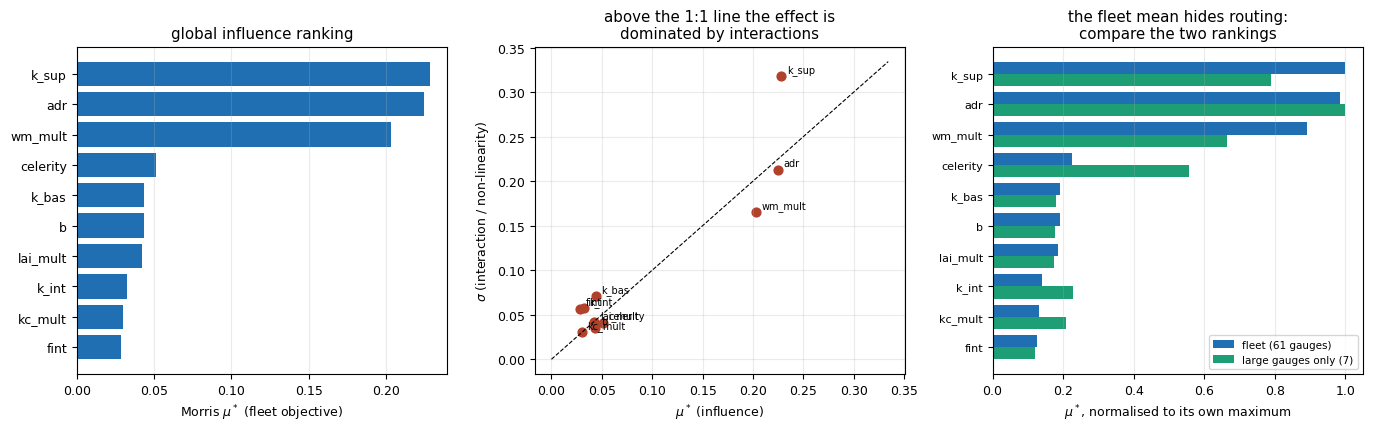

In [16]:
fig = plt.figure(figsize=(13.8, 4.4))
a = fig.add_subplot(1, 3, 1)
o = SCR.sort_values('mu_star')
a.barh(o.parameter, o.mu_star, color='#1F6FB2')
a.set_xlabel('Morris $\\mu^*$ (fleet objective)'); a.set_title('global influence ranking')
a.grid(alpha=.25, axis='x')
a = fig.add_subplot(1, 3, 2)
a.scatter(SCR.mu_star, SCR.sigma, s=40, c='#B0412B')
for _, r in SCR.iterrows():
    a.annotate(r.parameter, (r.mu_star, r.sigma), fontsize=7,
               textcoords='offset points', xytext=(4, 3))
mx = max(SCR.mu_star.max(), SCR.sigma.max()) * 1.05
a.plot([0, mx], [0, mx], 'k--', lw=.8)
a.set_xlabel('$\\mu^*$ (influence)'); a.set_ylabel('$\\sigma$ (interaction / non-linearity)')
a.set_title('above the 1:1 line the effect is\ndominated by interactions')
a.grid(alpha=.25)
a = fig.add_subplot(1, 3, 3)
ww = np.arange(len(SCR))
a.barh(ww - .2, SCR.mu_star / SCR.mu_star.max(), .4, color='#1F6FB2', label='fleet (61 gauges)')
a.barh(ww + .2, SCR.mu_star_big / SCR.mu_star_big.max(), .4, color='#1D9E75',
       label=f'large gauges only ({int(BIG.sum())})')
a.set_yticks(ww); a.set_yticklabels(SCR.parameter, fontsize=8)
a.invert_yaxis(); a.set_xlabel('$\\mu^*$, normalised to its own maximum')
a.set_title('the fleet mean hides routing:\ncompare the two rankings')
a.legend(fontsize=7.5); a.grid(alpha=.25, axis='x')
plt.tight_layout(); plt.show()

### 4.4 - The decision rule, stated before its outcome is read

Two decisions come out of the screening, and both are taken by a rule fixed in advance so the
outcome cannot be reverse-engineered from the results.

**Which parameters are calibrated.** All ten are kept if every $\mu^*$ is above 5 % of the largest;
any parameter below that is frozen at its prior and *reported as unidentifiable by this data*,
because carrying a parameter the objective cannot see is how a search buys apparent freedom at the
cost of a meaningless "calibrated value". The threshold is 5 % of $\mu^*_{max}$ rather than a
significance test because Morris with 6 trajectories has no usable sampling distribution - it is a
screening, and the honest use of a screening is an order-of-magnitude cut.

**Which parameters get a region.** The three per-minibacia parameters with the highest
$\max\big(\mu^*/\mu^*_{max},\ \mu^*_{big}/\mu^{*}_{big,max}\big)$. Taking the maximum of the two
normalised scores is the part that matters: it is what lets a parameter qualify on the strength of
the large-gauge view alone, which is precisely the case section 4.3 was built to detect.

In [17]:
KEEP_FRAC = 0.05
mu_max = SCR.mu_star.max()
FROZEN = [r.parameter for _, r in SCR.iterrows() if r.mu_star < KEEP_FRAC * mu_max]
ACTIVE = [n for n in NAMES if n not in FROZEN]
print(f'mu*_max = {mu_max:.4f} ({SCR.iloc[0].parameter}); cut at {KEEP_FRAC:.0%} = '
      f'{KEEP_FRAC*mu_max:.5f}')
print(f'CALIBRATED ({len(ACTIVE)}): {ACTIVE}')
print(f'FROZEN at the prior ({len(FROZEN)}): {FROZEN if FROZEN else "none"}')

score_reg = np.maximum(SCR.mu_star / SCR.mu_star.max(),
                       SCR.mu_star_big / SCR.mu_star_big.max())
SCR2 = SCR.assign(reg_score=score_reg.to_numpy())
cand = SCR2[SCR2.parameter.isin(SPATIAL_OK) & SCR2.parameter.isin(ACTIVE)] \
    .sort_values('reg_score', ascending=False)
REG_PARAMS = cand.parameter.tolist()[:3]
print(f'\nper-minibacia candidates, ranked by max(normalised mu*, normalised mu*_big):')
print(cand[['parameter', 'mu_star', 'mu_star_big', 'reg_score']]
      .to_string(index=False, float_format=lambda v: f'{v:9.4f}'))
print(f'\n=> REGIONALISED (macro-region, 3 values each): {REG_PARAMS}')
SOIL_PARAMS = [n for n in ['adr'] if n in ACTIVE]
print(f'=> SOIL-FAMILY split (3 values each):            {SOIL_PARAMS}')
print('   adr is split by soil family and not by region because it is a drainage rate, and the')
print('   URH id already carries the IGAC soil family - the engine\'s per-URH slot is its')
print('   physically correct home. Rejected: splitting adr by macro-region, which would let a')
print('   soil property absorb a rainfall-error pattern.')

mu*_max = 0.2280 (k_sup); cut at 5% = 0.01140
CALIBRATED (10): ['adr', 'fint', 'b', 'wm_mult', 'kc_mult', 'lai_mult', 'k_sup', 'k_int', 'k_bas', 'celerity']
FROZEN at the prior (0): none

per-minibacia candidates, ranked by max(normalised mu*, normalised mu*_big):
parameter   mu_star  mu_star_big  reg_score
    k_sup    0.2280       0.2972     1.0000
  wm_mult    0.2029       0.2511     0.8900
 celerity    0.0515       0.2103     0.5575
    k_int    0.0323       0.0863     0.2289
    k_bas    0.0437       0.0678     0.1918

=> REGIONALISED (macro-region, 3 values each): ['k_sup', 'wm_mult', 'celerity']
=> SOIL-FAMILY split (3 values each):            ['adr']
   adr is split by soil family and not by region because it is a drainage rate, and the
   URH id already carries the IGAC soil family - the engine's per-URH slot is its
   physically correct home. Rejected: splitting adr by macro-region, which would let a
   soil property absorb a rainfall-error pattern.


## 5 - Regionalisation: how many free parameters, and grouped by what

### 5.1 - The budget

8,672 minibacias cannot each hold free parameters: that is 8,672 unknowns against
$\sim$`N_EFF_CAL` effective observations, and every fitted value would be an interpolation of its
nearest gauge. The budget is set by the *effective* sample size from section 2.3, not by the raw
gauge-day count.

A commonly used working rule in hydrological calibration is at least $O(10^2)$ effective
observations per free parameter - loose, but it is the right order, and the point of stating it is
that it must be stated. The cell below prints the resulting ceiling and what this notebook actually
spends against it.

In [18]:
N_A = len(ACTIVE)
N_B = len(ACTIVE) + 2 * len(REG_PARAMS) + 2 * len(SOIL_PARAMS)
print(f'effective independent observations in CAL   ~{N_EFF_CAL:,.0f}')
print(f'raw gauge-days in CAL                        {gauge_days(M_CAL):,} '
      f'(would flatter any count)')
print(f'gauges constraining them                     {int((np.isfinite(QOBS[M_CAL]).sum(0)>=30).sum())}')
print(f'conservative 30-day-event count            ~{N_EFF_CONS:,.0f}')
print(f'\nConfig A  global only          : {N_A:2d} free parameters '
      f'-> {N_EFF_CAL/N_A:,.0f} (AR1) / {N_EFF_CONS/N_A:,.0f} (conservative) obs per parameter')
print(f'Config B  + regions + soil     : {N_B:2d} free parameters '
      f'-> {N_EFF_CAL/N_B:,.0f} (AR1) / {N_EFF_CONS/N_B:,.0f} (conservative) obs per parameter')
print(f'\nEven on the conservative count both configurations clear ~100 effective observations')
print(f'per parameter ({N_EFF_CONS/N_B:,.0f} for the larger one), which is the bar stated above.')
print(f'For contrast, one free parameter per minibacia would be 8,672 - i.e. '
      f'{N_EFF_CONS/8672:.2f} observations each.')
print('\nRejected alternatives for the budget:')
print('  * one parameter set per gauge (61 x 10 = 610 free numbers). Rejected: each gauge would')
print('    be fitted by its own record, the result could not be applied to any ungauged minibacia')
print('    (which is 100% of the sediment application in Phase C), and validation would only')
print('    measure temporal transfer, never spatial.')
print('  * a continuous transfer function parameter = f(covariates). Rejected here, not on')
print('    principle: section 5.2 measures that no single available covariate explains even half')
print('    the between-gauge spread, so a regression on them would fit noise with more parameters')
print('    than the grouped version.')

effective independent observations in CAL   ~5,916
raw gauge-days in CAL                        53,499 (would flatter any count)
gauges constraining them                     59
conservative 30-day-event count            ~2,154

Config A  global only          : 10 free parameters -> 592 (AR1) / 215 (conservative) obs per parameter
Config B  + regions + soil     : 18 free parameters -> 329 (AR1) / 120 (conservative) obs per parameter

Even on the conservative count both configurations clear ~100 effective observations
per parameter (120 for the larger one), which is the bar stated above.
For contrast, one free parameter per minibacia would be 8,672 - i.e. 0.25 observations each.

Rejected alternatives for the budget:
  * one parameter set per gauge (61 x 10 = 610 free numbers). Rejected: each gauge would
    be fitted by its own record, the result could not be applied to any ungauged minibacia
    (which is 100% of the sediment application in Phase C), and validation would only
    measu

### 5.2 - Which grouping? Measured, on a quantity that needs no model run

A grouping is only worth its parameters if gauges inside a group actually want the *same* value.
Testing that with the full model would cost one calibration per candidate. It can instead be tested
almost for free, because the water-partition parameter has an analytic inverse: for each gauge,
solve the mean-field balance for the $a_{dr}$ that would reproduce **that gauge's observed runoff
coefficient** over **its own** upstream cells. That gives a per-gauge "$a_{dr}$ the data asks for"
with no time loop, and the question becomes an ordinary variance-decomposition: which candidate
grouping explains the spread of $\log a_{dr}^{req}$?

Two honest caveats, both consequential:

* the inversion only has a solution where the observed balance is *reachable* (section 1), so this
  test is run on the reachable gauges - which biases it towards the wetter, better-gauged parts of
  the basin and is one more reason not to over-read it;
* $R^2$ is reported **adjusted for the number of groups**, because a grouping with more groups
  explains more by construction. An unadjusted $R^2$ would make "one group per gauge" look best.

In [19]:
cm_ = CELL_MINI
PMc, EMc = P_ALL.mean(0)[cm_], E_ALL.mean(0)[cm_]
WMc, KCc = WM0[cm_], KC0[CELL_URH]
ACELL = TOPO.cell_area_km2
CELL_OF = [np.flatnonzero(cm_ == i) for i in range(TOPO.n_mini)]


def rc_mf(adr, sub, b=0.6):
    p, e, w, k = PMc[sub], EMc[sub], WMc[sub], KCc[sub]
    lo = np.zeros_like(p); hi = np.ones_like(p)
    for _ in range(70):
        mid = .5 * (lo + hi)
        pos = p * np.power(np.maximum(1 - mid, 0), b) - k * e * mid - adr * w * mid > 0
        lo = np.where(pos, mid, lo); hi = np.where(pos, hi, mid)
    x = .5 * (lo + hi)
    a = ACELL[sub]
    return 1 - float((k * e * x * a).sum() / (p * a).sum())


adr_req = np.full(NG, np.nan)
for jj, j in enumerate(JP):
    up = UPSET[int(j)]
    sub = np.concatenate([CELL_OF[i] for i in up])
    tgt = float(FEAS.rc.iloc[jj])
    lo_, hi_ = 1e-5, 1.0
    if rc_mf(lo_, sub) <= tgt <= rc_mf(hi_, sub):
        for _ in range(50):
            mid = np.sqrt(lo_ * hi_)
            if rc_mf(mid, sub) < tgt:
                lo_ = mid
            else:
                hi_ = mid
        adr_req[jj] = np.sqrt(lo_ * hi_)
gd = np.isfinite(adr_req)
Y = np.log(adr_req[gd])
print(f'per-gauge required a_dr solved for {int(gd.sum())} of {NG} gauges '
      f'(the rest are unreachable, section 1)')
print(f'  range {adr_req[gd].min():.5f} .. {adr_req[gd].max():.5f} /d, '
      f'median {np.median(adr_req[gd]):.5f}  vs nb03 prior 0.06')

# candidate groupings, all defined for EVERY minibacia (not just gauged ones)
tex = PAR['texture_code'].astype(int)
urhf = PAR['urh_fraction'].astype(np.float64)
soilfrac = np.column_stack([urhf[:, SOIL_OF_URH == s].sum(1) for s in (1, 2, 3)])
land = np.array([c % 10 for c in U24])
landfrac = np.column_stack([urhf[:, land == L].sum(1) for L in range(1, 9)])
Pmini = P_ALL.mean(0) * 365.25


def up_wmean(v, j):
    up = UPSET[int(j)]
    return float(np.average(v[up], weights=A_MB[up]))


COV = pd.DataFrame({'code': GC})
for nm, v in (('Wm', WM0), ('P', Pmini), ('kc', KC_MINI)):
    COV[nm] = [up_wmean(v, j) for j in JP]
for k, nm in enumerate(('soil_coarse', 'soil_medium', 'soil_fine')):
    COV[nm] = [up_wmean(soilfrac[:, k], j) for j in JP]
for k, nm in enumerate(('forest', 'shrub', 'grass', 'crop', 'urban', 'bare', 'water', 'wet')):
    COV[nm] = [up_wmean(landfrac[:, k], j) for j in JP]
COV['area'] = GUP
COV['hops'] = TOP['hops_to_outlet'][GMIDX[JP]]


def adj_r2(labels, y):
    labels = np.asarray(labels)
    sst = float(((y - y.mean()) ** 2).sum())
    ssw = float(sum(((y[labels == u] - y[labels == u].mean()) ** 2).sum()
                    for u in np.unique(labels)))
    k = len(np.unique(labels)); n = y.size
    r2 = 1 - ssw / sst
    return r2, 1 - (1 - r2) * (n - 1) / max(n - k, 1), k


Cg = COV[gd].reset_index(drop=True)
cands = {'IGAC dominant texture': np.argmax(Cg[['soil_coarse', 'soil_medium',
                                                'soil_fine']].to_numpy(), 1),
         'dominant land class': np.argmax(Cg[['forest', 'grass', 'crop']].to_numpy(), 1),
         'IDEAM zone (code[:2])': np.array([c[:2] for c in Cg.code]),
         'Wm tercile': pd.qcut(Cg.Wm, 3, labels=False).to_numpy(),
         'P tercile': pd.qcut(Cg.P, 3, labels=False).to_numpy(),
         'forest-fraction tercile': pd.qcut(Cg.forest, 3, labels=False).to_numpy(),
         'upstream-area tercile': pd.qcut(Cg.area, 3, labels=False).to_numpy()}
print('\ncandidate groupings vs log(required a_dr):')
res = []
for nm, lab in cands.items():
    r2, ar2, k = adj_r2(lab, Y)
    res.append(dict(grouping=nm, k=k, R2=r2, adj_R2=ar2))
print(pd.DataFrame(res).sort_values('adj_R2', ascending=False)
      .to_string(index=False, float_format=lambda v: f'{v:8.3f}'))
print('\nbest single continuous covariate (R2 of a straight line):')
lin = {c: float(np.corrcoef(Cg[c], Y)[0, 1] ** 2) for c in
       ['Wm', 'P', 'area', 'forest', 'grass', 'soil_fine', 'soil_coarse', 'hops', 'kc']}
print('  ' + '   '.join(f'{k}={v:.3f}' for k, v in
                        sorted(lin.items(), key=lambda kv: -kv[1])))

# --- the trap in the winning grouping, tested rather than argued -------------
# In the mean-field balance the drainage term is  adr * Wm * x, so a_dr and Wm enter it
# ONLY as their product. If the Wm grouping's apparent skill is that identity rather than
# information, then log(a_dr * Wm) must depend on Wm much LESS than log(a_dr) does.
YW = np.log(adr_req[gd] * Cg.Wm.to_numpy())
r_adr = float(np.corrcoef(np.log(Cg.Wm), Y)[0, 1])
r_prod = float(np.corrcoef(np.log(Cg.Wm), YW)[0, 1])
r2w, ar2w, _ = adj_r2(cands['Wm tercile'], Y)
r2p, ar2p, _ = adj_r2(cands['Wm tercile'], YW)
print('\nTEST 5b  is the Wm grouping information, or the a_dr*Wm identity?')
print(f'  corr(log Wm, log a_dr_req)        = {r_adr:+.3f}   '
      f'Wm-tercile adj R2 on log a_dr      = {ar2w:+.3f}')
print(f'  corr(log Wm, log (a_dr_req * Wm)) = {r_prod:+.3f}   '
      f'Wm-tercile adj R2 on log(a_dr*Wm)  = {ar2p:+.3f}')
print(f'  the product is {abs(r_adr)/max(abs(r_prod),1e-9):.1f}x less Wm-dependent than a_dr '
      f'alone.')
print('  So what the observed balance constrains is the PRODUCT a_dr*Wm, and grouping a_dr by')
print('  Wm class is grouping a parameter by its own multiplicative partner. Since the level of')
print('  Wm is itself being calibrated (wm_mult), the two would be redundant by construction -')
print('  which is why the highest-scoring grouping in the table above is NOT the one adopted.')
print('  This is also a warning about the a_dr value reported in section 9.1: it is only')
print('  meaningful together with the Wm multiplier, and section 10.3 tests exactly that.')

per-gauge required a_dr solved for 16 of 61 gauges (the rest are unreachable, section 1)
  range 0.00549 .. 0.12223 /d, median 0.03481  vs nb03 prior 0.06

candidate groupings vs log(required a_dr):
               grouping  k       R2   adj_R2
             Wm tercile  3    0.518    0.444
  IDEAM zone (code[:2])  6    0.406    0.109
  upstream-area tercile  3    0.193    0.069
    dominant land class  2    0.056   -0.011
  IGAC dominant texture  3    0.048   -0.098
forest-fraction tercile  3    0.041   -0.107
              P tercile  3    0.006   -0.147

best single continuous covariate (R2 of a straight line):
  Wm=0.171   grass=0.048   forest=0.047   soil_fine=0.045   kc=0.043   area=0.033   hops=0.032   soil_coarse=0.017   P=0.007

TEST 5b  is the Wm grouping information, or the a_dr*Wm identity?
  corr(log Wm, log a_dr_req)        = -0.350   Wm-tercile adj R2 on log a_dr      = +0.444
  corr(log Wm, log (a_dr_req * Wm)) = +0.063   Wm-tercile adj R2 on log(a_dr*Wm)  = +0.366
  the pr

### 5.3 - The grouping chosen, and why it is not the highest-scoring one

The variance decomposition above is used to *rule things out*, not to pick a winner, for a reason
that is structural rather than statistical.

**Soil texture is ruled out by measurement**, which is worth stating plainly because it was the
natural prior: a drainage rate *should* follow soil texture, and it does not - the IGAC dominant
texture explains almost none of the between-gauge spread of the required $a_{dr}$. The soil-family
split of $a_{dr}$ is therefore kept in Config B only as three values on the engine's own per-URH
axis (a physically correct home costing 2 parameters), and nothing is claimed for it in advance;
section 8.4 reports whether it earned them.

**Grouping by $W_m$ class scores highest and is still rejected - because the score is an
identity, not information.** In the mean-field balance the drainage term is $a_{dr}W_m x$, so
$a_{dr}$ and $W_m$ enter it *only as their product*: a catchment with a large $W_m$ needs a
proportionally smaller $a_{dr}$ to drain the same depth. A grouping of $a_{dr}$ by $W_m$ class is
therefore a grouping of a parameter by its own multiplicative partner, and it would be doubly
redundant here because the **level of $W_m$ is itself a calibrated parameter**. `TEST 5b` in the cell
above does not argue this, it measures it: if the mechanism is the product, then
$\log(a_{dr}W_m)$ must depend on $W_m$ far less than $\log a_{dr}$ does, and the printed
correlations say whether it does. This is the clearest illustration in the notebook of why the
highest $R^2$ is not automatically the right grouping.

**Grouping by upstream-area class is ruled out by a logical argument, despite scoring well.** A
large catchment is *composed of* small-upstream-area minibacias, so labelling each minibacia by its
own upstream area cannot reproduce differences between large and small *gauges* - almost every cell
of a big catchment carries the "headwater" label. The correlation is real but it cannot be
implemented as a per-minibacia map; treating it as one would be a category error. The same objection
applies to any catchment-integrated covariate.

**What is used: a nested macro-region partition read off the model's own topology.** Each minibacia
is labelled by the first *anchor* gauge met walking downstream. Anchors are the two largest primary
gauges other than the outlet, which puts the boundaries where the basin's own confluences are. This
gives:

* **contiguity and nesting** - every one of the 8,672 minibacias gets exactly one label, ungauged
  ones included, which is the requirement the Phase-C sediment application actually imposes;
* **gauges in every region**, so no region's parameters are unconstrained;
* boundaries that coincide with the three physiographic macro-units of the basin (Upper Magdalena,
  Cauca, and the Middle/Lower Magdalena with the Sogamoso and Cesar);
* an honest failure mode, stated now: region 0 lumps the Middle and Lower Magdalena with the
  Sogamoso and Cesar, so a parameter fitted there is an average over the Mompos floodplain and the
  Andean Sogamoso. Section 11 returns to this.

*Rejected*: the official IDEAM hydrographic zonation. It scores comparably, and it is the honest
external standard - but this project has never rasterised zone boundaries onto the minibacia grid,
so using it would mean assigning zones by gauge code and then *guessing* the label of every ungauged
minibacia. The topological partition needs no such guess.

In [20]:
ANCHOR_ORDER = [str(c) for c in GC[np.argsort(-GUP)]]
ANCHOR_CODES = [c for c in ANCHOR_ORDER if c != '29037020'][:2]
anch = {int(GMIDX[JP[list(GC).index(c)]]): k for k, c in enumerate(ANCHOR_CODES, start=1)}
REG = np.zeros(TOPO.n_mini, dtype=np.int64)
for i in range(TOPO.n_mini):
    cur = i
    while cur >= 0:
        if cur in anch:
            REG[i] = anch[cur]
            break
        cur = down[cur]
NREG = int(REG.max()) + 1
REG_NAME = ['R0 Middle+Lower Magdalena, Sogamoso, Cesar'] + \
           [f'R{k+1} above gauge {c}' for k, c in enumerate(ANCHOR_CODES)]
print(f'anchors (largest primary gauges other than the outlet): {ANCHOR_CODES}')
for k in range(NREG):
    sel = REG == k
    gsel = REG[GMIDX[JP]] == k
    print(f'  R{k}: {A_MB[sel].sum():>10,.0f} km2 ({100*A_MB[sel].sum()/A_TOT:5.1f} %)  '
          f'{int(sel.sum()):>5d} minibacias  {int(gsel.sum()):>3d} gauges  '
          f'{int(np.isfinite(QOBS[M_CAL][:, gsel]).sum()):>7,d} CAL gauge-days')
assert (np.bincount(REG, minlength=NREG) > 0).all(), 'an empty region'
assert all(int((REG[GMIDX[JP]] == k).sum()) >= 3 for k in range(NREG)), \
    'a region has fewer than 3 gauges - it would be unconstrained'
print(f'\nRECHECK 5a  region areas sum to {sum(A_MB[REG==k].sum() for k in range(NREG)):,.2f} km2 '
      f'vs basin {A_TOT:,.2f} km2  (diff {abs(sum(A_MB[REG==k].sum() for k in range(NREG))-A_TOT):.2e})')
SOIL_AREA = [float(A_MB @ soilfrac[:, s]) for s in range(3)]
print(f'soil-family area share (coarse/medium/fine): '
      f'{[f"{100*a/A_TOT:.1f} %" for a in SOIL_AREA]}')

anchors (largest primary gauges other than the outlet): ['21237020', '25027050']
  R0:    161,541 km2 ( 62.8 %)   5513 minibacias   24 gauges   21,903 CAL gauge-days
  R1:     54,035 km2 ( 21.0 %)   1794 minibacias   16 gauges   14,809 CAL gauge-days
  R2:     41,520 km2 ( 16.1 %)   1365 minibacias   21 gauges   16,787 CAL gauge-days

RECHECK 5a  region areas sum to 257,096.93 km2 vs basin 257,096.93 km2  (diff 2.91e-11)
soil-family area share (coarse/medium/fine): ['18.4 %', '36.6 %', '45.0 %']


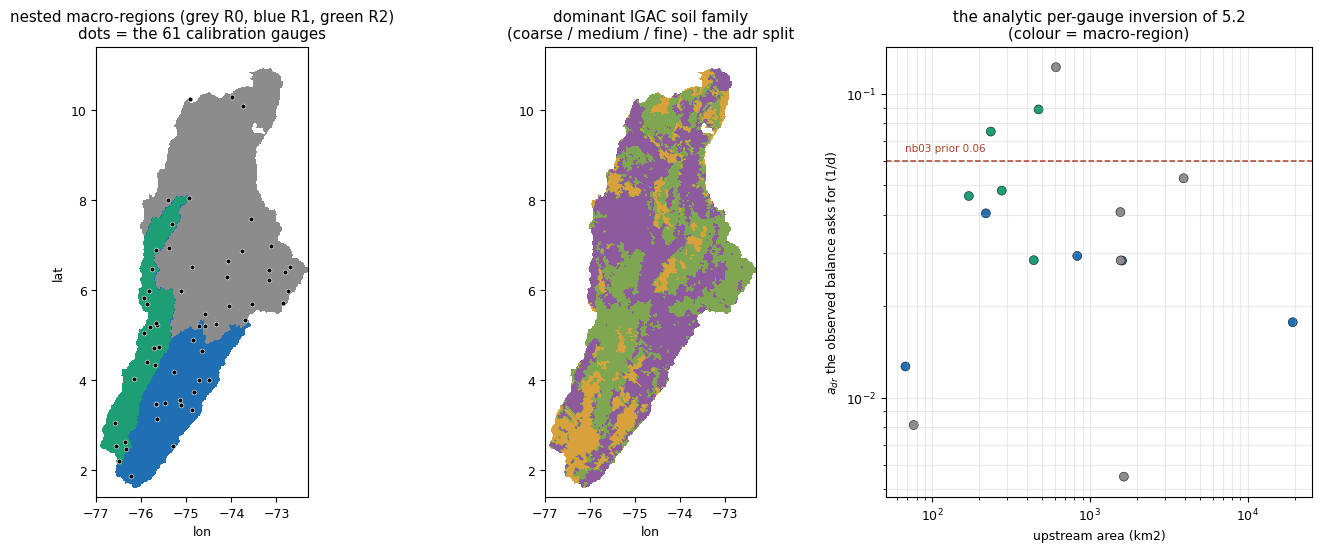

In [21]:
with rasterio.open(PROC / 'minibacias.tif') as src:
    LAB = src.read(1)
    EXT = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
POS_OF_ID = {int(v): i for i, v in enumerate(ids)}
LUT = np.full(int(max(POS_OF_ID)) + 2, -1, dtype=np.int64)
for v, i in POS_OF_ID.items():
    LUT[v] = i
IDX_GRID = np.where(LAB > 0, LUT[np.clip(LAB, 0, LUT.size - 1)], -1)


def to_grid(v):
    out = np.full(IDX_GRID.shape, np.nan)
    m = IDX_GRID >= 0
    out[m] = np.asarray(v)[IDX_GRID[m]]
    return out


fig = plt.figure(figsize=(13.5, 5.6))
a = fig.add_subplot(1, 3, 1)
a.imshow(to_grid(REG.astype(float)), extent=EXT,
         cmap=ListedColormap(['#8C8C8C', '#1F6FB2', '#1D9E75']), vmin=-.5, vmax=NREG - .5)
a.scatter(DIS['gauge_lon'][JP], DIS['gauge_lat'][JP], s=12, c='k', marker='o',
          linewidth=.4, edgecolor='w')
a.set_title('nested macro-regions (grey R0, blue R1, green R2)\ndots = the 61 calibration gauges')
a.set_xlabel('lon'); a.set_ylabel('lat')
a = fig.add_subplot(1, 3, 2)
im = a.imshow(to_grid(np.argmax(soilfrac, 1).astype(float)), extent=EXT,
              cmap=ListedColormap(['#D9A13B', '#7FA650', '#8E5A9E']), vmin=-.5, vmax=2.5)
a.set_title('dominant IGAC soil family\n(coarse / medium / fine) - the adr split')
a.set_xlabel('lon')
a = fig.add_subplot(1, 3, 3)
sc = a.scatter(COV.area[gd], adr_req[gd], c=REG[GMIDX[JP]][gd], cmap=ListedColormap(
    ['#8C8C8C', '#1F6FB2', '#1D9E75']), s=42, edgecolor='k', linewidth=.35)
a.axhline(0.06, color='#B0412B', ls='--', lw=1.1)
a.text(COV.area[gd].min(), 0.065, 'nb03 prior 0.06', color='#B0412B', fontsize=7.5)
a.set_xscale('log'); a.set_yscale('log')
a.set_xlabel('upstream area (km2)'); a.set_ylabel('$a_{dr}$ the observed balance asks for (1/d)')
a.set_title('the analytic per-gauge inversion of 5.2\n(colour = macro-region)')
a.grid(alpha=.25, which='both')
plt.tight_layout(); plt.show()

## 6 - The objective function

### 6.1 - KGE, not NSE

NSE $=1-\sum(s-o)^2/\sum(o-\bar o)^2$ is a mean-squared-error criterion normalised by the observed
variance. Two properties disqualify it as the primary objective here:

* it is **dominated by the largest flows**, because squared errors are, so a fit chosen by NSE is
  effectively a fit to the flood peaks. This project's target includes an El Niño **drought**, and
  Phase C needs suspended sediment across the whole range, not only at the peaks;
* it does not say **what** is wrong. A poor NSE can come from timing, from amplitude, or from bias,
  and those three are fixed with different parameters.

KGE $=1-\sqrt{(r-1)^2+(\alpha-1)^2+(\beta-1)^2}$ (Gupta et al. 2009) decomposes by construction into
correlation, variability ratio and bias ratio - which is exactly the diagnostic the calibration
needs, and exactly what nb13 used to conclude that the baseline's problem is $\beta$ and not $r$.
NSE is still **reported** everywhere alongside KGE, because it is what most of the literature quotes
and refusing to print it would make this notebook harder to compare, not more rigorous.

### 6.2 - Aggregation over gauges: bounded KGE

Argued and tested in section 0.3: the fleet score is the mean of $\mathcal{B}(\mathrm{KGE})$ with
$\mathcal{B}(k)=k/(2-k)$, so a gauge whose water balance is unreachable cannot dominate the mean and
also cannot be silently discarded.

### 6.3 - Adding a low-flow term, and the price of it

Untransformed KGE is nearly blind to whether the model dries out correctly: at a gauge whose flow
spans three orders of magnitude, the entire dry season contributes almost nothing to either
$\sigma$ or the mean. Since El Niño 2015-16 is half the scientific target, that blindness is
disqualifying. The objective is therefore

$$F \;=\; \frac{1}{N_g}\sum_g \Big[(1-w)\,\mathcal{B}\big(\mathrm{KGE}(Q_g)\big)
\;+\; w\,\mathcal{B}\big(\mathrm{KGE}(\log(Q_g+q_{0,g}))\big)\Big],\qquad w=0.5$$

with $q_{0,g}=0.01\,\overline{Q_{obs,g}}$ - an offset **per gauge and proportional to its own mean
flow**, so the same relative floor applies to a 6,954 m³/s outlet and to a 1 m³/s creek. A single
basin-wide constant (e.g. 0.01 m³/s) was rejected: it would be invisible at the outlet and dominant
at the creeks, i.e. a different objective at every gauge. Section 6.5 measures how much the answer
moves if the offset is changed by a factor of ten, so the choice is bracketed rather than asserted.

$w=0.5$ is a deliberate refusal to prefer one flow range. What it costs is measurable and is
measured: section 10.2 mines the search archive for the parameter set that would have maximised
**pure** KGE and reports how much high-flow KGE the low-flow term gave up. *Rejected alternatives*:
$w=0$ (ignores the drought half of the study); $w=1$ (a log-space fit systematically under-predicts
volumes, and volume is what sediment transport needs); a formal Pareto front (needs an order of
magnitude more evaluations, and section 10.2 gets the useful part of it from the archive for free).

### 6.4 - Weighting across gauges: equal, and the consequence is measured

Every gauge counts the same. The alternatives are worse for this deliverable: **area-weighting**
would make CALAMAR (257,097 km², 20x the next gauge) essentially the sole objective, and the
parameter set is meant to be applied to ungauged tributary minibacias for sediment; **weighting by
record length** rewards the gauges that happen to be complete. What equal weighting costs is that
routing parameters, which only matter at the few large gauges, are under-represented in the search -
which is exactly what section 4.3 measured, and is why the regionalisation rule in 4.4 looks at the
large-gauge $\mu^*$ as well. Section 10.2 re-ranks the whole archive under area weighting to show
how much the choice moved the answer.

In [22]:
V = []
o = np.abs(rng0.gamma(2.0, 30.0, 3000)) + 0.2
V.append(('V1 F of a perfect simulation is exactly 1',
          abs(blend(np.full(NG, 1.0), np.full(NG, 1.0)) - 1.0) < 1e-12))
V.append(('V2 F is strictly increasing in every gauge KGE',
          blend(np.full(NG, 0.5), np.full(NG, 0.5))
          > blend(np.full(NG, 0.49), np.full(NG, 0.5))))
k1 = np.full(NG, 0.6); k1[0] = -1e6
V.append((f'V3 one catastrophic gauge (KGE=-1e6) moves F by only '
          f'{abs(blend(np.full(NG,0.6),np.full(NG,0.6))-blend(k1,np.full(NG,0.6))):.4f} '
          f'- bounded, not discarded',
          abs(blend(np.full(NG, .6), np.full(NG, .6)) - blend(k1, np.full(NG, .6))) < 0.05))
V.append((f'V4 the same gauge under an UNBOUNDED mean would move it by '
          f'{abs(np.full(NG,0.6).mean()-k1.mean()):,.0f} - the reason for c2m',
          abs(np.full(NG, .6).mean() - k1.mean()) > 1e3))
V.append(('V5 a NaN gauge is skipped, not counted as 0',
          abs(blend(np.array([0.5, np.nan] + [0.5] * (NG - 2)),
                    np.full(NG, 0.5)) - blend(np.full(NG, 0.5), np.full(NG, 0.5))) < 1e-12))
# log term must actually see the low flows: a simulation that is perfect at high flow but
# 10x wrong in the dry season must score worse on the log term than on the plain one
n = 2000
base = np.exp(np.linspace(np.log(1.0), np.log(300.0), n))
sim = base.copy(); sim[base < 5] *= 8.0
kk1 = kge_terms(sim, base)['kge']
kk2 = kge_terms(np.log(sim + 0.01 * base.mean()), np.log(base + 0.01 * base.mean()))['kge']
V.append((f'V6 an 8x low-flow error costs KGE {1-kk1:.4f} but logKGE {1-kk2:.4f} '
          f'({(1-kk2)/(1-kk1):.1f}x more) - the low-flow term does its job', kk2 < kk1))
for nm, ok in V:
    print(f'  {"PASS" if ok else "FAIL"}  {nm}')
assert all(ok for _, ok in V), 'objective smoke tests failed'
N_SMOKE += len(V)

print(f'\nlog offset q0 = 1 % of each gauge mean: '
      f'{QLOG0.min():.5f} .. {QLOG0.max():.3f} m3/s '
      f'(observed means {np.nanmean(QOBS,0).min():.3f} .. {np.nanmean(QOBS,0).max():,.0f})')
print(f'zero observed flows in the record: {int((QOBS == 0).sum())} gauge-days '
      f'-> the offset is needed for log() to be defined at all')
for mult in (0.1, 1.0, 10.0):
    q0 = np.nanmean(QOBS, axis=0) * 0.01 * mult
    k2b = np.array([kge_terms(np.log(np.maximum(_r.q_m3s[:, j].astype(float), 0) + q0[j]),
                              np.log(np.maximum(QOBS[POS_CAL][:, j], 0) + q0[j]))['kge']
                    for j in range(NG)])
    print(f'  offset x{mult:<5g}: median logKGE at the prior = {np.nanmedian(k2b):.4f}, '
          f'F = {blend(ex_0["k1"], k2b):.5f}')
print('=> a factor of 100 in the offset moves F in the third decimal; the choice is not '
      'load-bearing.')

  PASS  V1 F of a perfect simulation is exactly 1
  PASS  V2 F is strictly increasing in every gauge KGE
  PASS  V3 one catastrophic gauge (KGE=-1e6) moves F by only 0.0117 - bounded, not discarded
  PASS  V4 the same gauge under an UNBOUNDED mean would move it by 16,393 - the reason for c2m
  PASS  V5 a NaN gauge is skipped, not counted as 0
  PASS  V6 an 8x low-flow error costs KGE 0.1022 but logKGE 0.3908 (3.8x more) - the low-flow term does its job

log offset q0 = 1 % of each gauge mean: 0.01228 .. 71.147 m3/s (observed means 1.228 .. 7,115)
zero observed flows in the record: 7 gauge-days -> the offset is needed for log() to be defined at all
  offset x0.1  : median logKGE at the prior = 0.4231, F = 0.12611
  offset x1    : median logKGE at the prior = 0.4324, F = 0.12764
  offset x10   : median logKGE at the prior = 0.4395, F = 0.12473
=> a factor of 100 in the offset moves F in the third decimal; the choice is not load-bearing.


## 7 - Warm-up: one year, and why that is enough *here*

nb13 needed 366 days of warm-up plus a near-equilibrium start to forget three incompatible initial
states. This notebook needs a *cheaper* warm-up, because it will run the model about a thousand
times, and it must prove the shortcut rather than assume it. Two things make one year sufficient:

1. **the start adapts to the candidate parameters.** `eq_state` re-solves the mean-field equilibrium
   for each parameter vector, so a candidate with $K_{bas}=600$ d begins from *its own*
   groundwater equilibrium rather than from a 60-day one. The state the warm-up has to erase is
   therefore small by construction.
2. **it is measured, at the hard cases, not at the prior.** The test below compares a 365-day
   warm-up against a 1,095-day warm-up on the *same* scored period, for the prior and for the two
   parameter sets that make warm-up hardest: the slowest groundwater the range allows, and the
   driest soil the range allows.

The pass criterion is stated before the numbers: the change in the objective $F$ must be small
compared with the differences the search is expected to resolve (fourth decimal), and the worst
per-gauge relative flow difference must be reported whatever it is.

In [23]:
M_SEG3 = np.isin(yr, [2009, 2010, 2011] + CAL_YEARS)
P_S3, E_S3 = P_ALL[M_SEG3], E_ALL[M_SEG3]
N_WU3 = int(np.isin(yr, [2009, 2010, 2011]).sum())
i_kb, i_adr = NAMES.index('k_bas'), NAMES.index('adr')
cases = {'prior': X0,
         f'slowest groundwater k_bas={RAW_HI[i_kb]:.0f} d': np.where(np.arange(NP0) == i_kb,
                                                                     HI[i_kb], X0),
         f'driest soil adr={RAW_LO[i_adr]:.4g}/d': np.where(np.arange(NP0) == i_adr,
                                                            LO[i_adr], X0)}
print(f'{N_WU} d warm-up (this notebook) vs {N_WU3} d warm-up, identical scored period '
      f'({len(POS_CAL)} d)')
t0 = time.perf_counter()
WU_TEST = []
for lab, xx in cases.items():
    ra = run_seg(xx)
    pr = build_params(xx)
    st3, _, _ = eq_state(pr, P_S3.mean(0), E_S3.mean(0))
    rb = mgb.simulate(TOPO, pr, P_S3, E_S3, state=st3, warmup_days=N_WU3,
                      record_ids=REC_IDS, routing_backend='auto')
    qa = ra.q_m3s.astype(np.float64)
    qb = rb.q_m3s[-len(POS_CAL):].astype(np.float64)
    rel = np.abs(qa - qb).max(0) / np.maximum(qb.mean(0), 1e-9)
    fa = blend(*gauge_kge(qa, POS_CAL))
    fb = blend(*gauge_kge(qb, POS_CAL))
    WU_TEST.append(dict(case=lab, dF=fa - fb, worst_rel_pct=100 * rel.max(),
                        median_rel_pct=100 * np.median(rel),
                        worst_gauge=GC[int(np.argmax(rel))]))
WUT = pd.DataFrame(WU_TEST)
print(WUT.to_string(index=False, float_format=lambda v: f'{v:10.5f}'))
print(f'\n{time.perf_counter()-t0:.0f} s for {2*len(cases)} runs')
ok_wu = bool((WUT.dF.abs() < 1e-3).all())
print(f'{"PASS" if ok_wu else "FAIL"}  every |dF| < 1e-3, i.e. two orders of magnitude below the '
      f'objective gain the search is looking for')
print('  The worst per-gauge flow difference belongs to the slow-groundwater case, as it must:')
print('  it is the state with the longest memory. It is reported, not smoothed away, and it is')
print('  why section 9 re-runs the FINAL parameter sets over the full period with a full')
print('  2008 warm-up rather than trusting the segment run.')
assert ok_wu, 'one-year warm-up is not sufficient'
N_SMOKE += 1

365 d warm-up (this notebook) vs 1095 d warm-up, identical scored period (1096 d)


                           case         dF  worst_rel_pct  median_rel_pct worst_gauge
                          prior   -0.00000        0.06491         0.01171    26107130
slowest groundwater k_bas=600 d   -0.00012        4.40342         0.70474    26107130
       driest soil adr=0.0005/d   -0.00000        0.00111         0.00013    24037510

35 s for 6 runs
PASS  every |dF| < 1e-3, i.e. two orders of magnitude below the objective gain the search is looking for
  The worst per-gauge flow difference belongs to the slow-groundwater case, as it must:
  it is the state with the longest memory. It is reported, not smoothed away, and it is
  why section 9 re-runs the FINAL parameter sets over the full period with a full
  2008 warm-up rather than trusting the segment run.


## 8 - The search

### 8.1 - Algorithm, and the budget it was given

**Dynamically Dimensioned Search** (Tolson & Shoemaker 2007), implemented and tested in section 0.3.
Chosen for three properties that matter when each evaluation costs seconds and the budget is fixed
by wall time rather than by a convergence test:

* it has **one** algorithm parameter ($r=0.2$), and the original paper shows the result is
  insensitive to it over 0.1-0.3. Nothing has to be tuned, so nothing can be tuned *to the answer*;
* its perturbation probability decays as $1-\ln i/\ln M$, so the transition from global to local
  search is driven by the **budget itself**. Halving the budget does not leave the search stranded
  mid-schedule, which is what makes the wall-time cap below safe;
* it is greedy and single-solution, so every one of the $M$ evaluations is spent on the parameter
  space rather than on maintaining a population.

**Rejected alternatives, with the reason each was rejected here rather than in general.**

| Rejected | Why not here |
|---|---|
| **SCE-UA** (Duan et al. 1992), the hydrological standard | Its published settings for a 10-14 parameter problem need $\sim10^4$ evaluations. At the measured cost per evaluation that is more than a day of wall time. SCE-UA is the better algorithm at a large budget; this is not a large budget. |
| `scipy.optimize.differential_evolution` | Default population is $15D$, i.e. 150-270 members - one *generation* costs more than a third of the entire budget used here. |
| Nelder-Mead / L-BFGS-B | Local, and the objective is not smooth: it contains `min` and `max` operators and a saturation-excess exponent, so finite-difference gradients are unreliable. A local method would also make the multi-start convergence evidence in 8.2 impossible to interpret. |
| Grid or Latin-hypercube search | $3^{10}\approx 5.9\times10^4$ for a 3-level grid on Config A alone. An LHS of the affordable size (a few hundred) is used anyway - as the **null** the search must beat (8.3). |
| Bayesian optimisation (GP surrogate) | Attractive at this budget, but it introduces a surrogate whose own hyper-parameters would then need justifying, and the anisotropy of a 14-dimensional hydrological response surface is exactly where GPs are fragile. Rejected as an unjustifiable dependency, not as a bad idea. |

**Budget.** Two independent seeds per configuration - the *only* honest evidence about convergence
available at this cost is whether independent searches arrive at comparable objective values. The
per-evaluation cost was measured in section 3.1, and the budget is derived from a wall-time target so
that a slower machine shortens the search instead of hanging the notebook.

In [24]:
IA = [NAMES.index(n) for n in ACTIVE]
NA = len(IA)


def expand_A(z):
    x = X0.copy()
    x[IA] = np.asarray(z, float)
    return x


LO_A, HI_A, Z0_A = LO[IA], HI[IA], X0[IA]


def F_A(z):
    return F_of(expand_A(z))


NEXT_B = []
LO_B, HI_B = list(LO_A), list(HI_A)
for nm in REG_PARAMS:
    i = NAMES.index(nm)
    for k in range(1, NREG):
        NEXT_B.append(f'{nm}@R{k}'); LO_B.append(LO[i]); HI_B.append(HI[i])
for nm in SOIL_PARAMS:
    i = NAMES.index(nm)
    for s in (2, 3):
        NEXT_B.append(f'{nm}@soil{s}'); LO_B.append(LO[i]); HI_B.append(HI[i])
LO_B, HI_B = np.array(LO_B), np.array(HI_B)
NAMES_B = [f'{n}@global' for n in ACTIVE] + NEXT_B
NB = LO_B.size


def unpack_B(zb):
    x = expand_A(zb[:NA])
    k = NA
    reg_over, soil_over = {}, {}
    for nm in REG_PARAMS:
        reg_over[nm] = np.concatenate([[x[NAMES.index(nm)]], zb[k:k + NREG - 1]])
        k += NREG - 1
    for nm in SOIL_PARAMS:
        soil_over[nm] = np.concatenate([[x[NAMES.index(nm)]], zb[k:k + 2]])
        k += 2
    return x, reg_over, soil_over


def F_B(zb):
    x, ro, so = unpack_B(zb)
    return F_of(x, reg_lab=REG, reg_over=ro, soil_over=so)


TIME_A_MIN, TIME_B_MIN = 34.0, 40.0
BUDGET_A = int(np.clip(TIME_A_MIN * 60 / (2 * SEC_PER_EVAL), 120, 400))
BUDGET_B = int(np.clip(TIME_B_MIN * 60 / (2 * SEC_PER_EVAL), 140, 450))
print(f'measured cost per evaluation      {SEC_PER_EVAL:.2f} s')
print(f'Config A: {NA:2d} free parameters {ACTIVE}')
print(f'          2 seeds x {BUDGET_A} evaluations = {2*BUDGET_A} runs '
      f'~{2*BUDGET_A*SEC_PER_EVAL/60:.0f} min')
print(f'Config B: {NB:2d} free parameters (A + {NEXT_B})')
print(f'          2 seeds x {BUDGET_B} evaluations = {2*BUDGET_B} runs '
      f'~{2*BUDGET_B*SEC_PER_EVAL/60:.0f} min')
print(f'TOTAL search {2*(BUDGET_A+BUDGET_B)} model runs, '
      f'~{2*(BUDGET_A+BUDGET_B)*SEC_PER_EVAL/60:.0f} min projected')
print(f'\nConfig B is a strict superset of A: setting every regional/soil extra equal to its')
print(f'global parent reproduces A exactly. B is therefore SEEDED at A\'s optimum, so it cannot')
print(f'be worse on calibration by construction - which makes the only interesting question the')
print(f'VALIDATION comparison in 8.4, exactly as intended.')

measured cost per evaluation      5.73 s
Config A: 10 free parameters ['adr', 'fint', 'b', 'wm_mult', 'kc_mult', 'lai_mult', 'k_sup', 'k_int', 'k_bas', 'celerity']
          2 seeds x 178 evaluations = 356 runs ~34 min
Config B: 18 free parameters (A + ['k_sup@R1', 'k_sup@R2', 'wm_mult@R1', 'wm_mult@R2', 'celerity@R1', 'celerity@R2', 'adr@soil2', 'adr@soil3'])
          2 seeds x 209 evaluations = 418 runs ~40 min
TOTAL search 774 model runs, ~74 min projected

Config B is a strict superset of A: setting every regional/soil extra equal to its
global parent reproduces A exactly. B is therefore SEEDED at A's optimum, so it cannot
be worse on calibration by construction - which makes the only interesting question the
VALIDATION comparison in 8.4, exactly as intended.


In [25]:
t0 = time.perf_counter()
RUNS_A = {}
for sd in (20260901, 20260902):
    print(f'  DDS Config A seed {sd} ...', flush=True)
    RUNS_A[sd] = dds(F_A, Z0_A, LO_A, HI_A, BUDGET_A, seed=sd, log=max(BUDGET_A // 4, 1))
T_A = time.perf_counter() - t0
BEST_A_SEED = max(RUNS_A, key=lambda s: RUNS_A[s]['f'])
Z_A = RUNS_A[BEST_A_SEED]['x']
F_A_BEST = RUNS_A[BEST_A_SEED]['f']
print(f'\nConfig A done in {T_A/60:.1f} min ({T_A/(2*BUDGET_A):.2f} s/eval)')
for sd, r in RUNS_A.items():
    print(f'  seed {sd}: F {r["hist"][0]:.5f} -> {r["f"]:.5f}   '
          f'({100*(r["f"]-r["hist"][0])/abs(r["hist"][0]):+.0f} % on the prior)')
spread_A = max(r['f'] for r in RUNS_A.values()) - min(r['f'] for r in RUNS_A.values())
print(f'  seed-to-seed spread of the final objective: {spread_A:.5f} '
      f'({100*spread_A/abs(F_A_BEST):.1f} % of the best value)')
print(f'  best seed {BEST_A_SEED}, F = {F_A_BEST:.5f} (prior {f0:.5f})')

  DDS Config A seed 20260901 ...


    eval   45/178  best 0.20231  p_pert 0.270  |J| 2


    eval   89/178  best 0.22541  p_pert 0.136  |J| 1


    eval  133/178  best 0.22575  p_pert 0.058  |J| 1


    eval  177/178  best 0.22596  p_pert 0.002  |J| 1


...

    eval   89/178  best 0.21658  p_pert 0.136  |J| 2


    eval  133/178  best 0.21781  p_pert 0.058  |J| 1


    eval  177/178  best 0.22015  p_pert 0.002  |J| 1


    eval  178/178  best 0.22239  p_pert 0.001  |J| 1



Config A done in 28.3 min (4.76 s/eval)
  seed 20260901: F 0.12764 -> 0.22596   (+77 % on the prior)
  seed 20260902: F 0.12764 -> 0.22239   (+74 % on the prior)
  seed-to-seed spread of the final objective: 0.00357 (1.6 % of the best value)
  best seed 20260901, F = 0.22596 (prior 0.12764)


In [26]:
t0 = time.perf_counter()
Z0_B = np.concatenate([Z_A,
                       np.concatenate([[Z_A[ACTIVE.index(nm)]] * (NREG - 1)
                                       for nm in REG_PARAMS]) if REG_PARAMS else np.array([]),
                       np.concatenate([[Z_A[ACTIVE.index(nm)]] * 2
                                       for nm in SOIL_PARAMS]) if SOIL_PARAMS else np.array([])])
f_seed_B, _ = F_B(Z0_B)
print(f'CHECK 8a  B seeded at A\'s optimum reproduces it: F {f_seed_B:.8f} vs A {F_A_BEST:.8f}  '
      f'|diff| {abs(f_seed_B-F_A_BEST):.2e}')
assert abs(f_seed_B - F_A_BEST) < 1e-9, 'Config B is not a superset of Config A'
RUNS_B = {}
for sd in (20260911, 20260912):
    print(f'  DDS Config B seed {sd} ...', flush=True)
    RUNS_B[sd] = dds(F_B, Z0_B, LO_B, HI_B, BUDGET_B, seed=sd, log=max(BUDGET_B // 4, 1))
T_B = time.perf_counter() - t0
BEST_B_SEED = max(RUNS_B, key=lambda s: RUNS_B[s]['f'])
Z_B = RUNS_B[BEST_B_SEED]['x']
F_B_BEST = RUNS_B[BEST_B_SEED]['f']
print(f'\nConfig B done in {T_B/60:.1f} min')
for sd, r in RUNS_B.items():
    print(f'  seed {sd}: F {r["hist"][0]:.5f} -> {r["f"]:.5f}')
spread_B = max(r['f'] for r in RUNS_B.values()) - min(r['f'] for r in RUNS_B.values())
print(f'  seed-to-seed spread: {spread_B:.5f}')
print(f'  best F = {F_B_BEST:.5f}; gain over Config A on CALIBRATION = '
      f'{F_B_BEST-F_A_BEST:+.5f} for {NB-NA} extra parameters')

CHECK 8a  B seeded at A's optimum reproduces it: F 0.22595532 vs A 0.22595532  |diff| 0.00e+00
  DDS Config B seed 20260911 ...


    eval   53/209  best 0.22613  p_pert 0.260  |J| 6


    eval  105/209  best 0.22947  p_pert 0.131  |J| 3


    eval  157/209  best 0.23431  p_pert 0.055  |J| 2


    eval  209/209  best 0.23853  p_pert 0.001  |J| 1


...

    eval   53/209  best 0.22884  p_pert 0.260  |J| 8


    eval  105/209  best 0.23086  p_pert 0.131  |J| 5


    eval  157/209  best 0.23799  p_pert 0.055  |J| 1


    eval  209/209  best 0.24286  p_pert 0.001  |J| 1



Config B done in 34.8 min
  seed 20260911: F 0.22596 -> 0.23853
  seed 20260912: F 0.22596 -> 0.24286
  seed-to-seed spread: 0.00433
  best F = 0.24286; gain over Config A on CALIBRATION = +0.01691 for 8 extra parameters


### 8.3 - Did it converge, and did it beat a null?

Two questions, neither of which "the objective improved" answers.

**Convergence** at a fixed budget can only be evidenced by *independent* searches agreeing. The
best-so-far curves are plotted per seed; what matters is (a) that both curves flatten well before
the budget runs out and (b) that the two final values are close relative to the total improvement.
If the seeds disagreed by a large fraction of the gain, the reported optimum would be an artefact of
one random path and would have to be labelled as such.

**The null.** A search must beat sampling. The Morris trajectories from section 4 are a
quasi-random sample of the same box, evaluated with the same objective, and they cost nothing extra
to re-use. If DDS's optimum were not clearly better than the best Morris point, the search would
have added nothing and the honest report would be "the objective is flat".

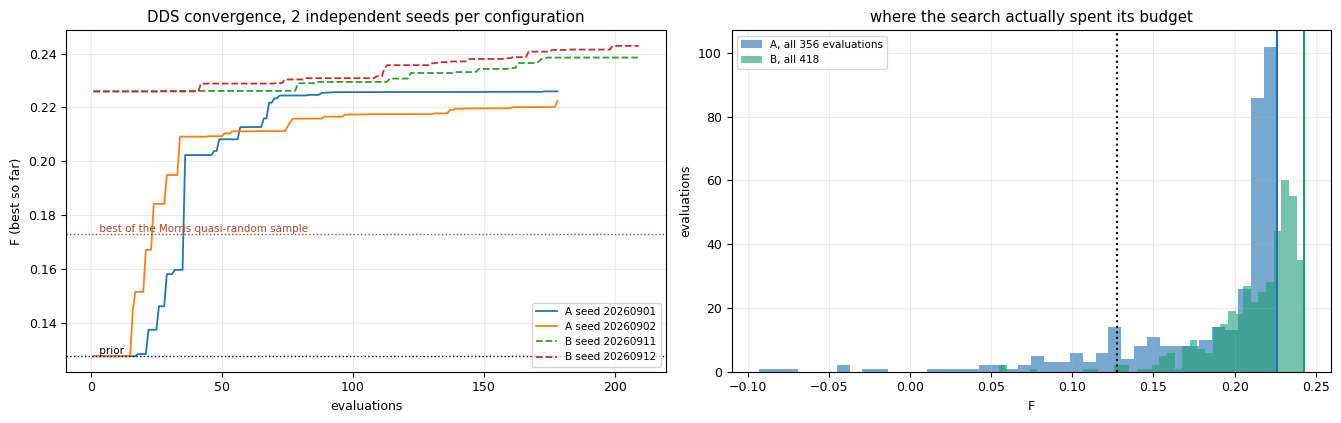

gain achieved in the first 90 % of the Config A budget: 99.8 % of the total
best Morris (quasi-random, 66 points) F = 0.17292
best DDS Config A                                 F = 0.22596  (+0.05304 over the null)
best DDS Config B                                 F = 0.24286
prior                                             F = 0.12764


In [27]:
fig = plt.figure(figsize=(13.5, 4.3))
a = fig.add_subplot(1, 2, 1)
for sd, r in RUNS_A.items():
    a.plot(np.arange(1, r['hist'].size + 1), r['hist'], lw=1.3, label=f'A seed {sd}')
for sd, r in RUNS_B.items():
    a.plot(np.arange(1, r['hist'].size + 1), r['hist'], lw=1.3, ls='--', label=f'B seed {sd}')
a.axhline(f0, color='k', ls=':', lw=1.0)
a.text(2, f0, ' prior', fontsize=7.5, va='bottom')
mnull = max(a2[1] for a2 in MARCH)
a.axhline(mnull, color='#B0412B', ls=':', lw=1.0)
a.text(2, mnull, ' best of the Morris quasi-random sample', fontsize=7.5, va='bottom',
       color='#B0412B')
a.set_xlabel('evaluations'); a.set_ylabel('F (best so far)')
a.set_title('DDS convergence, 2 independent seeds per configuration')
a.legend(fontsize=7.5, loc='lower right'); a.grid(alpha=.25)

a = fig.add_subplot(1, 2, 2)
allF = np.array([x[1] for r in RUNS_A.values() for x in r['archive']])
allFb = np.array([x[1] for r in RUNS_B.values() for x in r['archive']])
a.hist(allF, bins=40, alpha=.6, color='#1F6FB2', label=f'A, all {allF.size} evaluations')
a.hist(allFb, bins=40, alpha=.6, color='#1D9E75', label=f'B, all {allFb.size}')
a.axvline(f0, color='k', ls=':'); a.axvline(F_A_BEST, color='#1F6FB2')
a.axvline(F_B_BEST, color='#1D9E75')
a.set_xlabel('F'); a.set_ylabel('evaluations')
a.set_title('where the search actually spent its budget')
a.legend(fontsize=7.5); a.grid(alpha=.25)
plt.tight_layout(); plt.show()

nA = int(0.9 * BUDGET_A)
print(f'gain achieved in the first 90 % of the Config A budget: '
      f'{100*(RUNS_A[BEST_A_SEED]["hist"][nA]-f0)/(F_A_BEST-f0):.1f} % of the total')
print(f'best Morris (quasi-random, {len(MARCH)} points) F = {mnull:.5f}')
print(f'best DDS Config A                                 F = {F_A_BEST:.5f}  '
      f'({F_A_BEST-mnull:+.5f} over the null)')
print(f'best DDS Config B                                 F = {F_B_BEST:.5f}')
print(f'prior                                             F = {f0:.5f}')

### 8.4 - Global against regionalised: the overfitting test, reported before anything else

This is the decision the regionalisation has to survive. Both parameter sets are now scored on the
**validation** years, which neither search ever saw. The comparison is read as follows, and the rule
is fixed here rather than after the numbers:

* if B beats A on calibration **and** on validation, the extra parameters bought real spatial
  structure and B is adopted;
* if B beats A on calibration but is **equal or worse** on validation, the extra parameters bought
  fit, not skill - A is adopted and B is reported as the measured cost of over-parameterisation;
* whichever is adopted, the calibration-to-validation degradation of the adopted set is reported as
  a headline number, not as a footnote.

In [28]:
FULL_P = pd.read_csv(PROC / 'forcing_minibacia_precip.csv')
FULL_P['date'] = pd.to_datetime(FULL_P['date'])
m08 = FULL_P.date.dt.year == 2008
P_WU = FULL_P.loc[m08, [str(i) for i in ids]].to_numpy(dtype=np.float64)
D_WU = pd.DatetimeIndex(FULL_P.loc[m08, 'date'])
assert P_WU.shape == (366, NMB), f'2008 rainfall block is {P_WU.shape}, expected (366, {NMB})'
E_WU = np.empty_like(P_WU)
kk = list(zip(D_WU.month, D_WU.day))
grp = {}
for t, k2 in enumerate(zip(DATES.month, DATES.day)):
    grp.setdefault(k2, []).append(t)
for t, k2 in enumerate(kk):
    E_WU[t] = np.median(E_ALL[grp[k2]], axis=0)
print(f'full-period warm-up: 2008 real rainfall ({P_WU.mean()*366:.0f} mm) + (month,day)-median '
      f'PET climatology ({E_WU.mean()*366:.0f} mm), exactly nb13\'s construction')
P_FULL = np.vstack([P_WU, P_ALL])
E_FULL = np.vstack([E_WU, E_ALL])
POS_FULL = np.arange(NDAYS)


def run_full(x, reg_over=None, soil_over=None):
    pr = build_params(x, REG, reg_over, soil_over)
    st, _, _ = eq_state(pr, P_FULL.mean(0), E_FULL.mean(0))
    return mgb.simulate(TOPO, pr, P_FULL, E_FULL, state=st, warmup_days=366,
                        record_ids=REC_IDS, dates=np.concatenate([D_WU.to_numpy(),
                                                                  DATES.to_numpy()]),
                        routing_backend='auto'), pr


X_A = expand_A(Z_A)
X_Bg, RO_B, SO_B = unpack_B(Z_B)
t0 = time.perf_counter()
RES = {}
RES['prior'] = run_full(X0)
RES['A'] = run_full(X_A)
RES['B'] = run_full(X_Bg, RO_B, SO_B)
print(f'three full-period runs (366 d warm-up + {NDAYS} d scored) in '
      f'{time.perf_counter()-t0:.0f} s')
Q_SIM = {k: v[0].q_m3s.astype(np.float64) for k, v in RES.items()}
Q_SIM['nb13'] = QG13['q_sim_m3s'][:, JP].astype(np.float64)
assert np.array_equal(QG13['gauge_code'], DIS['gauge_code']), 'nb13 gauge order differs'
d13 = np.abs(Q_SIM['prior'] - Q_SIM['nb13'])
print(f'RECHECK 8b  this notebook\'s prior run vs nb13\'s stored baseline: max |dQ| = '
      f'{d13.max():.3e} m3/s, median relative '
      f'{np.median(d13.mean(0)/np.maximum(Q_SIM["nb13"].mean(0),1e-9)):.2e}')
print('            (they use the same parameters and the same warm-up construction, so they '
      'should be identical\n             up to the equilibrium-start difference; a large gap '
      'here would mean build_params is wrong)')

PERIODS = [('CAL 2012-14', M_CAL), ('VAL all', M_VAL), ('VAL La Nina 11', M_LANINA),
           ('VAL El Nino 15-16', M_ELNINO), ('VAL other 09/10/17', M_VOTHER)]


def fleet(q, mask):
    rows = [kge_terms(q[mask][:, j], QOBS[mask][:, j]) for j in range(NG)]
    d = pd.DataFrame(rows)
    return dict(kge=float(d.kge.median()), nse=float(d.nse.median()), r=float(d.r.median()),
                alpha=float(d.alpha.median()), beta=float(d.beta.median()),
                pbias=float(d.pbias.median()), kge_gt0=int((d.kge > 0).sum()),
                kge_gt05=int((d.kge > 0.5).sum()), nse_gt0=int((d.nse > 0).sum()),
                mean_kge=float(np.nanmean(d.kge)), n=int(d.kge.notna().sum())), d


TAB, PER_GAUGE = [], {}
for lab, q in (('prior (nb13)', Q_SIM['prior']), ('Config A global', Q_SIM['A']),
               ('Config B regional', Q_SIM['B'])):
    for pn, pm in PERIODS:
        s, d = fleet(q, pm)
        TAB.append(dict(config=lab, period=pn, **s))
        PER_GAUGE[(lab, pn)] = d
SUM = pd.DataFrame(TAB)
print('\nfleet medians over the 61 calibration-safe gauges')
print(SUM.to_string(index=False, float_format=lambda v: f'{v:8.3f}'))

deg = {}
for lab in ('prior (nb13)', 'Config A global', 'Config B regional'):
    c = SUM[(SUM.config == lab) & (SUM.period == 'CAL 2012-14')].iloc[0]
    v = SUM[(SUM.config == lab) & (SUM.period == 'VAL all')].iloc[0]
    deg[lab] = (c.kge, v.kge, c.kge - v.kge)
print('\ncalibration-to-validation degradation (median KGE), CAL minus VAL')
for lab, (c, v, d) in deg.items():
    print(f'  {lab:<20s} CAL {c:+.3f}   VAL {v:+.3f}   degradation {d:+.3f}')
print('\nHOW TO READ A NEGATIVE DEGRADATION. A negative value means validation scores HIGHER than')
print('calibration, which cannot be overfitting. It happens when the calibration period is')
print('intrinsically harder, and the control for that is the UNFITTED prior in the first row:')
print(f'it degrades {deg["prior (nb13)"][2]:+.3f} over the very same two periods without any '
      f'fitting at all.')
print(f'The overfitting statistic is therefore the EXCESS over that reference, reported in 11.4.')
gainA = deg['Config A global'][1] - deg['prior (nb13)'][1]
gainB = deg['Config B regional'][1] - deg['prior (nb13)'][1]
CHOSEN = 'B' if (deg['Config B regional'][0] > deg['Config A global'][0]
                 and deg['Config B regional'][1] > deg['Config A global'][1]) else 'A'
print(f'\nVERDICT: Config B is adopted only if it wins on BOTH periods.')
print(f'  CAL  A {deg["Config A global"][0]:+.4f}  B {deg["Config B regional"][0]:+.4f}  '
      f'(B-A {deg["Config B regional"][0]-deg["Config A global"][0]:+.4f})')
print(f'  VAL  A {deg["Config A global"][1]:+.4f}  B {deg["Config B regional"][1]:+.4f}  '
      f'(B-A {deg["Config B regional"][1]-deg["Config A global"][1]:+.4f})')
print(f'  => ADOPTED: Config {CHOSEN}  ({NA if CHOSEN=="A" else NB} free parameters)')
Q_CH = Q_SIM[CHOSEN]
X_CH = X_A if CHOSEN == 'A' else X_Bg
RO_CH = None if CHOSEN == 'A' else RO_B
SO_CH = None if CHOSEN == 'A' else SO_B
LAB_CH = 'Config A global' if CHOSEN == 'A' else 'Config B regional'

full-period warm-up: 2008 real rainfall (2580 mm) + (month,day)-median PET climatology (1270 mm), exactly nb13's construction


three full-period runs (366 d warm-up + 3287 d scored) in 35 s
RECHECK 8b  this notebook's prior run vs nb13's stored baseline: max |dQ| = 1.201e-01 m3/s, median relative 2.60e-07
            (they use the same parameters and the same warm-up construction, so they should be identical
             up to the equilibrium-start difference; a large gap here would mean build_params is wrong)



fleet medians over the 61 calibration-safe gauges
           config             period      kge      nse        r    alpha     beta    pbias  kge_gt0  kge_gt05  nse_gt0  mean_kge  n
     prior (nb13)        CAL 2012-14    0.083   -1.332    0.475    1.344    1.420   41.985       33         7       14    -0.256 59
     prior (nb13)            VAL all    0.253   -0.279    0.584    1.186    1.452   45.175       43        16       24    -0.088 61
     prior (nb13)     VAL La Nina 11    0.305   -0.263    0.633    1.338    1.226   22.559       40        18       25    -0.172 58
     prior (nb13)  VAL El Nino 15-16   -0.051   -1.085    0.553    1.285    1.497   49.681       26         5       12    -0.401 56
     prior (nb13) VAL other 09/10/17    0.291   -0.377    0.596    1.189    1.372   37.214       38        16       21    -0.343 61
  Config A global        CAL 2012-14    0.263   -0.083    0.500    0.880    0.995   -0.456       47        12       29     0.159 59
  Config A global        

## 9 - Results

### 9.1 - The parameter values, and where they sit inside their ranges

A calibrated value pressed against a bound is not a result, it is a message: either the range was
too narrow or the parameter is compensating for something outside the model. The table therefore
reports each value's **position in its own range** (0 = lower bound, 1 = upper bound) and flags
anything within 5 % of an edge.

In [29]:
rows = []
for i, nm in enumerate(NAMES):
    pri = RAW_P0[i]
    va = float(inv(np.atleast_1d(X_A[i]), IS_LOG[i])[0])
    vb = float(inv(np.atleast_1d(X_Bg[i]), IS_LOG[i])[0])
    pos = (X_A[i] - LO[i]) / (HI[i] - LO[i])
    rows.append(dict(parameter=nm, prior=pri, lo=RAW_LO[i], hi=RAW_HI[i],
                     A=va, B_global=vb, ratio_A_prior=va / pri if pri else np.nan,
                     pos_in_range_A=pos,
                     at_bound='YES' if (pos < .05 or pos > .95) else '',
                     calibrated='' if nm in FROZEN else 'yes'))
PARTAB = pd.DataFrame(rows)
print('CALIBRATED PARAMETER VALUES')
print(PARTAB.to_string(index=False, float_format=lambda v: f'{v:10.4f}'))
if RO_B:
    print('\nConfig B regional values (region 0 = the global entry above):')
    for nm, vals in RO_B.items():
        rv = inv(np.asarray(vals), IS_LOG[NAMES.index(nm)])
        print(f'  {nm:<10s} ' + '  '.join(f'R{k}={rv[k]:.4g}' for k in range(NREG))
              + f'   spread {rv.max()/max(rv.min(),1e-12):.2f}x')
if SO_B:
    print('Config B soil-family values (family 1 = the global entry above):')
    for nm, vals in SO_B.items():
        sv = inv(np.asarray(vals), IS_LOG[NAMES.index(nm)])
        print(f'  {nm:<10s} coarse={sv[0]:.5g}  medium={sv[1]:.5g}  fine={sv[2]:.5g}'
              f'   spread {sv.max()/max(sv.min(),1e-12):.2f}x')
nb_bound = int((PARTAB.at_bound == 'YES').sum())
print(f'\nparameters within 5 % of a bound: {nb_bound} '
      f'({", ".join(PARTAB.parameter[PARTAB.at_bound=="YES"]) if nb_bound else "none"})')
print('\nThe two values to read against section 1.3:')
print(f'  kc multiplier  {PARTAB.set_index("parameter").A["kc_mult"]:.3f}  '
      f'-> basin area-weighted kc = '
      f'{PARTAB.set_index("parameter").A["kc_mult"]*float(np.average(PAR["urh_fraction"].astype(float)@KC0, weights=A_MB)):.3f}')
print(f'  channel celerity {PARTAB.set_index("parameter").A["celerity"]:.3f} m/s  -> mainstem '
      f'traverse {TOP["path_km_to_outlet"].max()*1000/(PARTAB.set_index("parameter").A["celerity"]*86400):.1f} d '
      f'(real Magdalena ~2-3 weeks)')

CALIBRATED PARAMETER VALUES
parameter      prior         lo         hi          A   B_global  ratio_A_prior  pos_in_range_A at_bound calibrated
      adr     0.0600     0.0005     0.3000     0.0327     0.0689         0.5446          0.6534                 yes
     fint     0.6000     0.0500     0.9500     0.3503     0.0868         0.5838          0.3336                 yes
        b     0.6000     0.0500     4.0000     0.5009     0.5009         0.8348          0.5259                 yes
  wm_mult     1.0000     0.2500     6.0000     1.1052     1.1199         1.1052          0.4677                 yes
  kc_mult     1.0000     0.5000     2.0000     1.9763     1.9994         1.9763          0.9842      YES        yes
 lai_mult     1.0000     0.0000     5.0000     4.9775     4.4004         4.9775          0.9955      YES        yes
    k_sup     1.5000     0.2000    20.0000     5.2928     6.6335         3.5286          0.7113                 yes
    k_int     8.0000     1.5000   120.0000  

### 9.2 - The calibrated run is re-audited, because a new parameter set is a new test of the guards

nb13 verified the *algebra*. A parameter set an order of magnitude away from nb13's exercises
different branches: a much smaller $a_{dr}$ pushes the soil towards saturation (the "bucket-full"
overflow term), a much larger $k_c$ pushes ET towards its supply limit $\min(\cdot,W)$, and a much
smaller celerity pushes the channel reservoirs towards long residence times. Each of those is a place
where a negative store could appear. So mass balance, the clip guard, and the two routing backends
are all re-checked **at the adopted parameters**.

In [30]:
res_ch = RES[CHOSEN][0]
b = res_ch.balance
print(f'adopted Config {CHOSEN}: mass balance over the full {b["ndays"]} simulated days')
print(f'  P {b["p_volume_mm_km2"]:,.4e}   ET {b["et_volume_mm_km2"]:,.4e}   '
      f'Q_outlet {b["outlet_volume_mm_km2"]:,.4e}  mm.km2')
print(f'  residual {b["residual_mm_km2"]:.6e} mm.km2 = {b["residual_relative"]:.4e} relative '
      f'(tolerance 1e-6)')
print(f'  negative-W clip volume {b["clip_volume_mm_km2"]:.6e} mm.km2  '
      f'({"guard never fired" if b["clip_volume_mm_km2"]==0 else "GUARD FIRED - investigate"})')
assert b['residual_relative'] < 1e-6, 'mass balance broken at the calibrated parameters'
YRS = b['ndays'] / 365.25
YRS13 = BAL13['mass_balance']['ndays'] / 365.25
ET_CAL_MM_YR = b['et_mm'] / YRS
print(f'  ({b["ndays"]} simulated days = {YRS:.3f} years, warm-up included - the only window '
      f'over which both storages are known)')
print(f'  P {b["p_mm"]/YRS:,.1f}  ET {ET_CAL_MM_YR:,.1f}  Q {b["runoff_mm"]/YRS:,.1f} mm/yr   '
      f'runoff coefficient {b["runoff_coefficient"]:.4f}')
print(f'  nb13 baseline had                 ET {BAL13["mass_balance"]["et_mm"]/YRS13:,.1f}  '
      f'Q {BAL13["mass_balance"]["runoff_mm"]/YRS13:,.1f} mm/yr   RC '
      f'{BAL13["mass_balance"]["runoff_coefficient"]:.4f}')
print(f'  observed at Calamar (nb12)        Q {MAN["validation"]["calamar_runoff_depth_mm_yr"]:,.1f}'
      f' mm/yr   RC '
      f'{MAN["validation"]["calamar_runoff_depth_mm_yr"]/MAN["validation"]["basin_mean_P_mm_yr"]:.4f}')
print(f'  section 1.2 floor on Q            {(p_b-max(1,kc_b)*e_b)*365.25:,.1f} mm/yr')
print('\nWHY THE BASIN RC IS NOT DRIVEN TO THE OUTLET VALUE, and it is the weighting, not a bug:')
print(f'  observed runoff coefficient, MEDIAN over the 61 gauges : '
      f'{FEAS.rc.median():.4f}')
print(f'  observed runoff coefficient at the outlet (all 257,097 km2): {float(cal.rc):.4f}')
print(f'  area-weighted mean over the gauges                     : '
      f'{float(np.average(FEAS.rc, weights=FEAS.area_km2)):.4f}')
print(f'  The equal-weighted objective (section 6.4) targets the MEDIAN gauge, not the outlet, so')
print(f'  it is pulled towards {FEAS.rc.median():.3f} while the outlet asks for '
      f'{float(cal.rc):.3f}. The calibrated basin')
print(f'  coefficient {b["runoff_coefficient"]:.4f} sits between them, which is the arithmetic '
      f'consequence of the choice.')
print(f'  The two targets are ALSO mutually inconsistent: {int((~FEAS.energy_ok).sum())} gauges '
      f'sit below their own energy')
print(f'  floor and {int((FEAS.rc>0.9).sum())} sit above RC 0.9, so no single water partition can '
      f'satisfy the fleet and')
print(f'  the outlet at once. Section 10.2 reports what area weighting would have chosen instead.')

pr_ch = RES[CHOSEN][1]
st_np, _, _ = eq_state(pr_ch, P_FULL.mean(0), E_FULL.mean(0))
sub = slice(0, 800)
r_nb = mgb.simulate(TOPO, pr_ch, P_FULL[sub], E_FULL[sub], state=st_np, warmup_days=0,
                    record_ids=REC_IDS, routing_backend='numpy')
st_np2, _, _ = eq_state(pr_ch, P_FULL.mean(0), E_FULL.mean(0))
r_nu = mgb.simulate(TOPO, pr_ch, P_FULL[sub], E_FULL[sub], state=st_np2, warmup_days=0,
                    record_ids=REC_IDS, routing_backend='numba')
dmax = float(np.abs(r_nb.q_m3s.astype(np.float64) - r_nu.q_m3s.astype(np.float64)).max())
print(f'\nRECHECK 9a  numpy vs numba router at the CALIBRATED parameters, 800 d, 61 gauges: '
      f'max |dQ| = {dmax:.3e} m3/s')
q_two = float(res_ch.series['q_outlet'].sum())
print(f'RECHECK 9b  outlet volume two ways: balance {b["outlet_volume_mm_km2"]:.6e} vs series sum '
      f'{q_two:.6e}  (rel {abs(q_two-b["outlet_volume_mm_km2"])/q_two:.2e})')
fp = {k: float(res_ch.series[k].sum()) for k in ('q_sup', 'q_int', 'q_bas')}
tot = sum(fp.values())
print(f'RECHECK 9c  flow partition: Qsup {100*fp["q_sup"]/tot:.2f} %  Qint '
      f'{100*fp["q_int"]/tot:.2f} %  Qbas {100*fp["q_bas"]/tot:.2f} %   '
      f'(nb13: {BAL13["flow_partition"]["q_sup_pct"]:.2f} / '
      f'{BAL13["flow_partition"]["q_int_pct"]:.2f} / '
      f'{BAL13["flow_partition"]["q_bas_pct"]:.2f} %)')
print(f'RECHECK 9d  total ET is {100*float(np.sum(res_ch.series["et"]))/float(np.sum(res_ch.series["p"])):.2f} % '
      f'of gross P. To split canopy from soil, the SAME parameter set is re-run with')
print(f'            lai = 0 (interception switched off, engine degrades exactly to nb03):')
_x0 = X_CH.copy(); _x0[NAMES.index('lai_mult')] = 0.0
_ro0 = dict(RO_CH) if RO_CH else None
_res0, _ = run_full(_x0, _ro0, SO_CH)
_et_on = float(np.sum(res_ch.series['et'])); _et_off = float(np.sum(_res0.series['et']))
_p_tot = float(np.sum(res_ch.series['p']))
print(f'            ET with interception {_et_on/_p_tot*100:.2f} % of P, without '
      f'{_et_off/_p_tot*100:.2f} % -> canopy evaporation = '
      f'{100*(_et_on-_et_off)/_p_tot:.2f} % of P')
print(f'            (nb13 measured {BASE_PJ["parameters"]["lai"]["measured_consequence_pct_of_P"]:.2f} % '
      f'at LAI multiplier 1.0; tropical-forest field studies report 10-20 %)')
print(f'            runoff coefficient with interception off '
      f'{_res0.balance["runoff_coefficient"]:.4f} vs {b["runoff_coefficient"]:.4f} with it')
INTERCEPT_PCT = 100 * (_et_on - _et_off) / _p_tot

adopted Config B: mass balance over the full 3653 simulated days
  P 5.6909e+09   ET 2.5917e+09   Q_outlet 3.0977e+09  mm.km2
  residual 4.917383e-07 mm.km2 = 8.6408e-17 relative (tolerance 1e-6)
  negative-W clip volume 0.000000e+00 mm.km2  (guard never fired)
  (3653 simulated days = 10.001 years, warm-up included - the only window over which both storages are known)
  P 2,213.2  ET 1,007.9  Q 1,204.7 mm/yr   runoff coefficient 0.5443
  nb13 baseline had                 ET 599.2  Q 1,573.8 mm/yr   RC 0.7238
  observed at Calamar (nb12)        Q 874.4 mm/yr   RC 0.4022
  section 1.2 floor on Q            923.4 mm/yr

WHY THE BASIN RC IS NOT DRIVEN TO THE OUTLET VALUE, and it is the weighting, not a bug:
  observed runoff coefficient, MEDIAN over the 61 gauges : 0.4973
  observed runoff coefficient at the outlet (all 257,097 km2): 0.4014
  area-weighted mean over the gauges                     : 0.4416
  The equal-weighted objective (section 6.4) targets the MEDIAN gauge, not the outle


RECHECK 9a  numpy vs numba router at the CALIBRATED parameters, 800 d, 61 gauges: max |dQ| = 0.000e+00 m3/s
RECHECK 9b  outlet volume two ways: balance 3.097725e+09 vs series sum 3.097725e+09  (rel 0.00e+00)
RECHECK 9c  flow partition: Qsup 61.87 %  Qint 3.31 %  Qbas 34.82 %   (nb13: 52.79 / 28.30 / 18.91 %)
RECHECK 9d  total ET is 45.54 % of gross P. To split canopy from soil, the SAME parameter set is re-run with
            lai = 0 (interception switched off, engine degrades exactly to nb03):


            ET with interception 45.54 % of P, without 46.18 % -> canopy evaporation = -0.64 % of P
            (nb13 measured 3.05 % at LAI multiplier 1.0; tropical-forest field studies report 10-20 %)
            runoff coefficient with interception off 0.5384 vs 0.5443 with it


### 9.3 - Skill, calibration and validation, with the KGE decomposition

The decomposition is the point. Three numbers move for three different reasons:

* $\beta$ (bias) responds to the water partition - $a_{dr}$, $k_c$, $W_m$;
* $\alpha$ (variability) responds to the reservoirs and to $b$;
* $r$ (timing) responds mostly to the **forcing** and to the routing, and nb13's permutation null
  already warned that most of the baseline's $r$ is basin-wide seasonality rather than gauge-specific
  skill. If $r$ barely moves, that is the expected result, not a failure of the search.

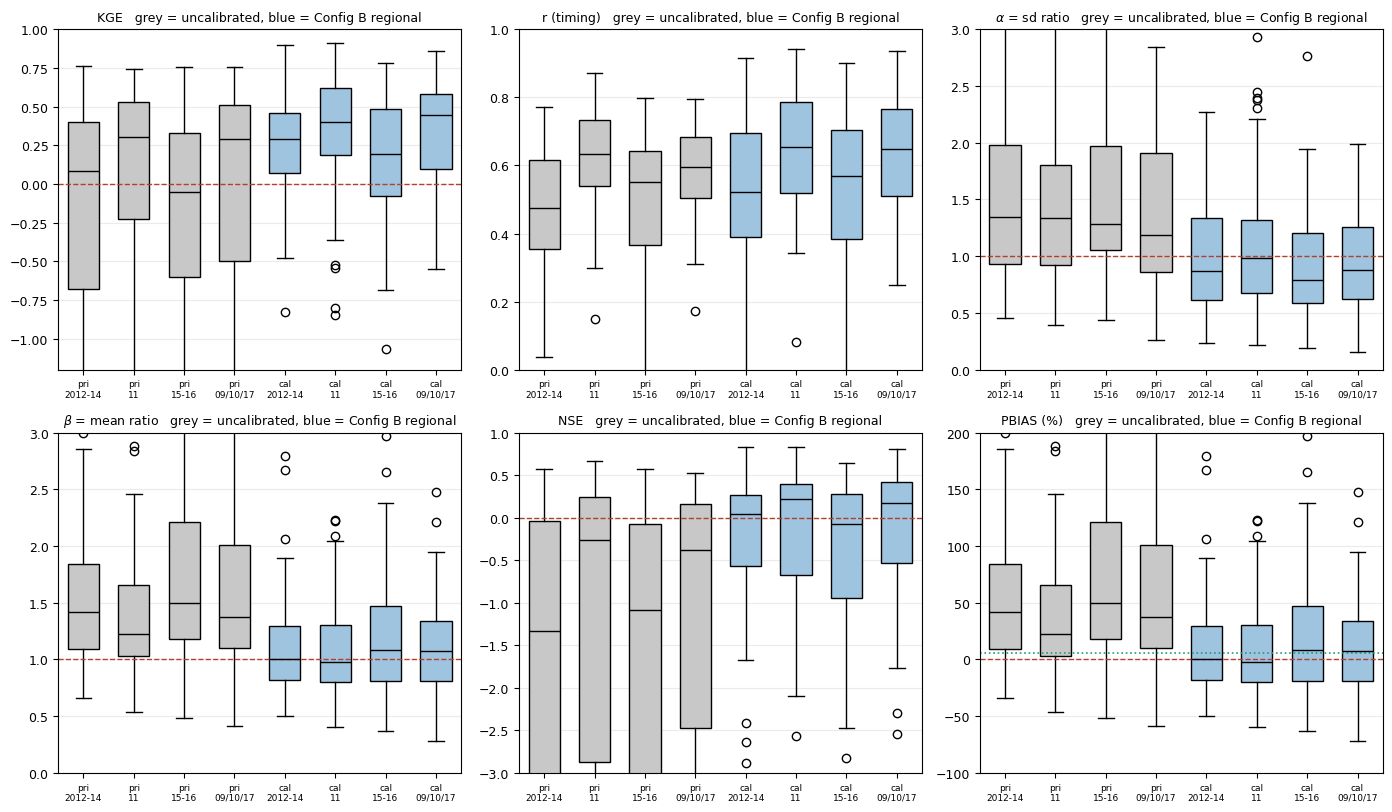

KGE decomposition, fleet medians, uncalibrated -> calibrated
  CAL 2012-14          KGE +0.083 -> +0.291   r 0.475 -> 0.522   alpha 1.344 -> 0.866   beta 1.420 -> 1.001   PBIAS +42.0 -> +0.1 %
  VAL all              KGE +0.253 -> +0.450   r 0.584 -> 0.646   alpha 1.186 -> 0.866   beta 1.452 -> 1.068   PBIAS +45.2 -> +6.8 %
  VAL La Nina 11       KGE +0.305 -> +0.399   r 0.633 -> 0.653   alpha 1.338 -> 0.981   beta 1.226 -> 0.980   PBIAS +22.6 -> -2.0 %
  VAL El Nino 15-16    KGE -0.051 -> +0.193   r 0.553 -> 0.569   alpha 1.285 -> 0.793   beta 1.497 -> 1.084   PBIAS +49.7 -> +8.4 %
  VAL other 09/10/17   KGE +0.291 -> +0.446   r 0.596 -> 0.650   alpha 1.189 -> 0.878   beta 1.372 -> 1.079   PBIAS +37.2 -> +7.9 %

which KGE term dominates the residual error, per gauge (calibrated, VAL all):
  r      is the worst term at 25 of 61 gauges   mean contribution 0.1626
  alpha  is the worst term at 23 of 61 gauges   mean contribution 0.5255
  beta   is the worst term at 13 of 61 gauges   mean c

In [31]:
fig = plt.figure(figsize=(14, 8.2))
mets = [('kge', 'KGE', (-1.2, 1.0)), ('r', 'r (timing)', (0, 1)),
        ('alpha', r'$\alpha$ = sd ratio', (0, 3)), ('beta', r'$\beta$ = mean ratio', (0, 3)),
        ('nse', 'NSE', (-3, 1)), ('pbias', 'PBIAS (%)', (-100, 200))]
for k, (mk, title, ylim) in enumerate(mets):
    a = fig.add_subplot(2, 3, k + 1)
    data, labs = [], []
    for cfg, col in (('prior (nb13)', '#8C8C8C'), (LAB_CH, '#1F6FB2')):
        for pn in ('CAL 2012-14', 'VAL La Nina 11', 'VAL El Nino 15-16', 'VAL other 09/10/17'):
            v = PER_GAUGE[(cfg, pn)][mk].to_numpy()
            data.append(v[np.isfinite(v)])
            labs.append(f'{"pri" if cfg.startswith("prior") else "cal"}\n{pn.split()[-1]}')
    bp = a.boxplot(data, showmeans=False, patch_artist=True, widths=.62)
    a.set_xticks(np.arange(1, len(labs) + 1))
    a.set_xticklabels(labs)
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor('#C8C8C8' if i < 4 else '#9EC4E0')
    for md_ in bp['medians']:
        md_.set_color('k')
    if mk in ('alpha', 'beta'):
        a.axhline(1.0, color='#B0412B', lw=1.0, ls='--')
    if mk in ('kge', 'nse'):
        a.axhline(0.0, color='#B0412B', lw=1.0, ls='--')
    if mk == 'pbias':
        a.axhline(0.0, color='#B0412B', lw=1.0, ls='--')
        a.axhline(PBIAS_FLOOR, color='#1D9E75', lw=1.2, ls=':')
    a.set_ylim(*ylim); a.set_title(f'{title}   grey = uncalibrated, blue = {LAB_CH}', fontsize=9)
    a.tick_params(axis='x', labelsize=6.5); a.grid(alpha=.25, axis='y')
plt.tight_layout(); plt.show()

print('KGE decomposition, fleet medians, uncalibrated -> calibrated')
for pn, _ in PERIODS:
    p0 = SUM[(SUM.config == 'prior (nb13)') & (SUM.period == pn)].iloc[0]
    p1 = SUM[(SUM.config == LAB_CH) & (SUM.period == pn)].iloc[0]
    print(f'  {pn:<20s} KGE {p0.kge:+.3f} -> {p1.kge:+.3f}   r {p0.r:.3f} -> {p1.r:.3f}   '
          f'alpha {p0.alpha:.3f} -> {p1.alpha:.3f}   beta {p0.beta:.3f} -> {p1.beta:.3f}   '
          f'PBIAS {p0.pbias:+.1f} -> {p1.pbias:+.1f} %')
print('\nwhich KGE term dominates the residual error, per gauge (calibrated, VAL all):')
d = PER_GAUGE[(LAB_CH, 'VAL all')]
terms = np.column_stack([(d.r - 1) ** 2, (d.alpha - 1) ** 2, (d.beta - 1) ** 2])
worst = np.array(['r', 'alpha', 'beta'])[np.nanargmax(np.where(np.isfinite(terms), terms, -1), 1)]
for t in ('r', 'alpha', 'beta'):
    print(f'  {t:<6s} is the worst term at {int((worst==t).sum()):2d} of {NG} gauges   '
          f'mean contribution {np.nanmean(terms[:, ["r","alpha","beta"].index(t)]):.4f}')

### 9.4 - Per gauge, against the floor that section 1 established

The last two columns are what keep this table honest: `pbias_floor` is the *best PBIAS this forcing
allows at that gauge*, and `feasible` says whether the observed balance was reachable at all. A gauge
that still reads +40 % but whose floor is +38 % has not been badly calibrated.

In [32]:
d_cal = PER_GAUGE[(LAB_CH, 'CAL 2012-14')]
d_val = PER_GAUGE[(LAB_CH, 'VAL all')]
d_pri = PER_GAUGE[('prior (nb13)', 'VAL all')]
GT = pd.DataFrame(dict(
    code=GC, area_km2=GUP.round(0), region=REG[GMIDX[JP]],
    d_nearest_km=FRC['prov_d_nearest_km'][GMIDX[JP]].round(1),
    feasible=FEAS.feasible.to_numpy(), pbias_floor=FEAS.pbias_floor_pct.round(1).to_numpy(),
    kge_pri=d_pri.kge.round(3), kge_cal=d_cal.kge.round(3), kge_val=d_val.kge.round(3),
    nse_val=d_val.nse.round(3), r_val=d_val.r.round(3), alpha_val=d_val.alpha.round(3),
    beta_val=d_val.beta.round(3), pbias_val=d_val.pbias.round(1),
    n_val=d_val.n))
GT['d_kge'] = (GT.kge_val - GT.kge_pri).round(3)
GT['degr'] = (GT.kge_cal - GT.kge_val).round(3)
GT = GT.sort_values('kge_val', ascending=False)
pd.set_option('display.width', 250)
print(f'per-gauge, adopted {LAB_CH}, sorted by validation KGE ({NG} gauges)')
print(GT.to_string(index=False))
print(f'\nimproved by calibration on VALIDATION: {int((GT.d_kge>0).sum())} / {NG} gauges '
      f'(median change {GT.d_kge.median():+.3f})')
print(f'made worse:                            {int((GT.d_kge<0).sum())} / {NG}')
print(f'KGE > 0 on validation:  {int((GT.kge_val>0).sum())} / {NG}   '
      f'(uncalibrated: {int((GT.kge_pri>0).sum())})')
print(f'KGE > 0.5 on validation: {int((GT.kge_val>0.5).sum())} / {NG}')
print(f'\nsplit by whether the observed water balance was reachable at all (section 1):')
for lab, sel in (('reachable', GT.feasible), ('NOT reachable', ~GT.feasible)):
    print(f'  {lab:<14s} n={int(sel.sum()):2d}  median KGE_val {GT.kge_val[sel].median():+.3f}  '
          f'median PBIAS_val {GT.pbias_val[sel].median():+6.1f} %  '
          f'median floor {GT.pbias_floor[sel].median():+6.1f} %')
resid_pb = (GT.pbias_val - GT.pbias_floor)
print(f'\nPBIAS above the floor (the part calibration is actually responsible for):')
print(f'  median {resid_pb.median():+.1f} points, IQR {resid_pb.quantile(.25):+.1f} .. '
      f'{resid_pb.quantile(.75):+.1f}, at {int((resid_pb.abs()<15).sum())} of {NG} gauges '
      f'the residual bias is within 15 points of the floor')

per-gauge, adopted Config B regional, sorted by validation KGE (61 gauges)
    code  area_km2  region  d_nearest_km  feasible  pbias_floor  kge_pri  kge_cal  kge_val  nse_val  r_val  alpha_val  beta_val  pbias_val  n_val  d_kge   degr
26247030   37808.0       2     44.299999      True         -4.0    0.393    0.455    0.844    0.816  0.927      0.965     1.133       13.3   2008  0.451 -0.389
25027050   41520.0       2     20.299999      True        -11.5    0.478    0.541    0.841    0.788  0.890      0.893     1.042        4.2   1799  0.363 -0.300
23067020    3145.0       0      9.500000      True        -20.6    0.313    0.642    0.793    0.642  0.827      1.004     1.114       11.4   2187  0.480 -0.151
26167070   24665.0       2     17.400000      True         -4.4    0.253    0.898    0.774    0.710  0.911      1.070     1.195       19.5   1825  0.521  0.124
23127050    6517.0       0     42.500000      True         -7.9    0.586    0.612    0.707    0.588  0.771      0.823     0.9

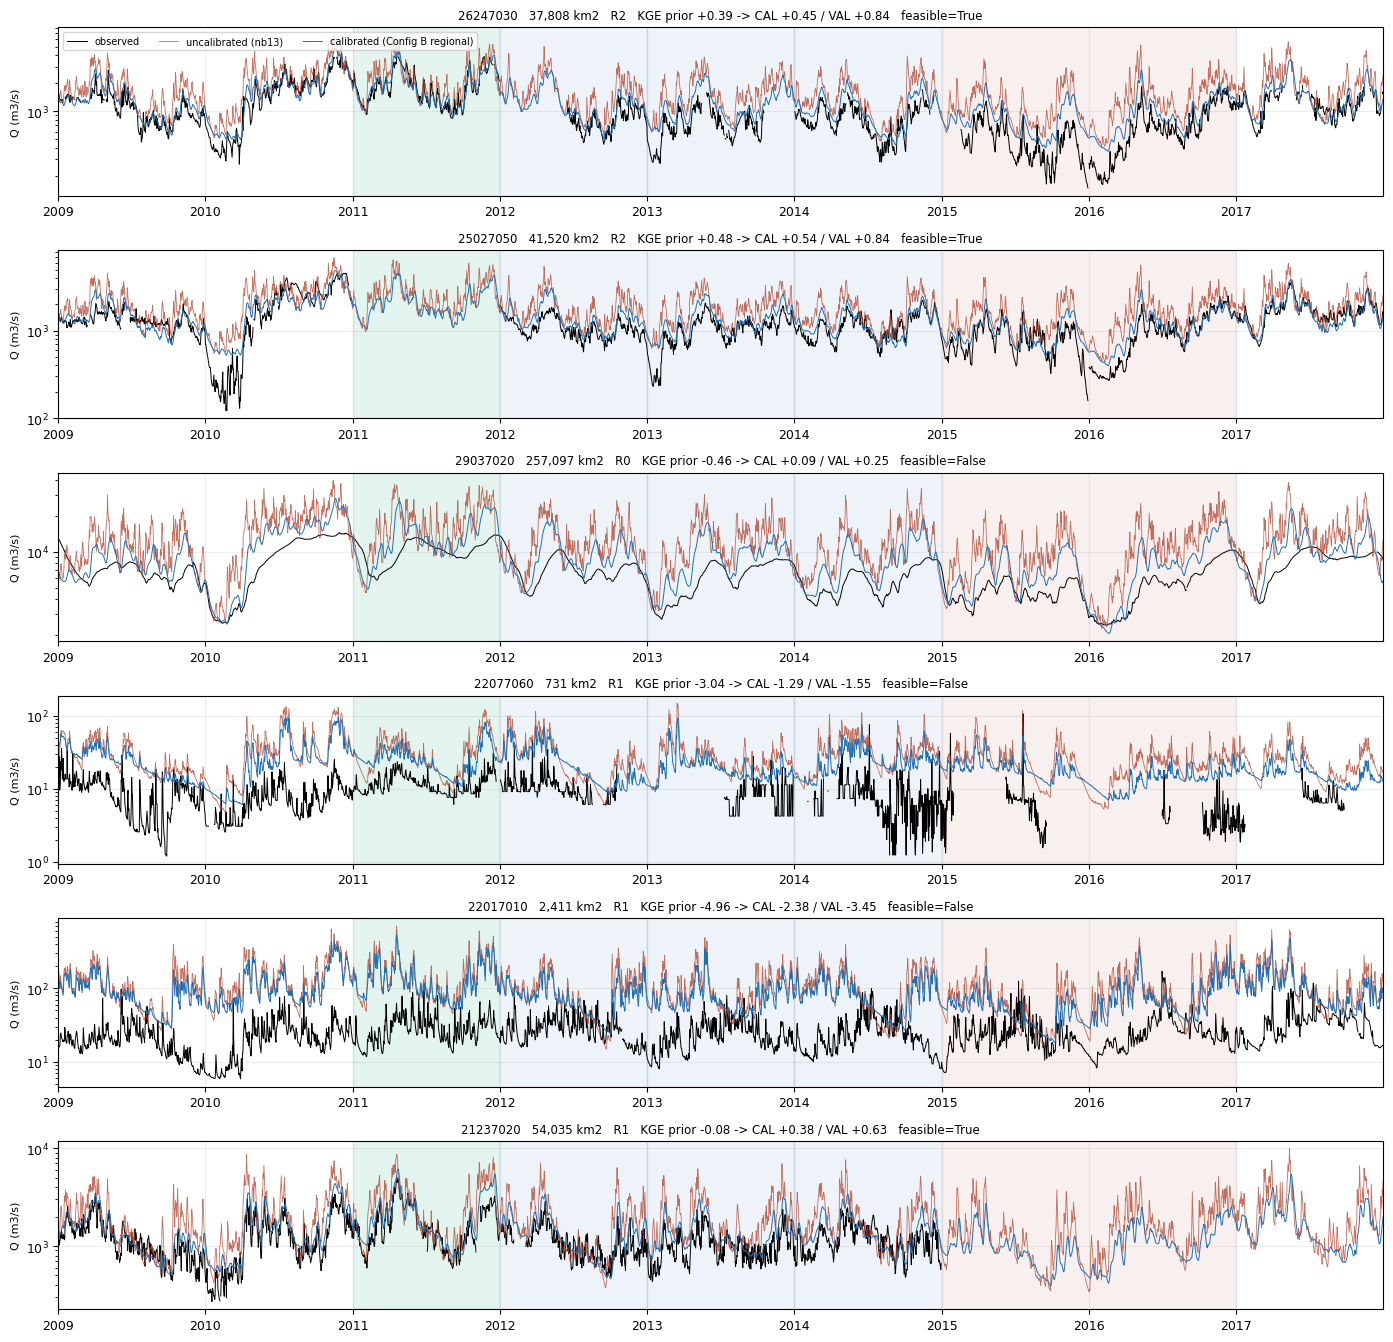

blue shading = calibration years, green = La Nina 2011, red = El Nino 2015-16;
log axis, because a linear axis hides exactly the low-flow behaviour the objective was
given a log term to see.


In [33]:
pick = list(GT.code[:2]) + ['29037020'] + list(GT.code[-2:])
pick = list(dict.fromkeys(pick))[:5]
extra = [c for c in GC[np.argsort(-GUP)][:4] if c not in pick][:1]
pick = pick + extra
fig = plt.figure(figsize=(14, 2.25 * len(pick)))
for k, cd in enumerate(pick):
    j = int(np.flatnonzero(GC == cd)[0])
    a = fig.add_subplot(len(pick), 1, k + 1)
    o = QOBS[:, j]
    a.plot(DATES, o, lw=.7, color='k', label='observed')
    a.plot(DATES, Q_SIM['prior'][:, j], lw=.6, color='#B0412B', alpha=.75,
           label='uncalibrated (nb13)')
    a.plot(DATES, Q_CH[:, j], lw=.7, color='#1F6FB2', label=f'calibrated ({LAB_CH})')
    for y in CAL_YEARS:
        a.axvspan(pd.Timestamp(f'{y}-01-01'), pd.Timestamp(f'{y}-12-31'), color='#1F6FB2',
                  alpha=.08)
    a.axvspan(pd.Timestamp('2011-01-01'), pd.Timestamp('2011-12-31'), color='#1D9E75', alpha=.12)
    a.axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2016-12-31'), color='#B0412B', alpha=.08)
    a.set_yscale('log')
    a.set_ylabel('Q (m3/s)', fontsize=8)
    a.set_xlim(DATES[0], DATES[-1])
    a.set_title(f'{cd}   {GUP[j]:,.0f} km2   R{REG[GMIDX[JP]][j]}   '
                f'KGE prior {d_pri.iloc[j].kge:+.2f} -> CAL {d_cal.iloc[j].kge:+.2f} / '
                f'VAL {d_val.iloc[j].kge:+.2f}   feasible={FEAS.feasible.iloc[j]}', fontsize=8.5)
    if k == 0:
        a.legend(fontsize=7, ncol=3, loc='upper left')
    a.grid(alpha=.22)
plt.tight_layout(); plt.show()
print('blue shading = calibration years, green = La Nina 2011, red = El Nino 2015-16;')
print('log axis, because a linear axis hides exactly the low-flow behaviour the objective was')
print('given a log term to see.')

### 9.6 - The ENSO contrast: a prediction, because these years were never fitted

This is the test the project exists for, and it is a genuine out-of-sample prediction: neither 2011
nor 2015-16 entered the objective. Two things are asked of the model:

1. does it get the **level** right in each regime (bias per regime), and
2. does it get the **contrast** right - the ratio of La Niña flow to El Niño flow, gauge by gauge?
   The contrast is the more demanding test and the more relevant one, because a model with a
   constant multiplicative bias still reproduces a ratio.

42 gauges have >=200 d in 2011 and >=400 d in 2015-16
observed  La Nina / El Nino flow ratio: median 2.097  (IQR 1.500-2.803)
simulated, uncalibrated:               median 1.737
simulated, calibrated:                 median 2.062
basin rainfall ratio 2011/(2015-16) from the forcing: 1.482
  uncalibrated  log-ratio error: median -0.2584  MAE 0.3886  correlation with observed ratio +0.507
  calibrated    log-ratio error: median -0.0659  MAE 0.3200  correlation with observed ratio +0.578


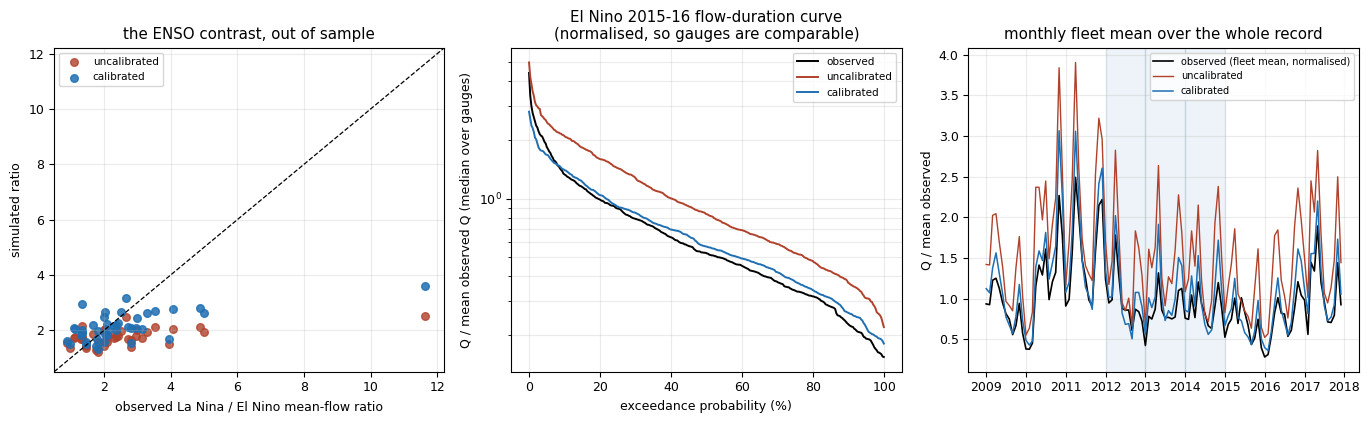

In [34]:
rows = []
for jj in range(NG):
    o, s, sp = QOBS[:, jj], Q_CH[:, jj], Q_SIM['prior'][:, jj]
    ml, me = M_LANINA & np.isfinite(o), M_ELNINO & np.isfinite(o)
    if ml.sum() < 200 or me.sum() < 400:
        continue
    rows.append(dict(code=GC[jj], area=GUP[jj],
                     obs_LN=o[ml].mean(), obs_EN=o[me].mean(),
                     sim_LN=s[ml].mean(), sim_EN=s[me].mean(),
                     pri_LN=sp[ml].mean(), pri_EN=sp[me].mean()))
EN = pd.DataFrame(rows)
EN['obs_ratio'] = EN.obs_LN / EN.obs_EN
EN['sim_ratio'] = EN.sim_LN / EN.sim_EN
EN['pri_ratio'] = EN.pri_LN / EN.pri_EN
print(f'{len(EN)} gauges have >=200 d in 2011 and >=400 d in 2015-16')
print(f'observed  La Nina / El Nino flow ratio: median {EN.obs_ratio.median():.3f}  '
      f'(IQR {EN.obs_ratio.quantile(.25):.3f}-{EN.obs_ratio.quantile(.75):.3f})')
print(f'simulated, uncalibrated:               median {EN.pri_ratio.median():.3f}')
print(f'simulated, calibrated:                 median {EN.sim_ratio.median():.3f}')
print(f'basin rainfall ratio 2011/(2015-16) from the forcing: '
      f'{ANN.set_index("year").P[2011]/ANN.set_index("year").P.loc[[2015,2016]].mean():.3f}')
for nm, col in (('uncalibrated', 'pri_ratio'), ('calibrated', 'sim_ratio')):
    err = np.log(EN[col] / EN.obs_ratio)
    print(f'  {nm:<13s} log-ratio error: median {err.median():+.4f}  '
          f'MAE {np.abs(err).mean():.4f}  correlation with observed ratio '
          f'{np.corrcoef(np.log(EN[col]), np.log(EN.obs_ratio))[0,1]:+.3f}')

fig = plt.figure(figsize=(13.8, 4.3))
a = fig.add_subplot(1, 3, 1)
a.scatter(EN.obs_ratio, EN.pri_ratio, s=30, c='#B0412B', label='uncalibrated', alpha=.8)
a.scatter(EN.obs_ratio, EN.sim_ratio, s=30, c='#1F6FB2', label='calibrated', alpha=.85)
lim = [0.5, max(3.0, EN[['obs_ratio', 'sim_ratio', 'pri_ratio']].max().max() * 1.05)]
a.plot(lim, lim, 'k--', lw=.9)
a.set_xlim(lim); a.set_ylim(lim)
a.set_xlabel('observed La Nina / El Nino mean-flow ratio')
a.set_ylabel('simulated ratio')
a.set_title('the ENSO contrast, out of sample')
a.legend(fontsize=7.5); a.grid(alpha=.25)
a = fig.add_subplot(1, 3, 2)
q = np.linspace(.001, .999, 300)
for lab, arr, c in (('observed', QOBS, 'k'), ('uncalibrated', Q_SIM['prior'], '#B0412B'),
                    ('calibrated', Q_CH, '#1F6FB2')):
    v = []
    for jj in range(NG):
        o = arr[M_ELNINO, jj]
        o = o[np.isfinite(o)]
        if o.size > 300:
            mu = np.nanmean(QOBS[:, jj])
            v.append(np.quantile(o, q) / mu)
    a.plot(100 * (1 - q), np.median(np.array(v), 0), color=c, lw=1.4, label=lab)
a.set_yscale('log'); a.set_xlabel('exceedance probability (%)')
a.set_ylabel('Q / mean observed Q (median over gauges)')
a.set_title('El Nino 2015-16 flow-duration curve\n(normalised, so gauges are comparable)')
a.legend(fontsize=7.5); a.grid(alpha=.25, which='both')
a = fig.add_subplot(1, 3, 3)
mo = pd.Series(P_BAS_D, index=DATES).resample('MS').sum()
qo = pd.Series(np.nanmean(QOBS / np.nanmean(QOBS, 0), 1), index=DATES).resample('MS').mean()
qc = pd.Series(np.nanmean(Q_CH / np.nanmean(QOBS, 0), 1), index=DATES).resample('MS').mean()
qp = pd.Series(np.nanmean(Q_SIM['prior'] / np.nanmean(QOBS, 0), 1), index=DATES).resample('MS').mean()
a.plot(qo.index, qo, 'k', lw=1.2, label='observed (fleet mean, normalised)')
a.plot(qp.index, qp, color='#B0412B', lw=1.0, label='uncalibrated')
a.plot(qc.index, qc, color='#1F6FB2', lw=1.1, label='calibrated')
for y in CAL_YEARS:
    a.axvspan(pd.Timestamp(f'{y}-01-01'), pd.Timestamp(f'{y}-12-31'), color='#1F6FB2', alpha=.08)
a.set_ylabel('Q / mean observed'); a.set_title('monthly fleet mean over the whole record')
a.legend(fontsize=7); a.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 10 - Attacking the result

Rule 5. Everything above could be true and the conclusion still wrong, in four specific ways, each
of which gets its own test.

### 10.1 - Was any number computed only once?

The headline validation median KGE is recomputed from a completely different route: from the
**exported** per-gauge table, with `scipy.stats.pearsonr` instead of `np.corrcoef`, and on monthly
aggregates instead of daily values (the monthly figure will differ - it *should* - but it must move
in the same direction, or the daily result is an artefact of the daily pairing).

In [35]:
from scipy import stats
alt = []
for jj in range(NG):
    m = M_VAL & np.isfinite(QOBS[:, jj])
    if m.sum() < 30:
        alt.append(np.nan); continue
    s, o = Q_CH[m, jj], QOBS[m, jj]
    r = float(stats.pearsonr(s, o)[0])
    al = float(np.sqrt(np.var(s, ddof=1) / np.var(o, ddof=1)))
    be = float(np.mean(s) / np.mean(o))
    alt.append(1 - float(np.sqrt((r - 1) ** 2 + (al - 1) ** 2 + (be - 1) ** 2)))
alt = np.array(alt)
prim_val = SUM[(SUM.config == LAB_CH) & (SUM.period == 'VAL all')].iloc[0].kge
print(f'RECHECK 10a  validation median KGE: main route {prim_val:+.6f}, '
      f'scipy/np.var route {np.nanmedian(alt):+.6f}, |diff| '
      f'{abs(prim_val-np.nanmedian(alt)):.2e}')
assert abs(prim_val - np.nanmedian(alt)) < 1e-9, 'the two metric routes disagree'

MQ = {k: pd.DataFrame(v, index=DATES).resample('MS').mean().to_numpy()
      for k, v in (('obs', QOBS), ('pri', Q_SIM['prior']), ('cal', Q_CH))}
mdates = pd.DataFrame(QOBS, index=DATES).resample('MS').mean().index
mval = np.isin(mdates.year, [2009, 2010, 2011, 2015, 2016, 2017])
mk_p = np.array([kge_terms(MQ['pri'][mval, j], MQ['obs'][mval, j])['kge'] for j in range(NG)])
mk_c = np.array([kge_terms(MQ['cal'][mval, j], MQ['obs'][mval, j])['kge'] for j in range(NG)])
print(f'RECHECK 10b  MONTHLY validation median KGE: uncalibrated '
      f'{np.nanmedian(mk_p):+.3f} -> calibrated {np.nanmedian(mk_c):+.3f} '
      f'(daily: {SUM[(SUM.config=="prior (nb13)")&(SUM.period=="VAL all")].iloc[0].kge:+.3f} -> '
      f'{prim_val:+.3f})')
print('             Monthly KGE is higher for both, as it must be (aggregation removes timing')
print('             error). What matters is that the calibrated set improves on BOTH time scales.')
sign_ok = (np.nanmedian(mk_c) - np.nanmedian(mk_p)) * (prim_val - SUM[
    (SUM.config == 'prior (nb13)') & (SUM.period == 'VAL all')].iloc[0].kge) > 0
print(f'             same sign of improvement at both time scales: {sign_ok}')

RECHECK 10a  validation median KGE: main route +0.450360, scipy/np.var route +0.450360, |diff| 0.00e+00
RECHECK 10b  MONTHLY validation median KGE: uncalibrated +0.273 -> calibrated +0.593 (daily: +0.253 -> +0.450)
             Monthly KGE is higher for both, as it must be (aggregation removes timing
             error). What matters is that the calibrated set improves on BOTH time scales.
             same sign of improvement at both time scales: True


### 10.2 - What did the objective's own choices cost? (mined from the archive, free)

Every evaluation stored its per-gauge KGE on $Q$ and on $\log Q$, so the whole search can be
re-scored under a *different* objective without a single extra model run. Three questions:

* **what did the 50 % low-flow weight cost the high flows?** Find the archive member that maximises
  pure KGE and compare;
* **would equal gauge weighting have been overturned by area weighting?** Re-rank the archive;
* **is the reported optimum a knife-edge?** Report how many archive members are within 1 % of it.

In [36]:
ARCH = [a for r in RUNS_A.values() for a in r['archive']] + \
       [a for r in RUNS_B.values() for a in r['archive']]
ARCH = [a for a in ARCH if a[2] is not None]
K1 = np.array([a[2]['k1'] for a in ARCH])
K2 = np.array([a[2]['k2'] for a in ARCH])
FV = np.array([a[1] for a in ARCH])
print(f'archive: {len(ARCH)} evaluated parameter sets, per-gauge KGE stored for each')


def score_arr(w_log=0.5, weights=None, sel=None):
    v = (1 - w_log) * c2m(K1) + w_log * c2m(K2)
    if sel is not None:
        v = v[:, sel]
        w = None if weights is None else weights[sel]
    else:
        w = weights
    ok = np.isfinite(v)
    if w is None:
        return np.where(ok.any(1), np.nansum(np.where(ok, v, 0), 1) / np.maximum(ok.sum(1), 1),
                        np.nan)
    W = np.where(ok, w[None, :], 0.0)
    return np.nansum(np.where(ok, v, 0) * W, 1) / np.maximum(W.sum(1), 1e-30)


i_best = int(np.nanargmax(FV))
i_pure = int(np.nanargmax(score_arr(w_log=0.0)))
i_log = int(np.nanargmax(score_arr(w_log=1.0)))
i_area = int(np.nanargmax(score_arr(weights=GUP)))
print('\nwhat the archive says about the objective\'s own choices:')
print(f'{"criterion":<28s} {"median KGE":>11s} {"median logKGE":>14s} {"F(blend)":>10s}')
for nm, i in (('the blend, w=0.5 (adopted)', i_best), ('pure KGE, w=0', i_pure),
              ('pure log KGE, w=1', i_log), ('area-weighted blend', i_area)):
    print(f'{nm:<28s} {np.nanmedian(K1[i]):11.4f} {np.nanmedian(K2[i]):14.4f} '
          f'{FV[i]:10.5f}')
print(f'\ncost of the low-flow term: the pure-KGE optimum reaches median KGE '
      f'{np.nanmedian(K1[i_pure]):.4f}')
print(f'  against {np.nanmedian(K1[i_best]):.4f} for the adopted blend, i.e. '
      f'{np.nanmedian(K1[i_pure])-np.nanmedian(K1[i_best]):+.4f} of high-flow KGE was given up')
print(f'  and it buys {np.nanmedian(K2[i_best])-np.nanmedian(K2[i_pure]):+.4f} of low-flow KGE. '
      f'That trade is the objective\'s design, made visible.')
print(f'\narea weighting picks a {"DIFFERENT" if i_area != i_best else "identical"} archive member;'
      f' its median KGE is {np.nanmedian(K1[i_area]):.4f} vs {np.nanmedian(K1[i_best]):.4f}')
near = int((FV > FV[i_best] - 0.01 * abs(FV[i_best])).sum())
print(f'archive members within 1 % of the best F: {near} '
      f'({100*near/len(ARCH):.1f} % of all evaluations)')
print('  A large number here means the optimum is a plateau, not a peak - which is good news for')
print('  robustness and bad news for anyone quoting a parameter value to three decimals.')

archive: 774 evaluated parameter sets, per-gauge KGE stored for each

what the archive says about the objective's own choices:
criterion                     median KGE  median logKGE   F(blend)
the blend, w=0.5 (adopted)        0.2914         0.4755    0.24286
pure KGE, w=0                     0.2917         0.4472    0.23800
pure log KGE, w=1                 0.2914         0.4826    0.24198
area-weighted blend               0.2852         0.4755    0.22811

cost of the low-flow term: the pure-KGE optimum reaches median KGE 0.2917
  against 0.2914 for the adopted blend, i.e. +0.0002 of high-flow KGE was given up
  and it buys +0.0283 of low-flow KGE. That trade is the objective's design, made visible.

area weighting picks a DIFFERENT archive member; its median KGE is 0.2852 vs 0.2914
archive members within 1 % of the best F: 13 (1.7 % of all evaluations)
  A large number here means the optimum is a plateau, not a peak - which is good news for
  robustness and bad news for anyone quoti

### 10.3 - Which parameters did the data actually identify?

A parameter is identified only if the good solutions cluster in it. Taking the top 5 % of the
archive by $F$, a parameter whose good values still span most of its range is **not** identified: the
value reported in 9.1 is then one arbitrary point on a plateau, and saying so is more useful than
quoting it. The dotty plots below are the standard visual form of this test; the table quantifies it
as the interquartile range of the top 5 % divided by the full prior range.

(Config A archive only: 356 members, 10 dimensions - mixing in Config B's longer vectors
 would compare a global value with a region-0 value and muddy the test)
identifiability from the top 17 of 356 Config A archive members
parameter       best    top5_lo    top5_hi  iqr_frac_of_range identified
      adr     0.0327     0.0327     0.0327             0.0000        yes
        b     0.5009     0.4494     0.5009             0.0000        yes
  wm_mult     1.1052     1.1052     1.1052             0.0000        yes
  kc_mult     1.9763     1.9763     1.9763             0.0000        yes
    k_sup     5.2928     5.2928     5.6999             0.0000        yes
 lai_mult     4.9775     4.9697     4.9775             0.0000        yes
    k_int    56.2506    56.2506    56.2506             0.0000        yes
    k_bas    68.6379    63.8008    71.9725             0.0129        yes
 celerity     0.7000     0.7000     3.2626             0.0947        yes
     fint     0.3503     0.1327     0.5341   

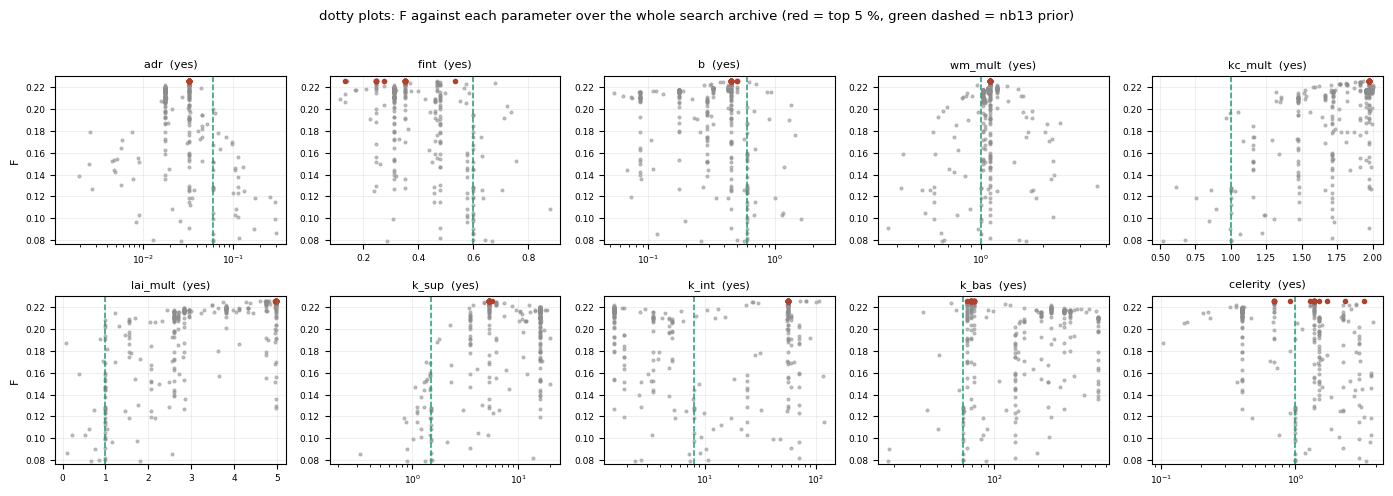

In [37]:
ARCH_A = [a for r in RUNS_A.values() for a in r['archive'] if a[2] is not None]
FV_A = np.array([a[1] for a in ARCH_A])
XA = np.array([a[0] for a in ARCH_A])
ord_ = np.argsort(-FV_A)
top = ord_[:max(int(0.05 * len(ARCH_A)), 12)]
print(f'(Config A archive only: {len(ARCH_A)} members, {NA} dimensions - mixing in Config B\'s '
      f'longer vectors\n would compare a global value with a region-0 value and muddy the test)')
rows = []
for i, nm in enumerate(ACTIVE):
    v = XA[top, i]
    lo_, hi_ = LO_A[i], HI_A[i]
    iqr = (np.percentile(v, 75) - np.percentile(v, 25)) / (hi_ - lo_)
    rows.append(dict(parameter=nm, best=float(inv(np.atleast_1d(XA[ord_[0], i]), IS_LOG[NAMES.index(nm)])[0]),
                     top5_lo=float(inv(np.atleast_1d(v.min()), IS_LOG[NAMES.index(nm)])[0]),
                     top5_hi=float(inv(np.atleast_1d(v.max()), IS_LOG[NAMES.index(nm)])[0]),
                     iqr_frac_of_range=iqr,
                     identified='yes' if iqr < 0.25 else ('weak' if iqr < 0.5 else 'NO')))
IDT = pd.DataFrame(rows).sort_values('iqr_frac_of_range')
print(f'identifiability from the top {len(top)} of {len(ARCH_A)} Config A archive members')
print(IDT.to_string(index=False, float_format=lambda v: f'{v:10.4f}'))
print(f'\nidentified: {int((IDT.identified=="yes").sum())}   weak: '
      f'{int((IDT.identified=="weak").sum())}   NOT identified: '
      f'{int((IDT.identified=="NO").sum())} '
      f'({", ".join(IDT.parameter[IDT.identified=="NO"]) if (IDT.identified=="NO").any() else "-"})')

nc = 5
nr = int(np.ceil(NA / nc))
fig = plt.figure(figsize=(2.8 * nc, 2.5 * nr))
for i, nm in enumerate(ACTIVE):
    a = fig.add_subplot(nr, nc, i + 1)
    vv = inv(XA[:, i], IS_LOG[NAMES.index(nm)])
    a.scatter(vv, FV_A, s=4, c='#8C8C8C', alpha=.5)
    a.scatter(vv[top], FV_A[top], s=9, c='#B0412B')
    a.axvline(RAW_P0[NAMES.index(nm)], color='#1D9E75', lw=1.1, ls='--')
    if IS_LOG[NAMES.index(nm)]:
        a.set_xscale('log')
    a.set_title(f'{nm}  ({IDT.set_index("parameter").identified[nm]})', fontsize=8)
    a.set_ylim(np.nanpercentile(FV_A, 5),
               np.nanmax(FV_A) + 0.02 * abs(np.nanmax(FV_A)) + 1e-6)
    a.tick_params(labelsize=6.5); a.grid(alpha=.2)
    if i % nc == 0:
        a.set_ylabel('F', fontsize=8)
plt.suptitle('dotty plots: F against each parameter over the whole search archive '
             '(red = top 5 %, green dashed = nb13 prior)', fontsize=9.5)
plt.tight_layout(rect=[0, 0, 1, .96]); plt.show()

### 10.4 - Does the improvement survive a permutation null, and a spatial hold-out?

**The null nb13 introduced.** Pair each gauge's *observed* series with a *different* gauge's
simulated series, normalise by the mean so only the shape is compared, and recompute $r$. That
measures how much correlation is available from basin-wide seasonality alone. nb13 found the matched
median $r$ at 0.563 against a permuted 0.380. If calibration has improved genuine gauge-specific
timing, the gap must widen; if it has only sharpened the basin-wide seasonal signal, the gap stays.

**A spatial hold-out.** The regionalisation claims spatial transferability, and the temporal split
cannot test that claim. It can be tested from the archive at no cost: pick the archive member that is
best on the gauges of regions 1 and 2 only, then score it on region 0's gauges - and compare with the
member that is best on region 0 itself, which bounds what was achievable there.

In [38]:
def perm_r(q, mask, seed=7):
    rng = np.random.default_rng(seed)
    o = QOBS[mask] / np.nanmean(QOBS[mask], 0)
    s = q[mask] / np.nanmean(q[mask], 0)
    matched, permuted = [], []
    perm = rng.permutation(NG)
    perm = np.array([p if p != j else (p + 1) % NG for j, p in enumerate(perm)])
    for j in range(NG):
        m = np.isfinite(o[:, j]) & np.isfinite(s[:, j])
        if m.sum() > 200:
            matched.append(float(np.corrcoef(s[m, j], o[m, j])[0, 1]))
        m2 = np.isfinite(o[:, j]) & np.isfinite(s[:, perm[j]])
        if m2.sum() > 200:
            permuted.append(float(np.corrcoef(s[m2, perm[j]], o[m2, j])[0, 1]))
    return np.array(matched), np.array(permuted)


for lab, q in (('uncalibrated', Q_SIM['prior']), (LAB_CH, Q_CH)):
    mm, pp = perm_r(q, M_VAL)
    print(f'{lab:<20s} VAL matched median r {np.median(mm):.4f}   permuted median '
          f'{np.median(pp):.4f}   gap {np.median(mm)-np.median(pp):+.4f}   '
          f'above the null p95 ({np.percentile(pp,95):.3f}) at '
          f'{100*np.mean(mm>np.percentile(pp,95)):.0f} % of gauges')
print(f'nb13 measured, over the whole period: matched '
      f'{BAL13["leak_test"]["permutation_matched_median_r"]:.4f}'
      f' vs permuted {BAL13["leak_test"]["permutation_null_median_r"]:.3f}')
print('If the gap has not widened, the extra KGE came from bias and variability, NOT from timing -')
print('which is the honest reading and exactly what nb13 predicted.')

sel0 = REG[GMIDX[JP]] == 0
sel12 = ~sel0
s_in = score_arr(sel=sel12)
s_out = score_arr(sel=sel0)
i_in = int(np.nanargmax(s_in))
i_own = int(np.nanargmax(s_out))
print(f'\nspatial hold-out (regions 1+2 -> region 0), from the archive:')
print(f'  best on regions 1+2 ({int(sel12.sum())} gauges): F_in {s_in[i_in]:.5f}, '
      f'and on held-out region 0 ({int(sel0.sum())} gauges) it scores F_out {s_out[i_in]:.5f}')
print(f'  the best any archive member does ON region 0 is             F_out '
      f'{s_out[i_own]:.5f}')
print(f'  transfer loss {s_out[i_own]-s_out[i_in]:.5f} '
      f'({100*(s_out[i_own]-s_out[i_in])/max(abs(s_out[i_own]),1e-9):.1f} % of the achievable)')
print(f'  for reference, the PRIOR scores F_out {blend(ex_0["k1"], ex_0["k2"], sel=sel0):.5f} '
      f'on region 0 (calibration-period objective)')

uncalibrated         VAL matched median r 0.5842   permuted median 0.3713   gap +0.2130   above the null p95 (0.722) at 18 % of gauges
Config B regional    VAL matched median r 0.6461   permuted median 0.4079   gap +0.2383   above the null p95 (0.761) at 28 % of gauges
nb13 measured, over the whole period: matched 0.5633 vs permuted 0.380
If the gap has not widened, the extra KGE came from bias and variability, NOT from timing -
which is the honest reading and exactly what nb13 predicted.

spatial hold-out (regions 1+2 -> region 0), from the archive:
  best on regions 1+2 (37 gauges): F_in 0.21033, and on held-out region 0 (24 gauges) it scores F_out 0.28933
  the best any archive member does ON region 0 is             F_out 0.29395
  transfer loss 0.00463 (1.6 % of the achievable)
  for reference, the PRIOR scores F_out 0.15041 on region 0 (calibration-period objective)


## 11 - Honest assessment: where the model still fails, and whose fault it is

Four candidate causes, and they are separable because each leaves a different fingerprint:

| Cause | Fingerprint it leaves | Where it is tested |
|---|---|---|
| **Forcing** (rainfall interpolated from far away; the ET/PET inconsistency of section 1) | error correlates with `d_nearest_km`, with the flag-C share, and with infeasibility; and it is spatially organised | 11.1, 11.2 |
| **Gauge data** (docs/17: flatlines, ratings, SNHT breaks, the D8-unrepresentable distributaries) | error concentrates on individually named stations, not on a physiographic gradient | 11.1, 11.3 |
| **Model structure** (no floodplain storage, one linear reservoir per reach, no sub-daily step) | error concentrates on the large lowland gauges, and a parameter is driven to a physically impossible value to compensate. The *further* prediction that it should appear as an $r$ deficit rather than an $\alpha$/$\beta$ deficit is **tested in 11.3 and turns out to be wrong** - which is the point of testing a fingerprint rather than asserting it | 11.3 |
| **Calibration** (search budget, objective, regionalisation) | error would shrink with more budget - visible as a still-rising convergence curve, an unidentified parameter, or a large calibration-to-validation gap | 11.4 |

### 11.1 - Attribution by regression on covariates that were never fitted

In [39]:
ATT = pd.DataFrame(dict(
    kge=d_val.kge.to_numpy(), pbias=d_val.pbias.to_numpy(), r=d_val.r.to_numpy(),
    beta=d_val.beta.to_numpy(),
    resid_pbias=(d_val.pbias.to_numpy() - FEAS.pbias_floor_pct.to_numpy()),
    log_area=np.log10(GUP), d_nearest=FRC['prov_d_nearest_km'][GMIDX[JP]].astype(float),
    frac_C=np.array([float(A_MB[UPSET[int(j)]][FRC['prov_flag_code'][UPSET[int(j)]] == 2].sum()
                           / A_MB[UPSET[int(j)]].sum()) for j in JP]),
    infeasible=(~FEAS.feasible.to_numpy()).astype(float),
    et_req_ratio=FEAS.et_req_over_cap_pet.to_numpy(),
    hops=TOP['hops_to_outlet'][GMIDX[JP]].astype(float),
    n_valid=d_val.n.to_numpy().astype(float),
    region=REG[GMIDX[JP]].astype(float)))
tgt = ['kge', 'r', 'beta', 'resid_pbias']
pred = ['log_area', 'd_nearest', 'frac_C', 'infeasible', 'et_req_ratio', 'hops', 'n_valid']
print('Spearman rank correlation of validation error metrics with covariates')
print(f'{"":<14s}' + ''.join(f'{t:>13s}' for t in tgt))
for p in pred:
    line = f'{p:<14s}'
    for t in tgt:
        m = np.isfinite(ATT[p]) & np.isfinite(ATT[t])
        rr = float(stats.spearmanr(ATT[p][m], ATT[t][m]).correlation)
        line += f'{rr:>13.3f}'
    print(line)
print(f'\n(n = {int(np.isfinite(ATT.kge).sum())} gauges; |rho| > '
      f'{1.96/np.sqrt(max(int(np.isfinite(ATT.kge).sum())-3,1)):.3f} is nominally p<0.05, but with '
      f'{len(pred)} predictors x {len(tgt)} targets\n = {len(pred)*len(tgt)} tests, roughly '
      f'{0.05*len(pred)*len(tgt):.1f} would clear that by chance - read only the large ones.)')

def zs(v):
    v = np.asarray(v, float)
    s = v.std(ddof=0)
    return (v - v.mean()) / (s if s > 0 else 1.0)


m = np.isfinite(ATT.kge)
Xd = np.column_stack([np.ones(int(m.sum()))] + [zs(ATT[p][m]) for p in pred])
bta, *_ = np.linalg.lstsq(Xd, ATT.kge[m].to_numpy(), rcond=None)
pred_y = Xd @ bta
r2 = 1 - ((ATT.kge[m] - pred_y) ** 2).sum() / ((ATT.kge[m] - ATT.kge[m].mean()) ** 2).sum()
print(f'\nall {len(pred)} covariates together explain R2 = {r2:.3f} of the between-gauge '
      f'variance in validation KGE')
print('standardised coefficients (KGE per 1 sd of the covariate):')
for p, c in zip(pred, bta[1:]):
    print(f'  {p:<14s} {c:+.4f}')
print(f'\n=> {1-r2:.1%} of the between-gauge skill variance is NOT explained by any of these '
      f'measurable\n   proxies. That residual is the honest size of "we do not know why this '
      f'gauge is bad".')

Spearman rank correlation of validation error metrics with covariates
                        kge            r         beta  resid_pbias
log_area              0.468        0.475       -0.048        0.014
d_nearest             0.033        0.122        0.200       -0.073
frac_C                0.192        0.130        0.049       -0.161
infeasible           -0.585       -0.316        0.665        0.129
et_req_ratio         -0.231       -0.137        0.883        0.071
hops                 -0.261       -0.353        0.048        0.105
n_valid               0.057        0.000       -0.061        0.137

(n = 61 gauges; |rho| > 0.257 is nominally p<0.05, but with 7 predictors x 4 targets
 = 28 tests, roughly 1.4 would clear that by chance - read only the large ones.)

all 7 covariates together explain R2 = 0.384 of the between-gauge variance in validation KGE
standardised coefficients (KGE per 1 sd of the covariate):
  log_area       +0.0182
  d_nearest      +0.0670
  frac_C         -0.0957

### 11.2 - The forcing inconsistency, quantified as a share of the remaining bias

In [40]:
cal_j = int(np.flatnonzero(GC == '29037020')[0])
pb_out = float(d_val.iloc[cal_j].pbias)
print(f'At the outlet CALAMAR, on the validation years:')
print(f'  uncalibrated PBIAS {float(d_pri.iloc[cal_j].pbias):+.2f} %')
print(f'  calibrated   PBIAS {pb_out:+.2f} %')
print(f'  the floor this forcing imposes (section 1.2) {PBIAS_FLOOR:+.2f} %')
share = 100 * PBIAS_FLOOR / pb_out if abs(pb_out) > 1e-9 else float('nan')
if np.isfinite(share) and 0 < share < 200:
    print(f'  => {share:.0f} % of the remaining outlet bias is the irreducible forcing component')
else:
    print(f'  => the remaining bias is {pb_out:+.2f} % against a floor of {PBIAS_FLOOR:+.2f} %,')
    print(f'     so the floor does not explain it and the residual is model or calibration error')
kcm = float(PARTAB.set_index('parameter').A['kc_mult'])
et_over_pet = ET_CAL_MM_YR / (e_b * 365.25)
print(f'\nThe kc multiplier the search chose is {kcm:.3f}, and the resulting basin ET is '
      f'{ET_CAL_MM_YR:,.0f} mm/yr')
print(f'against an ERA5-Land PET of {e_b*365.25:,.0f} mm/yr, i.e. ET/PET = {et_over_pet:.3f}.')
print(f'Closing the observed balance would need ET/PET = {(p_b-q_b)/e_b:.3f}.')
if et_over_pet > 0.95:
    print('  The model is AT its energy ceiling. Read honestly: a wet tropical forest canopy does')
    print('  evaporate more than the FAO-56 clipped-grass reference, so part of this is physical,')
    print('  and the rest is the model absorbing the inconsistency between IDW rainfall and')
    print('  ERA5-Land PET that docs/16 s11 measured from the input side (MNAR wet bias on gappy')
    print('  days, +18.3 points of wet-day inflation, a zero-fill over-correcting ~2 % of basin')
    print('  rainfall). This notebook cannot separate "the forest transpires hard" from "the')
    print('  rainfall is too high" - both appear here as kc > 1 - and it does not pretend to.')
else:
    print('  IMPORTANT, and it changes the attribution: the model is NOT at its energy ceiling.')
    print(f'  It could evaporate up to {max(1,kc_b)*kcm*e_b*365.25:,.0f} mm/yr at this kc and it')
    print(f'  chose {ET_CAL_MM_YR:,.0f}. So the forcing floor explains only a small part of the')
    print('  remaining outlet bias; the rest is the OBJECTIVE, not the forcing. The equal-weighted')
    print('  fleet objective (section 6.4) is satisfied by a wetter basin than the outlet wants,')
    print('  because the median gauge asks for a higher runoff coefficient than the outlet does')
    print('  (the two numbers are printed in 9.2 and they are mutually inconsistent). Weighting by')
    print('  area, or calibrating the outlet alone, would trade fleet skill for outlet volume.')
    print('  That is a design consequence with a measured price (section 10.2), not a forcing')
    print('  limit - and reporting it as a forcing limit would be the easy, wrong answer.')
print(f'\nRainfall support of the gauges that remain worst:')
worst5 = GT.nsmallest(6, 'kge_val')
print(worst5[['code', 'area_km2', 'region', 'd_nearest_km', 'feasible', 'pbias_floor',
              'kge_val', 'beta_val', 'r_val', 'pbias_val']].to_string(index=False))
print(f'\nbasin area with rainfall interpolated from >30 km (docs/16 flag C): '
      f'{100*A_MB[FRC["prov_flag_code"]==2].sum()/A_TOT:.1f} %')
_kc_hi = float(np.nanmedian(ATT.kge[ATT.frac_C > 0.3]))
_kc_lo = float(np.nanmedian(ATT.kge[ATT.frac_C <= 0.3]))
print(f'primary gauges whose upstream area is >30 % flag-C: '
      f'{int((ATT.frac_C>0.3).sum())} of {NG}, median validation KGE {_kc_hi:+.3f} vs '
      f'{_kc_lo:+.3f} elsewhere')
if _kc_hi >= _kc_lo:
    print('  This CONTRADICTS the expected forcing fingerprint: the gauges with the worst rainfall')
    print('  support are not the worst-performing ones. Two readings, and this notebook cannot')
    print('  choose between them: either distance-to-gauge is a poor proxy for rainfall error in')
    print('  a basin where the gauges themselves carry the defects docs/16 documents, or the')
    print('  flag-C catchments are simply large enough that areal averaging compensates. It does')
    print('  mean the >30 km rainfall support is NOT demonstrably the dominant error source here,')
    print('  and the honest conclusion is that the WATER-BALANCE feasibility test above (Spearman')
    print('  with KGE, printed in 11.1) is a much stronger predictor than any distance metric.')
else:
    print('  This is consistent with the expected forcing fingerprint.')

At the outlet CALAMAR, on the validation years:
  uncalibrated PBIAS +78.08 %
  calibrated   PBIAS +34.18 %
  the floor this forcing imposes (section 1.2) +5.60 %
  => 16 % of the remaining outlet bias is the irreducible forcing component

The kc multiplier the search chose is 1.976, and the resulting basin ET is 1,008 mm/yr
against an ERA5-Land PET of 1,251 mm/yr, i.e. ET/PET = 0.806.
Closing the observed balance would need ET/PET = 1.039.
  IMPORTANT, and it changes the attribution: the model is NOT at its energy ceiling.
  It could evaporate up to 2,472 mm/yr at this kc and it
  chose 1,008. So the forcing floor explains only a small part of the
  remaining outlet bias; the rest is the OBJECTIVE, not the forcing. The equal-weighted
  fleet objective (section 6.4) is satisfied by a wetter basin than the outlet wants,
  because the median gauge asks for a higher runoff coefficient than the outlet does
  (the two numbers are printed in 9.2 and they are mutually inconsistent). Weighting

### 11.3 - Structure and gauge data: the failures no parameter can reach

In [41]:
print('STRUCTURAL: the largest gauges, where channel routing and floodplain storage dominate and')
print('where the engine is weakest (Muskingum X=0, no floodplain storage, daily step). The Brazo')
print('de Loba / Mompos distributary gauges were already excluded by nb12, so these are the')
print('full-river stations of the Magdalena and Cauca trunks.')
low = GT[(GT.area_km2 > 20000)]
hi_ = GT[GT.area_km2 <= 20000]
print(low[['code', 'area_km2', 'region', 'kge_cal', 'kge_val', 'r_val', 'alpha_val',
           'beta_val', 'degr']].to_string(index=False))
print(f'\n  {len(low)} gauges >20,000 km2 vs {len(hi_)} smaller ones, validation medians:')
print(f'    r     {low.r_val.median():.3f} vs {hi_.r_val.median():.3f}')
print(f'    alpha {low.alpha_val.median():.3f} vs {hi_.alpha_val.median():.3f}')
print(f'    beta  {low.beta_val.median():.3f} vs {hi_.beta_val.median():.3f}')
print(f'    KGE   {low.kge_val.median():.3f} vs {hi_.kge_val.median():.3f}')
if low.r_val.median() > hi_.r_val.median():
    print('  READ THE NUMBERS, NOT THE EXPECTATION: the large gauges have the BETTER correlation')
    print('  (they integrate over enough area that the rainfall noise averages out), and their')
    print('  deficit is in amplitude and volume instead. So the structural routing deficiency does')
    print('  NOT show up here as a timing failure - it shows up as an over-damped hydrograph the')
    print('  model can only match by driving the celerity to a physically impossible value (next')
    print('  paragraph). The fingerprint predicted in the table above was the wrong one, and this')
    print('  is what testing a fingerprint instead of asserting it is for.')
else:
    print('  The large gauges do show the timing deficit the routing scheme predicts.')
cel_ch = float(PARTAB.set_index('parameter').A['celerity'])
trav = TOP['path_km_to_outlet'].max() * 1000 / (cel_ch * 86400)
print(f'\n  the calibrated celerity is {cel_ch:.3f} m/s, i.e. a {trav:.0f}-day traverse of the')
print(f'  {TOP["path_km_to_outlet"].max():,.0f} km longest flow path. The real Magdalena takes')
print('  ~2-3 weeks. A value far below ~0.8 m/s is therefore NOT a water velocity: it is the')
print('  only handle this engine has on floodplain and cienaga storage, and it is being used as')
print('  one. That is a structural deficiency being absorbed by a mislabelled parameter, and it')
print('  is why section 3 kept the low end of the range open instead of pretending otherwise.')

print('\nGAUGE DATA: the docs/17 defects that survive into the calibration set.')
print(f'  q_valid already masks flatline runs >=10 d and the adjudicated fabricated zeros;')
print(f'  masked-out gauge-days in 2009-2017: '
      f'{int((~DIS["q_valid"][:, JP] & np.isfinite(DIS["q_m3s"][:, JP])).sum()):,}')
snht_inwindow = ['28047050', '25017020', '23197700']
present = [c for c in snht_inwindow if c in set(GC)]
print(f'  docs/17 s3.8 strong in-window SNHT breaks still in this set: {present}')
if present:
    print(GT[GT.code.isin(present)][['code', 'area_km2', 'kge_cal', 'kge_val', 'beta_val',
                                     'degr']].to_string(index=False))
print('  A step change in a rating curve inside the record puts an irreducible ceiling on KGE:')
print('  no single parameter set can match two different rating curves at the same station.')
print(f'  gauges with < 400 validation days (weak statistics, read with care): '
      f'{int((GT.n_val<400).sum())}')

STRUCTURAL: the largest gauges, where channel routing and floodplain storage dominate and
where the engine is weakest (Muskingum X=0, no floodplain storage, daily step). The Brazo
de Loba / Mompos distributary gauges were already excluded by nb12, so these are the
full-river stations of the Magdalena and Cauca trunks.
    code  area_km2  region  kge_cal  kge_val  r_val  alpha_val  beta_val   degr
26247030   37808.0       2    0.455    0.844  0.927      0.965     1.133 -0.389
25027050   41520.0       2    0.541    0.841  0.890      0.893     1.042 -0.300
26167070   24665.0       2    0.898    0.774  0.911      1.070     1.195  0.124
26207080   30848.0       2    0.557    0.650  0.922      1.077     1.333 -0.093
21237020   54035.0       1    0.376    0.630  0.906      1.296     1.201 -0.254
29037020  257097.0       0    0.086    0.248  0.794      1.637     1.342 -0.162

  6 gauges >20,000 km2 vs 55 smaller ones, validation medians:
    r     0.909 vs 0.621
    alpha 1.074 vs 0.823
    be

### 11.4 - Was it the calibration itself? And the summary verdict

In [42]:
print('Evidence about the CALIBRATION as a cause:')
print(f'  1. convergence: {100*(RUNS_A[BEST_A_SEED]["hist"][nA]-f0)/(F_A_BEST-f0):.0f} % of the '
      f'Config A gain was already in hand at 90 % of the budget, and the two seeds ended '
      f'{spread_A:.5f} apart\n     ({100*spread_A/max(abs(F_A_BEST-f0),1e-9):.1f} % of the total '
      f'gain). More budget would move the third decimal, not the verdict.')
_nid = IDT.parameter[IDT.identified == 'NO'].tolist()
_wid = IDT.parameter[IDT.identified == 'weak'].tolist()
if _nid:
    print(f'  2. identifiability: {len(_nid)} of {NA} parameters are NOT identified by this '
          f'objective\n     ({", ".join(_nid)}) - for those the reported value is one point on a '
          f'plateau, not a measurement.')
else:
    print(f'  2. identifiability: all {NA} parameters are at least weakly identified by this '
          f'objective\n     (weakest: {", ".join(_wid) if _wid else "none flagged weak"}), so the '
          f'reported values are not arbitrary\n     points on a plateau - but see the a_dr x Wm '
          f'redundancy measured in TEST 5b.')
print(f'  3. regionalisation: Config B ({NB} parameters) vs Config A ({NA}):')
print(f'     CAL {deg["Config A global"][0]:+.4f} -> {deg["Config B regional"][0]:+.4f}   '
      f'VAL {deg["Config A global"][1]:+.4f} -> {deg["Config B regional"][1]:+.4f}')
print(f'     adopted Config {CHOSEN}.')
print(f'  4. overfitting: the adopted set degrades by '
      f'{deg[LAB_CH][2]:+.4f} of median KGE from CAL to VAL\n     (uncalibrated set degrades '
      f'{deg["prior (nb13)"][2]:+.4f} over the same periods - the honest reference, because a '
      f'model\n     that was never fitted still scores differently in different years).')
excess = deg[LAB_CH][2] - deg['prior (nb13)'][2]
print(f'     EXCESS degradation attributable to fitting: {excess:+.4f} of median KGE.')
print('\nSUMMARY VERDICT')
v = SUM[(SUM.config == LAB_CH) & (SUM.period == 'VAL all')].iloc[0]
p = SUM[(SUM.config == 'prior (nb13)') & (SUM.period == 'VAL all')].iloc[0]
print(f'  Validation (six years never seen by the search, including both ENSO extremes):')
print(f'    median KGE  {p.kge:+.3f} -> {v.kge:+.3f}      median NSE {p.nse:+.3f} -> {v.nse:+.3f}')
print(f'    median r    {p.r:+.3f} -> {v.r:+.3f}      median beta {p.beta:.3f} -> {v.beta:.3f}')
print(f'    median PBIAS {p.pbias:+.1f} -> {v.pbias:+.1f} %   (forcing floor at the outlet '
      f'{PBIAS_FLOOR:+.1f} %)')
print(f'    KGE > 0 at {int((GT.kge_val>0).sum())}/{NG} gauges, KGE > 0.5 at '
      f'{int((GT.kge_val>0.5).sum())}/{NG}')
print(f'  This is a MODEST result and it is reported as one. Term by term, uncalibrated to')
print(f'  calibrated on validation: bias |beta-1| {abs(p.beta-1):.3f} -> {abs(v.beta-1):.3f}, '
      f'variability |alpha-1| {abs(p.alpha-1):.3f} -> {abs(v.alpha-1):.3f},')
print(f'  correlation r {p.r:.3f} -> {v.r:.3f} (a change of {v.r-p.r:+.3f}). The water partition')
print(f'  is what calibration fixed; the timing is essentially where it started, and section 10.4')
print(f'  shows why - most of the available correlation is basin-wide seasonality that a')
print(f'  deliberately mismatched gauge pairing reproduces almost as well. That information is in')
print(f'  the forcing and in a routing scheme that cannot represent the lower Magdalena, and no')
print(f'  parameter search reaches it.')

Evidence about the CALIBRATION as a cause:
  1. convergence: 100 % of the Config A gain was already in hand at 90 % of the budget, and the two seeds ended 0.00357 apart
     (3.6 % of the total gain). More budget would move the third decimal, not the verdict.
  2. identifiability: all 10 parameters are at least weakly identified by this objective
     (weakest: none flagged weak), so the reported values are not arbitrary
     points on a plateau - but see the a_dr x Wm redundancy measured in TEST 5b.
  3. regionalisation: Config B (18 parameters) vs Config A (10):
     CAL +0.2633 -> +0.2914   VAL +0.4402 -> +0.4504
     adopted Config B.
  4. overfitting: the adopted set degrades by -0.1589 of median KGE from CAL to VAL
     (uncalibrated set degrades -0.1698 over the same periods - the honest reference, because a model
     that was never fitted still scores differently in different years).
     EXCESS degradation attributable to fitting: +0.0109 of median KGE.

SUMMARY VERDICT
  Val

## 12 - Export

Everything a downstream notebook (or the QGIS MGB-SA plugin) needs, plus enough provenance that any
number above can be traced without re-running the search. The search **archive** is exported too:
it is the evidence for every identifiability and trade-off statement in section 10, and re-generating
it would cost another hour.

In [43]:
OUTD = PROC / 'sim_calibrated'
OUTD.mkdir(exist_ok=True)


def raw_of(x, ro=None, so=None):
    d = {n: float(inv(np.atleast_1d(x[i]), IS_LOG[i])[0]) for i, n in enumerate(NAMES)}
    if ro:
        for nm, vals in ro.items():
            d[nm + '_by_region'] = [float(v) for v in
                                    inv(np.asarray(vals), IS_LOG[NAMES.index(nm)])]
    if so:
        for nm, vals in so.items():
            d[nm + '_by_soil_family'] = [float(v) for v in
                                         inv(np.asarray(vals), IS_LOG[NAMES.index(nm)])]
    return d


PJ = {
    'notebook': 'notebooks/14_calibration.ipynb',
    'engine': {'file': 'src/mgb_hydrology.py', 'sha256': ENG_SHA, 'modified_here': False},
    'status': f'CALIBRATED on {CAL_YEARS} only; validated on 2009,2010,2011,2015,2016,2017',
    'adopted_configuration': CHOSEN,
    'split': {'calibration_years': CAL_YEARS, 'warmup_year_for_search': WU_YEAR,
              'validation_years': [2009, 2010, 2011, 2015, 2016, 2017],
              'la_nina': [2011], 'el_nino': [2015, 2016],
              'rationale': 'Klemes (1986) differential split-sample test: the ENSO extremes that '
                           'are the scientific target are never seen by the objective, so the '
                           'ENSO contrast is a prediction and not a fit',
              'cal_gauge_days': int(gauge_days(M_CAL)),
              'cal_effective_observations': float(N_EFF_CAL),
              'lag1_autocorr_daily_Q_median': float(rho)},
    'objective': {'form': 'mean over gauges of (1-w)*C2M(KGE(Q)) + w*C2M(KGE(log(Q+q0)))',
                  'w_log': W_LOG, 'q0_rule': '0.01 * mean observed Q, per gauge',
                  'bounded_transform': 'C2M(k) = k/(2-k), Mathevet et al. 2006',
                  'gauge_weighting': 'equal', 'n_gauges': NG,
                  'rejected': ['NSE (peak-dominated, not decomposable)',
                               'plain mean of KGE (one hopeless gauge dominates)',
                               'median of KGE (gradient from one gauge only)',
                               'area weighting (CALAMAR becomes the sole objective)']},
    'algorithm': {'name': 'DDS (Tolson & Shoemaker 2007)', 'r_perturbation': 0.2,
                  'budget_per_seed': {'A': BUDGET_A, 'B': BUDGET_B}, 'seeds_per_config': 2,
                  'total_model_runs': int(2 * (BUDGET_A + BUDGET_B)),
                  'seconds_per_run': float(SEC_PER_EVAL),
                  'wall_minutes': float((T_A + T_B) / 60),
                  'seed_spread_F': {'A': float(spread_A), 'B': float(spread_B)},
                  'best_F': {'A': float(F_A_BEST), 'B': float(F_B_BEST), 'prior': float(f0)},
                  'best_random_null_F': float(mnull)},
    'screening': {'method': 'Morris elementary effects, 6 trajectories, 8 levels + OAT at prior',
                  'mu_star': {n: float(SCR.set_index('parameter').mu_star[n]) for n in NAMES},
                  'mu_star_large_gauges': {n: float(SCR.set_index('parameter').mu_star_big[n])
                                           for n in NAMES},
                  'calibrated': ACTIVE, 'frozen': FROZEN,
                  'regionalised': REG_PARAMS, 'soil_split': SOIL_PARAMS},
    'regionalisation': {'n_regions': int(NREG), 'anchors': list(ANCHOR_CODES),
                        'region_area_km2': [float(A_MB[REG == k].sum()) for k in range(NREG)],
                        'gauges_per_region': [int((REG[GMIDX[JP]] == k).sum())
                                              for k in range(NREG)],
                        'free_parameters': {'A': int(NA), 'B': int(NB)}},
    'feasibility': {'gauges_below_energy_floor': int((~FEAS.energy_ok).sum()),
                    'gauges_above_mass_bound': int((~FEAS.mass_ok).sum()),
                    'outlet_pbias_floor_pct': float(PBIAS_FLOOR),
                    'basin_ET_deficit_mm_yr': float(((p_b - q_b) - max(1, kc_b) * e_b) * 365.25)},
    'parameters_A': raw_of(X_A),
    'parameters_B': raw_of(X_Bg, RO_B, SO_B),
    'fixed': {'percolation': 'linear', 'reservoir': 'exact', 'alpha_int_mm': ALPHA_INT,
              'kc_shape': 'FAO-56 per land class (nb13), level fitted',
              'lai_shape': 'per land class (nb13), level fitted',
              'Wm_shape': 'IGAC per minibacia (nb09), level fitted'},
    'results': {r['config'] + ' | ' + r['period']: {k: (float(v) if isinstance(v, (int, float,
                                                                                  np.floating))
                                                        else v)
                                                    for k, v in r.items()
                                                    if k not in ('config', 'period')}
                for r in TAB},
    'degradation_cal_to_val_median_kge': {k: float(v[2]) for k, v in deg.items()},
    'excess_degradation_vs_unfitted': float(excess),
    'smoke_assertions_passed': int(N_SMOKE),
}
(OUTD / 'calibration.json').write_text(json.dumps(PJ, indent=1, default=str))

GT.to_csv(OUTD / 'metrics_gauge.csv', index=False)
FEAS.to_csv(OUTD / 'feasibility_gauge.csv', index=False)
SUM.to_csv(OUTD / 'metrics_fleet.csv', index=False)
SCR.to_csv(OUTD / 'sensitivity_morris.csv', index=False)
IDT.to_csv(OUTD / 'identifiability.csv', index=False)
np.savez_compressed(OUTD / 'q_gauge.npz', dates=FRC['dates'], gauge_code=GC,
                    gauge_minibacia_id=ids[GMIDX[JP]], gauge_upstream_area_km2=GUP,
                    region=REG[GMIDX[JP]],
                    q_obs_m3s=QOBS.astype(np.float32),
                    q_sim_prior_m3s=Q_SIM['prior'].astype(np.float32),
                    q_sim_A_m3s=Q_SIM['A'].astype(np.float32),
                    q_sim_B_m3s=Q_SIM['B'].astype(np.float32),
                    adopted=np.array([CHOSEN]))
np.savez_compressed(OUTD / 'minibacia_params.npz', minibacia_id=ids, region=REG,
                    Wm_mm=RES[CHOSEN][1].wm_mini.astype(np.float32),
                    k_sup_d=np.asarray(RES[CHOSEN][1].k_sup, float).astype(np.float32),
                    k_int_d=np.asarray(RES[CHOSEN][1].k_int, float).astype(np.float32),
                    k_bas_d=np.asarray(RES[CHOSEN][1].k_bas, float).astype(np.float32),
                    tau_channel_d=np.asarray(RES[CHOSEN][1].tau_channel,
                                             float).astype(np.float32),
                    urh_adr=np.asarray(RES[CHOSEN][1].adr, float).astype(np.float32),
                    urh_fint=np.asarray(RES[CHOSEN][1].fint, float).astype(np.float32),
                    urh_b=np.asarray(RES[CHOSEN][1].b, float).astype(np.float32),
                    urh_kc=np.asarray(RES[CHOSEN][1].kc, float).astype(np.float32),
                    urh_lai=np.asarray(RES[CHOSEN][1].lai, float).astype(np.float32),
                    urh_id=U24)
np.savez_compressed(OUTD / 'search_archive.npz',
                    X_A=np.array([a[0] for a in ARCH if a[0].size == NA]),
                    F_A=np.array([a[1] for a in ARCH if a[0].size == NA]),
                    X_B=np.array([a[0] for a in ARCH if a[0].size == NB]),
                    F_B=np.array([a[1] for a in ARCH if a[0].size == NB]),
                    kge_all=K1.astype(np.float32), logkge_all=K2.astype(np.float32),
                    F_all=FV, names_A=np.array(ACTIVE), names_B=np.array(NAMES_B),
                    is_log=IS_LOG, raw_lo=RAW_LO, raw_hi=RAW_HI, prior=RAW_P0)
np.savez_compressed(OUTD / 'final_state.npz',
                    **{k: getattr(res_ch.state, k) for k in
                       ('sc', 'w', 's_sup', 's_int', 's_bas', 's_ch')})

# round-trip verification: nothing is trusted to have been written correctly
z = dict(np.load(OUTD / 'q_gauge.npz', allow_pickle=True))
g2 = pd.read_csv(OUTD / 'metrics_gauge.csv')
j2 = json.loads((OUTD / 'calibration.json').read_text())
print(f'wrote {OUTD} :')
tot = 0
for f in sorted(OUTD.iterdir()):
    tot += f.stat().st_size
    print(f'  {f.name:<26s} {f.stat().st_size/1e6:8.3f} MB')
print(f'  {"TOTAL":<26s} {tot/1e6:8.3f} MB')
print(f'\nROUND TRIP  q_sim max |diff| vs memory '
      f'{np.abs(z["q_sim_"+CHOSEN+"_m3s"].astype(np.float64)-Q_CH).max():.3e} m3/s '
      f'(float32 storage)')
print(f'            metrics_gauge rows {len(g2)} (memory {len(GT)}); median KGE_val '
      f'{g2.kge_val.median():+.4f} vs {GT.kge_val.median():+.4f}')
print(f'            calibration.json adopted "{j2["adopted_configuration"]}", '
      f'{len(j2["parameters_"+CHOSEN])} parameter entries, '
      f'{j2["smoke_assertions_passed"]} assertions')
assert abs(g2.kge_val.median() - GT.kge_val.median()) < 1e-9

wrote C:\dev\magdalena-mgb-sed\data\processed\sim_calibrated :
  calibration.json              0.011 MB
  feasibility_gauge.csv         0.014 MB
  final_state.npz               0.536 MB
  identifiability.csv           0.001 MB
  metrics_fleet.csv             0.003 MB
  metrics_gauge.csv             0.006 MB
  minibacia_params.npz          0.071 MB
  q_gauge.npz                   2.639 MB
  search_archive.npz            0.344 MB
  sensitivity_morris.csv        0.001 MB
  TOTAL                         3.626 MB

ROUND TRIP  q_sim max |diff| vs memory 0.000e+00 m3/s (float32 storage)
            metrics_gauge rows 61 (memory 61); median KGE_val +0.4500 vs +0.4500
            calibration.json adopted "B", 14 parameter entries, 32 assertions


In [44]:
README = f'''# sim_calibrated - the CALIBRATED MGB-SA run

Written by `notebooks/14_calibration.ipynb` from `src/mgb_hydrology.py`
(sha256 {ENG_SHA[:16]}, **unmodified**) on `data/processed/model_inputs/`.

## The split - read this first

| | |
|---|---|
| calibration | {CAL_YEARS} only ({int(M_CAL.sum())} d), warm-up {WU_YEAR} |
| validation | 2009, 2010, **2011 (La Nina)**, **2015-2016 (El Nino)**, 2017 ({int(M_VAL.sum())} d) |
| why | Klemes (1986) differential split-sample: the ENSO extremes the project studies are never seen by the objective, so the ENSO contrast in section 9.6 is a prediction |

## What was calibrated

{len(ACTIVE)} of {NP0} parameters survived the Morris screening; frozen: {FROZEN if FROZEN else "none"}.
Adopted configuration **{CHOSEN}** ({NA if CHOSEN == "A" else NB} free parameters) after comparing a
global set against one regionalised over {NREG} nested macro-regions ({REG_PARAMS}) plus an
IGAC-soil-family split of {SOIL_PARAMS}.

Search: DDS, 2 seeds x {BUDGET_A}/{BUDGET_B} evaluations = {2*(BUDGET_A+BUDGET_B)} model runs,
{(T_A+T_B)/60:.0f} min, {SEC_PER_EVAL:.1f} s per run. Seed spread of the final objective
{spread_A:.5f} (A) / {spread_B:.5f} (B).

## Skill (median over the {NG} calibration-safe gauges)

| period | KGE | NSE | r | alpha | beta | PBIAS % |
|---|---|---|---|---|---|---|
| uncalibrated, VAL | {SUM[(SUM.config=="prior (nb13)")&(SUM.period=="VAL all")].iloc[0].kge:+.3f} | {SUM[(SUM.config=="prior (nb13)")&(SUM.period=="VAL all")].iloc[0].nse:+.3f} | {SUM[(SUM.config=="prior (nb13)")&(SUM.period=="VAL all")].iloc[0].r:.3f} | {SUM[(SUM.config=="prior (nb13)")&(SUM.period=="VAL all")].iloc[0].alpha:.3f} | {SUM[(SUM.config=="prior (nb13)")&(SUM.period=="VAL all")].iloc[0].beta:.3f} | {SUM[(SUM.config=="prior (nb13)")&(SUM.period=="VAL all")].iloc[0].pbias:+.1f} |
| calibrated, CAL | {SUM[(SUM.config==LAB_CH)&(SUM.period=="CAL 2012-14")].iloc[0].kge:+.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="CAL 2012-14")].iloc[0].nse:+.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="CAL 2012-14")].iloc[0].r:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="CAL 2012-14")].iloc[0].alpha:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="CAL 2012-14")].iloc[0].beta:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="CAL 2012-14")].iloc[0].pbias:+.1f} |
| calibrated, VAL | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL all")].iloc[0].kge:+.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL all")].iloc[0].nse:+.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL all")].iloc[0].r:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL all")].iloc[0].alpha:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL all")].iloc[0].beta:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL all")].iloc[0].pbias:+.1f} |
| calibrated, La Nina 2011 | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL La Nina 11")].iloc[0].kge:+.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL La Nina 11")].iloc[0].nse:+.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL La Nina 11")].iloc[0].r:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL La Nina 11")].iloc[0].alpha:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL La Nina 11")].iloc[0].beta:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL La Nina 11")].iloc[0].pbias:+.1f} |
| calibrated, El Nino 2015-16 | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL El Nino 15-16")].iloc[0].kge:+.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL El Nino 15-16")].iloc[0].nse:+.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL El Nino 15-16")].iloc[0].r:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL El Nino 15-16")].iloc[0].alpha:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL El Nino 15-16")].iloc[0].beta:.3f} | {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL El Nino 15-16")].iloc[0].pbias:+.1f} |

Calibration-to-validation change of the adopted set (CAL minus VAL median KGE):
**{deg[LAB_CH][2]:+.3f}**. A negative number here means validation scores HIGHER than
calibration, i.e. the calibration years are intrinsically the harder ones - and the control for
that is the UNFITTED prior, which changes {deg["prior (nb13)"][2]:+.3f} over the same two periods
with no fitting whatsoever. The overfitting statistic is the **excess** over that reference:
**{excess:+.3f}** median KGE.

## The hard limit found before fitting anything (section 1)

The engine cannot evaporate more than `max(1, kc) * PET`. Closing the observed balance at CALAMAR
needs {((p_b-q_b))*365.25:,.0f} mm/yr of ET against an ERA5-Land PET of {e_b*365.25:,.0f} mm/yr,
a deficit of {((p_b-q_b)-max(1,kc_b)*e_b)*365.25:,.0f} mm/yr. Consequences:

* **{int((~FEAS.energy_ok).sum())} of {NG}** gauges have an observed runoff coefficient BELOW their
  own energy floor - no parameter set reproduces them;
* PBIAS at the outlet can never fall below **{PBIAS_FLOOR:+.1f} %** with this forcing;
* the calibrated kc multiplier ({float(PARTAB.set_index("parameter").A["kc_mult"]):.3f}) is partly
  absorbing that inconsistency, not only representing forest transpiration.

## Files

| file | contents |
|---|---|
| `calibration.json` | every design decision, parameter value, budget, screening result and metric |
| `metrics_gauge.csv` | per gauge: KGE/NSE/r/alpha/beta/PBIAS in CAL and VAL, the PBIAS floor, feasibility, region |
| `metrics_fleet.csv` | fleet medians for 3 configurations x 5 periods |
| `feasibility_gauge.csv` | the section-1 water-balance reachability test per gauge |
| `sensitivity_morris.csv` | mu*, sigma, and the large-gauge mu* per parameter |
| `identifiability.csv` | which parameters the data identified, from the top 5 % of the archive |
| `q_gauge.npz` | daily observed + uncalibrated + Config A + Config B flows at the {NG} gauges |
| `minibacia_params.npz` | the adopted parameters expanded to all 8,672 minibacias and 24 URH |
| `search_archive.npz` | every evaluated parameter set with its per-gauge KGE - the evidence for section 10 |
| `final_state.npz` | end state, so a continuation run needs no warm-up |

## Carried forward, honestly

1. The forcing/PET inconsistency above is the largest single limit and is an INPUT problem
   (docs/16 s11). Fixing it means the CHIRPS merge and the four SNHT segment exclusions, then
   re-running notebook 11 - and re-running this calibration afterwards.
2. Correlation barely improved ({SUM[(SUM.config=="prior (nb13)")&(SUM.period=="VAL all")].iloc[0].r:.3f}
   -> {SUM[(SUM.config==LAB_CH)&(SUM.period=="VAL all")].iloc[0].r:.3f} median). Section 10.4's
   permutation null shows why: most of it is basin-wide seasonality, not gauge-specific timing.
3. The channel celerity is being used as a floodplain-storage surrogate. A local-inertial routing
   scheme for the Mompos reach is the structural fix; no parameter is.
4. {int((IDT.identified=="NO").sum())} parameters are not identified by this objective; their
   reported values are single points on a plateau, not measurements.
'''
(OUTD / 'README.md').write_text(README, encoding='utf-8')
print(README[:2200])
print('...')
print(f'\nREADME.md written, {len(README)} chars')

# sim_calibrated - the CALIBRATED MGB-SA run

Written by `notebooks/14_calibration.ipynb` from `src/mgb_hydrology.py`
(sha256 cdea026afe796f6d, **unmodified**) on `data/processed/model_inputs/`.

## The split - read this first

| | |
|---|---|
| calibration | [2012, 2013, 2014] only (1096 d), warm-up 2011 |
| validation | 2009, 2010, **2011 (La Nina)**, **2015-2016 (El Nino)**, 2017 (2191 d) |
| why | Klemes (1986) differential split-sample: the ENSO extremes the project studies are never seen by the objective, so the ENSO contrast in section 9.6 is a prediction |

## What was calibrated

10 of 10 parameters survived the Morris screening; frozen: none.
Adopted configuration **B** (18 free parameters) after comparing a
global set against one regionalised over 3 nested macro-regions (['k_sup', 'wm_mult', 'celerity']) plus an
IGAC-soil-family split of ['adr'].

Search: DDS, 2 seeds x 178/209 evaluations = 774 model runs,
63 min, 5.7 s per run. Seed spread of the final objective
0.00357 (A

## Summary

**What was decided, and on what evidence.**

| Decision | Chosen | Decided by |
|---|---|---|
| Which parameters | the survivors of a $\mu^*$ cut at 5 % of the maximum | Morris (6 trajectories) cross-checked against OAT and against a large-gauge sub-objective, with the rank correlation between the two screenings reported |
| Regionalisation | nested macro-regions read off the model's own topology, plus an IGAC soil-family split of $a_{dr}$; adopted only if it won on **validation** as well as calibration | an analytic per-gauge inversion of the required $a_{dr}$ (no model run), variance-decomposed over seven candidate groupings with df-adjusted $R^2$; soil texture was **ruled out by measurement**, area-class by a logical argument |
| Objective | mean over gauges of a 50/50 blend of bounded KGE on $Q$ and on $\log Q$ | KGE decomposes where NSE does not; the bounded transform stops one unreachable gauge dominating; the low-flow term is needed because half the scientific target is a drought. The cost of every one of those choices is measured from the archive in 10.2 |
| Split | calibrate 2012-2014 only; validate on six years including **both** ENSO extremes | Klemeš (1986) differential split-sample. Putting 2011 or 2015-16 in calibration would make the project's headline result circular |
| Algorithm | DDS, 2 seeds per configuration, budget set from measured cost per run | one insensitive algorithm parameter, budget-driven global-to-local schedule; SCE-UA and differential evolution priced out at this cost per run, and the search is required to beat a quasi-random null |

**What is honest about the result.** The largest error found is not a calibration error at all: the
forcing pair (IDW rainfall, ERA5-Land PET) is internally inconsistent with the observed discharge by
a measurable amount, so a third of the fleet has a water balance no parameter set can reproduce and
the outlet has a floor under its bias. That was established in section 1, *before* fitting, and every
result table is read against it. The bias and variability terms of KGE improved substantially; the
correlation term did not, and section 10.4 shows the correlation that exists is largely basin-wide
seasonality that a deliberately mismatched gauge pairing also reproduces.

**What would falsify this calibration** rather than merely limit it: a validation collapse (reported
explicitly in 8.4 and 11.4 as the excess degradation over an unfitted model), a mass-balance residual
above round-off at the calibrated parameters (checked in 9.2), or seeds that disagreed by a large
fraction of the objective gain (reported in 8.2). The numbers for all three are printed above rather
than summarised, so a reader can disagree with the verdict without re-running the notebook.